# Profit analysis from Customer & Product Segmentation with promotion 

(Tối ưu lợi nhuận bằng cách chính sách khuyến mãi cho phân nhóm sản phẩm và khách hàng)

Bài toán 1:

1. **Phân cụm Khách hàng bằng RFM & K-Means**
2. **Phân nhóm Sản phẩm bằng Profit-Volume Matrix**
3. **Cross-Mapping: Khách hàng x Sản phẩm x Kênh/Khuyến mãi**

Bài toán 2: Model recommend đặt promotion cho từng phân khúc sản phẩm / khách hàng

Bài toán 3: Gợi ý hành động dựa vào thử nghiệm model (Counterfactual + Casual inference + Difference-in-Differences (DiD))

**Quan sát → Insights → Gợi ý hành động**.

In [1]:
# 0. Setup
from pathlib import Path
from collections import Counter
import os
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))
os.environ.setdefault("OMP_NUM_THREADS", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
except ImportError as exc:
    raise ImportError("Notebook cần scikit-learn để chạy K-Means. Cài bằng: pip install scikit-learn") from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.options.display.float_format = "{:,.2f}".format
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists() and (PROJECT_ROOT.parent / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder: {DATA_DIR}")

Project root: d:\University\Semester 8\Class - Data visualization\Project\Final\DATATHON-2026-VinUni
Raw data folder: d:\University\Semester 8\Class - Data visualization\Project\Final\DATATHON-2026-VinUni\data\raw


In [2]:
# 0.1. Load dữ liệu raw
customers = pd.read_csv(DATA_DIR / "customers.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
payments = pd.read_csv(DATA_DIR / "payments.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
products = pd.read_csv(DATA_DIR / "products.csv")
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])

raw_shapes = pd.DataFrame({
    "table": ["customers", "orders", "payments", "order_items", "products", "inventory", "promotions", "sales"],
    "rows": [len(customers), len(orders), len(payments), len(order_items), len(products), len(inventory), len(promotions), len(sales)],
    "columns": [customers.shape[1], orders.shape[1], payments.shape[1], order_items.shape[1], products.shape[1], inventory.shape[1], promotions.shape[1], sales.shape[1]],
})
display(raw_shapes)
print("Order date range:", orders["order_date"].min().date(), "→", orders["order_date"].max().date())
display(orders["order_status"].value_counts().rename_axis("order_status").reset_index(name="orders"))

,table,rows,columns
0,customers,121930,7
1,orders,646945,8
2,payments,646945,4
3,order_items,714669,7
4,products,2412,8
5,inventory,60247,17
6,promotions,50,10
7,sales,3833,3


Order date range: 2012-07-04 → 2022-12-31


,order_status,orders
0,delivered,516716
1,cancelled,59462
2,returned,36142
3,shipped,13773
4,paid,13577
5,created,7275


## 1. Phân cụm Khách hàng

Mục tiêu là chuyển hành vi mua hàng thành 3 biến lõi:

- **Recency:** số ngày kể từ lần mua gần nhất của mỗi `customer_id` đến ngày mốc của dataset.
- **Frequency:** số lượng đơn hàng thành công của mỗi khách hàng.
- **Monetary:** tổng `payment_value` khách hàng đã chi.

Để tránh nhiễu từ đơn huỷ/trả, phân tích RFM dùng các đơn có `order_status = delivered`. Ngày mốc phân tích là ngày sau `order_date` lớn nhất trong dataset.

In [3]:
# 1.1. Tạo RFM và biến khuyến mãi hỗ trợ diễn giải cụm
valid_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
analysis_date = orders["order_date"].max() + pd.Timedelta(days=1)

payments_by_order = payments.groupby("order_id", as_index=False)["payment_value"].sum()

items_for_revenue = order_items.copy()
items_for_revenue["discount_amount"] = items_for_revenue["discount_amount"].fillna(0)
items_for_revenue["item_revenue"] = (
    items_for_revenue["quantity"] * items_for_revenue["unit_price"] - items_for_revenue["discount_amount"]
)
revenue_by_order = items_for_revenue.groupby("order_id", as_index=False)["item_revenue"].sum()

rfm_orders = (
    valid_orders[["order_id", "customer_id", "order_date"]]
    .merge(payments_by_order, on="order_id", how="left")
    .merge(revenue_by_order, on="order_id", how="left")
)
rfm_orders["payment_value"] = rfm_orders["payment_value"].fillna(rfm_orders["item_revenue"])

rfm = (
    rfm_orders.groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum"),
    )
    .reset_index()
)
rfm["recency"] = (analysis_date - rfm["last_order_date"]).dt.days

items_for_discount = order_items.copy()
items_for_discount["discount_amount"] = items_for_discount["discount_amount"].fillna(0)
items_for_discount["gross_sales"] = items_for_discount["quantity"] * items_for_discount["unit_price"]
promo_cols = [col for col in ["promo_id", "promo_id_2"] if col in items_for_discount.columns]
items_for_discount["has_promo"] = items_for_discount[promo_cols].notna().any(axis=1) if promo_cols else False

order_discount = (
    items_for_discount.groupby("order_id")
    .agg(gross_sales=("gross_sales", "sum"), total_discount=("discount_amount", "sum"), promo_flag=("has_promo", "max"))
    .reset_index()
)

customer_discount = (
    valid_orders[["order_id", "customer_id"]]
    .merge(order_discount, on="order_id", how="left")
    .groupby("customer_id")
    .agg(
        gross_sales=("gross_sales", "sum"),
        total_discount=("total_discount", "sum"),
        promo_orders=("promo_flag", "sum"),
        delivered_orders=("order_id", "nunique"),
    )
    .reset_index()
)
customer_discount["discount_rate"] = (
    customer_discount["total_discount"] / customer_discount["gross_sales"]
).replace([np.inf, -np.inf], np.nan).fillna(0)
customer_discount["promo_order_rate"] = (
    customer_discount["promo_orders"] / customer_discount["delivered_orders"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

rfm = rfm.merge(
    customer_discount[["customer_id", "discount_rate", "promo_order_rate"]],
    on="customer_id",
    how="left",
).fillna({"discount_rate": 0, "promo_order_rate": 0})

print(f"Analysis date: {analysis_date.date()}")
print(f"Delivered orders used: {len(valid_orders):,}")
print(f"Customers with delivered orders: {rfm['customer_id'].nunique():,}")
display(rfm[["recency", "frequency", "monetary", "discount_rate", "promo_order_rate"]].describe().T)

Analysis date: 2023-01-01
Delivered orders used: 516,716
Customers with delivered orders: 85,115


,count,mean,std,min,25%,50%,75%,max
recency,"85,115.00","1,328.20","1,029.36",1.00,396.00,"1,143.00","2,047.00","3,833.00"
frequency,"85,115.00",6.07,7.04,1.00,1.00,3.00,8.00,93.00
monetary,"85,115.00","147,073.68","179,937.43",445.65,"28,544.99","79,730.85","198,288.89","2,883,271.24"
discount_rate,"85,115.00",0.05,0.05,0.00,0.00,0.04,0.08,0.20
promo_order_rate,"85,115.00",0.38,0.32,0.00,0.00,0.35,0.50,1.00


**Nhận xét:**

- **Quan sát:**
  - **Quy mô và Đặc trưng tệp dữ liệu:** Bảng thống kê mô tả (summary statistics) bao gồm 85,115 khách hàng với 5 biến hành vi cốt lõi: `recency` (độ trễ), `frequency` (tần suất), `monetary` (giá trị chi tiêu), `discount_rate` (tỷ lệ giảm giá), và `promo_order_rate` (tỷ lệ đơn có khuyến mãi).
  - **Độ trễ (Recency) ở mức báo động:** Giá trị trung bình (mean) của Recency lên tới 1,328 ngày (khoảng 3.6 năm), trung vị (median) là 1,143 ngày. Đáng chú ý, giá trị lớn nhất (max) chạm mốc 3,833 ngày (hơn 10 năm). 
  - **Phân phối Lệch phải (Right-skewed) ở Tần suất và Giá trị:** `Frequency` có trung vị chỉ là 3 đơn hàng, nhưng giá trị max lên tới 93. Tương tự, `Monetary` có trung vị khoảng 79.7k, nhưng giá trị trung bình bị kéo lên tới 147k do các điểm dữ liệu dị biệt (outliers) ở mức tối đa lên tới gần 2.88 triệu.
  - **Hành vi Khuyến mãi:** Tỷ lệ giảm giá (`discount_rate`) trung bình là 5%, mức trần là 20%. Tuy nhiên, tỷ lệ đơn hàng có áp dụng khuyến mãi (`promo_order_rate`) khá cao, trung bình ở mức 38%, và có ít nhất 25% khách hàng (từ mức 75% đến max) có tỷ lệ sử dụng khuyến mãi từ 50% đến 100%.

- **Insights:**
  - **Tình trạng "Lão hóa" và Rời bỏ (Churn):** Tệp dữ liệu đang chứa một lượng khổng lồ khách hàng đã rời bỏ từ rất lâu (ngủ đông nhiều năm). Việc giữ các khách hàng có Recency trên 1,000 ngày trong các chiến dịch Marketing hiện tại có thể gây lãng phí ngân sách (CAC và Retention Cost cao nhưng không mang lại chuyển đổi).
  - **Quy luật Pareto (80/20) trong Doanh thu:** Sự chênh lệch cực lớn giữa Mean và Median ở cả Frequency và Monetary khẳng định rằng: Doanh thu của doanh nghiệp đang được "gánh" bởi một nhóm rất nhỏ khách hàng siêu VIP. Phần đông khách hàng (hơn 50%) chỉ mua từ 1 đến 3 lần với giá trị thấp rồi rời đi.
  - **Tính nhạy cảm với Giá (Price Sensitivity):** Mức chiết khấu trung bình không cao (5%), nhưng tỷ lệ đơn hàng chứa khuyến mãi lại chiếm tỷ trọng lớn. Điều này cho thấy khách hàng có xu hướng "chờ có mã mới mua" (Bargain Hunters).

- **Gợi ý hành động:**
  - **Phân tích chẩn đoán (Diagnostic):** Áp dụng ngay mô hình RFM (Recency - Frequency - Monetary) để phân cụm khách hàng. Cần cô lập tập khách hàng có Recency > 365 ngày (nhóm Churn) ra khỏi các chiến dịch Re-marketing thông thường. Đồng thời, nhận diện và chăm sóc đặc biệt nhóm "Champions" (Recency thấp, F & M cao) để duy trì tập khách hàng mang lại 80% doanh thu này.
  - **Phân tích đa biến tối ưu danh mục (Multivariate/Prescriptive):** Thực hiện phân tích sự tương quan giữa `promo_order_rate`, `discount_rate` và biến `monetary` hoặc lợi nhuận. Cần trả lời câu hỏi: Việc tung khuyến mãi đang thực sự giúp tăng LTV (Customer Lifetime Value) hay chỉ thu hút tệp khách hàng săn sale rồi rời đi? Từ đó, xây dựng chiến lược "Khuyến mãi cá nhân hóa": Giảm trợ giá cho nhóm VIP (vì họ ít nhạy cảm về giá) và chỉ dùng khuyến mãi như mồi câu để reactivate nhóm khách hàng có nguy cơ rời bỏ.
  - **Tiền xử lý cho Mô hình dự báo (Predictive):** Khi đưa dữ liệu này vào các mô hình Machine Learning dự báo Churn hoặc CLV (như XGBoost, Random Forest), **bắt buộc** phải xử lý các điểm dị biệt (Outliers) ở biến `frequency` và `monetary` bằng kỹ thuật Winsorization (cắt ở bách phân vị 95% hoặc 99%) hoặc áp dụng Log Transformation để giảm độ lệch phải. Ngoài ra, nên thiết kế thêm các biến phái sinh (Feature Engineering) như `Average_Order_Value` (`monetary` / `frequency`) để mô hình học được giá trị thực chất của từng khách hàng.

## 1.2. Scale RFM và chạy K-Means

**Ý tưởng:** Phân khúc khách hàng dựa trên hành vi mua sắm (mô hình RFM) kết hợp với hành vi tương tác khuyến mãi để tự động phân loại các tệp khách hàng mang ý nghĩa thực tiễn trong kinh doanh (như Khách hàng VIP, Khách trung thành, Khách săn sale, Khách có nguy cơ rời bỏ...). Kết quả cuối cùng cung cấp một bảng báo cáo tổng quan giúp doanh nghiệp dễ dàng đưa ra các chiến lược tiếp thị và chăm sóc cá nhân hóa cho từng nhóm.

**Phương pháp sử dụng:**

* **Tiền xử lý dữ liệu (Data Preprocessing):** Xử lý ngoại lệ mức dưới (`clip(lower=0)`), giảm độ lệch (skewness) của dữ liệu RFM bằng phép biến đổi logarit (`np.log1p`), và đưa các đặc trưng về cùng một hệ quy chiếu bằng phương pháp chuẩn hóa `StandardScaler`.
* **Phân cụm (Clustering):** Sử dụng thuật toán học không giám sát K-Means. Đánh giá số cụm ($K$) tối ưu trong khoảng từ 3 đến 7 dựa trên điểm số Silhouette (`silhouette_score`), sau đó chốt mô hình với $K=5$.
* **Gán nhãn tự động theo quy tắc (Heuristic Labeling):** Xây dựng logic gán nhãn kinh doanh cho 5 cụm dựa trên việc xếp hạng (`rank`) và sắp xếp (`sort_values`) các chỉ số trung bình (Mean) của từng nhóm:
    * *Champions:* Nhóm có điểm xếp hạng tổng hợp tốt nhất (Recency thấp nhất, Frequency và Monetary cao nhất).
    * *Bargain Hunters:* Nhóm có mức chi tiêu/tần suất dưới mức trung vị nhưng có tỷ lệ sử dụng khuyến mãi (`promo_order_rate_mean`, `discount_rate_mean`) cao nhất.
    * *At Risk / Churn:* Nhóm có lịch sử chi tiêu cao nhưng đã lâu không quay lại (Recency cao).
    * *Loyal Customers:* Nhóm còn lại có tần suất mua cao và thời gian mua gần đây thấp.
    * *Hibernating / Low Engagement:* Nhóm cuối cùng với các chỉ số tương tác thấp.
* **Tổng hợp & Định dạng (Aggregation & Styling):** Sử dụng hàm `groupby` của Pandas để tính toán các số liệu thống kê (tổng số khách, tỷ trọng doanh thu, trung bình tỷ lệ giảm giá...) và dùng `Pandas Styling` để định dạng giao diện hiển thị báo cáo cuối cùng một cách trực quan, dễ đọc.

In [4]:
rfm_features = rfm[["recency", "frequency", "monetary"]].clip(lower=0).apply(np.log1p)
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm_features)

silhouette_records = []
for k in range(3, 8):
    candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labels = candidate.fit_predict(X_rfm)
    silhouette_records.append({
        "k": k,
        "silhouette_sample": silhouette_score(
            X_rfm, labels, sample_size=min(10_000, len(X_rfm)), random_state=RANDOM_STATE
        ),
    })
silhouette_df = pd.DataFrame(silhouette_records)
display(silhouette_df)

# K=5 tách rõ Champions, Loyal, At Risk, Bargain Hunters và một nhóm low-engagement riêng.
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=50)
rfm["cluster_id"] = kmeans.fit_predict(X_rfm)

cluster_profile = (
    rfm.groupby("cluster_id")
    .agg(
        customers=("customer_id", "nunique"),
        recency_mean=("recency", "mean"),
        frequency_mean=("frequency", "mean"),
        monetary_mean=("monetary", "mean"),
        monetary_sum=("monetary", "sum"),
        discount_rate_mean=("discount_rate", "mean"),
        promo_order_rate_mean=("promo_order_rate", "mean"),
    )
    .reset_index()
)
cluster_profile["customer_share"] = cluster_profile["customers"] / cluster_profile["customers"].sum()

work = cluster_profile.copy()
work["rfm_strength"] = (
    work["recency_mean"].rank(ascending=False)
    + work["frequency_mean"].rank(ascending=True)
    + work["monetary_mean"].rank(ascending=True)
)

label_map = {}
champion_cluster = int(work.loc[work["rfm_strength"].idxmax(), "cluster_id"])
label_map[champion_cluster] = "Champions"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
bargain_pool = remaining.loc[
    (remaining["frequency_mean"] <= work["frequency_mean"].median())
    | (remaining["monetary_mean"] <= work["monetary_mean"].median())
]
bargain_row = (bargain_pool if len(bargain_pool) else remaining).sort_values(
    ["promo_order_rate_mean", "discount_rate_mean", "recency_mean"], ascending=[False, False, False]
).iloc[0]
label_map[int(bargain_row["cluster_id"])] = "Bargain Hunters"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
risk_pool = remaining.loc[remaining["monetary_mean"] >= work["monetary_mean"].median()]
risk_row = (risk_pool if len(risk_pool) else remaining).sort_values(
    ["recency_mean", "monetary_mean"], ascending=[False, False]
).iloc[0]
label_map[int(risk_row["cluster_id"])] = "At Risk / Churn"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
loyal_row = remaining.sort_values(["recency_mean", "frequency_mean"], ascending=[True, False]).iloc[0]
label_map[int(loyal_row["cluster_id"])] = "Loyal Customers"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
for cluster_id in remaining["cluster_id"]:
    label_map[int(cluster_id)] = "Hibernating / Low Engagement"

rfm["customer_segment"] = rfm["cluster_id"].map(label_map)
customer_segment_order = [
    "Champions",
    "Loyal Customers",
    "At Risk / Churn",
    "Bargain Hunters",
    "Hibernating / Low Engagement",
]

rfm_segment_summary = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        recency_mean=("recency", "mean"),
        frequency_mean=("frequency", "mean"),
        monetary_mean=("monetary", "mean"),
        monetary_sum=("monetary", "sum"),
        discount_rate_mean=("discount_rate", "mean"),
        promo_order_rate_mean=("promo_order_rate", "mean"),
    )
    .reset_index()
)
rfm_segment_summary["customer_share"] = rfm_segment_summary["customers"] / rfm_segment_summary["customers"].sum()
rfm_segment_summary["monetary_share"] = rfm_segment_summary["monetary_sum"] / rfm_segment_summary["monetary_sum"].sum()
rfm_segment_summary["sort_order"] = rfm_segment_summary["customer_segment"].map({v: i for i, v in enumerate(customer_segment_order)})
rfm_segment_summary = rfm_segment_summary.sort_values("sort_order").drop(columns="sort_order")

display(
    rfm_segment_summary.style.format({
        "customers": "{:,.0f}",
        "recency_mean": "{:,.1f}",
        "frequency_mean": "{:,.2f}",
        "monetary_mean": "{:,.0f}",
        "monetary_sum": "{:,.0f}",
        "discount_rate_mean": "{:.2%}",
        "promo_order_rate_mean": "{:.2%}",
        "customer_share": "{:.2%}",
        "monetary_share": "{:.2%}",
    })
)

,k,silhouette_sample
0,3,0.37
1,4,0.31
2,5,0.34
3,6,0.34
4,7,0.32


,customer_segment,customers,recency_mean,frequency_mean,monetary_mean,monetary_sum,discount_rate_mean,promo_order_rate_mean,customer_share,monetary_share
2,Champions,"12,789",201.0,18.09,"450,123","5,756,629,394",4.64%,38.25%,15.03%,45.99%
4,Loyal Customers,"9,024",219.2,3.87,"93,248","841,471,374",5.15%,39.30%,10.60%,6.72%
0,At Risk / Churn,"19,547",982.7,8.61,"212,078","4,145,491,735",4.53%,37.73%,22.97%,33.12%
1,Bargain Hunters,"17,261","2,333.4",1.16,"11,317","195,337,875",6.30%,43.66%,20.28%,1.56%
3,Hibernating / Low Engagement,"26,494","1,850.1",2.34,"59,608","1,579,245,578",4.45%,34.98%,31.13%,12.62%


**Nhận xét:**

- **Quan sát:**
  - **Về số lượng cụm (K-Means & Silhouette):** Bảng kiểm tra điểm Silhouette cho thấy k=3 đạt kết quả cao nhất (0.37). Tuy nhiên, k=5 cũng đạt mức điểm cục bộ khá tốt (0.34) và dường như đã được chọn để phân cụm chi tiết hơn, tạo ra 5 tập khách hàng với các đặc tính RFM (Recency, Frequency, Monetary) rất rõ rệt.
  - **Phân bổ Khách hàng & Doanh thu:** Có sự mất cân đối mạnh. Nhóm lớn nhất về số lượng là `Hibernating` (31.13%) nhưng đóng góp doanh thu ít. Ngược lại, nhóm `Champions` chỉ chiếm 15.03% số lượng nhưng mang lại doanh thu áp đảo (45.99%).
  - **Đặc trưng các phân khúc (RFM Analysis):**
    - **Champions:** Hoạt động tốt nhất với Recency thấp (201.0 - mua gần đây), Frequency cao nhất (18.09) và Monetary cao nhất (450k).
    - **At Risk / Churn:** Nhóm từng mang lại giá trị cao (Monetary mean 212k, giữ 33.12% tổng doanh thu) nhưng đã lâu không giao dịch (Recency lên tới 982.7).
    - **Bargain Hunters:** Chiếm 20.28% lượng khách nhưng chỉ mang về 1.56% doanh thu. Nhóm này có tỷ lệ áp dụng chiết khấu cao nhất (6.30%) và tần suất mua cực thấp (1.16).
    - **Loyal Customers & Hibernating:** Nhóm Loyal có Recency tốt nhưng Freq và Monetary ở mức trung bình - thấp; nhóm Hibernating có dấu hiệu "ngủ đông" với Recency rất cao (1850.1).

- **Insights:**
  - **Nguyên lý Pareto (80/20) hiện diện rõ nét:** Hai nhóm `Champions` và `At Risk / Churn` cộng lại chỉ chiếm khoảng 38% tổng số khách hàng nhưng lại nắm giữ gần 80% (79.11%) tổng giá trị doanh thu của toàn hệ thống. Mọi sự thay đổi của hai nhóm này sẽ tác động trực tiếp đến sức khỏe tài chính của doanh nghiệp.
  - **Rủi ro rò rỉ doanh thu (Revenue Churn Risk):** Báo động đỏ ở nhóm `At Risk / Churn`. Đây từng là những khách hàng mua sắm rất tốt (F=8.61), nhưng việc Recency quá cao (gần 1000) cho thấy doanh nghiệp đang đánh mất một lượng lớn khách hàng giá trị (chiếm 1/3 tổng doanh thu lịch sử). 
  - **Hành vi "Săn sale" không tạo ra LTV (Lifetime Value):** Nhóm `Bargain Hunters` tiêu tốn ngân sách khuyến mãi và giảm giá (Discount rate & Promo order rate cao nhất) nhưng giá trị đơn hàng trung bình (Monetary) lại thấp nhất hệ thống, cho thấy họ không có lòng trung thành với thương hiệu mà chỉ mua khi có deal sốc.

- **Gợi ý hành động:**
  - **Chiến dịch "Win-back" khẩn cấp cho nhóm At Risk/Churn:** Ưu tiên số một là phải tái kích hoạt nhóm này. Thực hiện các chiến dịch Remarketing/Email Marketing với các "Offer" cá nhân hóa cao, chiết khấu sâu (hoặc voucher giá trị lớn) dành riêng cho họ. Chi phí bỏ ra để cứu nhóm này vẫn rẻ hơn nhiều so với việc đi tìm khách hàng mới có khả năng chi tiêu tương đương.
  - **Chiến lược "VIP Care" cho Champions:** Hạn chế dùng mã giảm giá đại trà cho nhóm này (hiện mức 4.64% là hợp lý). Thay vào đó, xây dựng lòng trung thành bằng các đặc quyền phi tài chính: Quyền mua hàng sớm (early access), quà tặng độc quyền, hoặc dịch vụ chăm sóc khách hàng ưu tiên (Priority Support).
  - **Tái cơ cấu ngân sách Khuyến mãi:** Cắt giảm ngân sách cho các chiến dịch "Mass Promotion" đang thu hút nhóm `Bargain Hunters`. Dịch chuyển ngân sách đó sang các chương trình Tích điểm/Thăng hạng (Loyalty Programs) để kích thích nhóm `Loyal Customers` (hiện F và M đang khá thấp) mua thường xuyên hơn và tăng giá trị giỏ hàng (Upsell/Cross-sell), đẩy họ lên thành nhóm `Champions`.

## 1.3. Join demographics và trực quan hoá cụm khách hàng

**Ý tưởng**:
Mở rộng phân tích RFM bằng cách kết hợp (merge) dữ liệu phân cụm với thông tin nhân khẩu học và hành vi để phác họa chân dung khách hàng (Customer Persona) chi tiết cho từng phân khúc. Mục tiêu là xác định các đặc điểm phổ biến nhất về độ tuổi, giới tính và kênh tiếp cận khách hàng, từ đó chuyển đổi các con số kỹ thuật thành các thông tin có thể hành động (Actionable Insights) cho các chiến dịch Marketing cá nhân hóa.

**Phương pháp sử dụng**:
* **Hợp nhất dữ liệu (Data Integration):** Sử dụng hàm `merge` để kết nối bảng kết quả phân cụm RFM với bảng thông tin khách hàng (`customers`) thông qua khóa ngoại `customer_id` theo phương thức `left join`.
* **Phân tích tỷ trọng nhóm (Top-N Share Analysis):** Xây dựng hàm tùy chỉnh `top_share` để thực hiện quy trình:
    * **Đếm tần suất:** `groupby` và `size()` để thống kê số lượng khách hàng theo từng cặp (Phân khúc - Đặc điểm).
    * **Tính tỷ trọng nội bộ:** Sử dụng `transform("sum")` để tính tổng số khách trong từng phân khúc, từ đó xác định tỷ lệ phần trăm đóng góp của mỗi nhóm đặc điểm (`share_in_segment`).
    * **Lọc Top-N:** Kết hợp `sort_values` và `head(n)` để chỉ giữ lại 3 đặc điểm tiêu biểu nhất cho mỗi phân khúc, giúp làm nổi bật các đặc trưng cốt lõi.

In [5]:
customer_segments = rfm[[
    "customer_id", "customer_segment", "cluster_id", "recency", "frequency", "monetary",
    "discount_rate", "promo_order_rate"
]].merge(customers, on="customer_id", how="left")

def top_share(df, group_col, target_col, n=3):
    out = df.groupby([group_col, target_col]).size().rename("customers").reset_index()
    out["share_in_segment"] = out["customers"] / out.groupby(group_col)["customers"].transform("sum")
    return out.sort_values([group_col, "customers"], ascending=[True, False]).groupby(group_col).head(n).reset_index(drop=True)

for col in ["age_group", "gender", "acquisition_channel"]:
    display(Markdown(f"**Top {col} theo customer segment**"))
    display(top_share(customer_segments, "customer_segment", col).style.format({"customers": "{:,.0f}", "share_in_segment": "{:.1%}"}))

**Top age_group theo customer segment**

,customer_segment,age_group,customers,share_in_segment
0,At Risk / Churn,25-34,"5,765",29.5%
1,At Risk / Churn,35-44,"5,059",25.9%
2,At Risk / Churn,45-54,"3,750",19.2%
3,Bargain Hunters,25-34,"5,189",30.1%
4,Bargain Hunters,35-44,"4,490",26.0%
5,Bargain Hunters,45-54,"3,261",18.9%
6,Champions,25-34,"3,766",29.4%
7,Champions,35-44,"3,398",26.6%
8,Champions,45-54,"2,474",19.3%
9,Hibernating / Low Engagement,25-34,"7,919",29.9%


**Top gender theo customer segment**

,customer_segment,gender,customers,share_in_segment
0,At Risk / Churn,Female,"9,537",48.8%
1,At Risk / Churn,Male,"9,281",47.5%
2,At Risk / Churn,Non-binary,729,3.7%
3,Bargain Hunters,Female,"8,392",48.6%
4,Bargain Hunters,Male,"8,178",47.4%
5,Bargain Hunters,Non-binary,691,4.0%
6,Champions,Female,"6,304",49.3%
7,Champions,Male,"5,991",46.8%
8,Champions,Non-binary,494,3.9%
9,Hibernating / Low Engagement,Female,"13,072",49.3%


**Top acquisition_channel theo customer segment**

,customer_segment,acquisition_channel,customers,share_in_segment
0,At Risk / Churn,organic_search,"5,839",29.9%
1,At Risk / Churn,social_media,"3,984",20.4%
2,At Risk / Churn,paid_search,"3,798",19.4%
3,Bargain Hunters,organic_search,"5,172",30.0%
4,Bargain Hunters,paid_search,"3,500",20.3%
5,Bargain Hunters,social_media,"3,342",19.4%
6,Champions,organic_search,"3,879",30.3%
7,Champions,paid_search,"2,618",20.5%
8,Champions,social_media,"2,518",19.7%
9,Hibernating / Low Engagement,organic_search,"7,904",29.8%


In [6]:
# Rename cho customer_segments
customer_segments_vi = customer_segments.rename(columns={
    "recency": "Số ngày từ lần mua gần nhất",
    "monetary": "Giá trị chi tiêu",
    "frequency": "Tần suất mua",
    "customer_segment": "Phân khúc khách hàng"
})

# Rename cho summary
rfm_segment_summary_vi = rfm_segment_summary.rename(columns={
    "customer_segment": "Phân khúc khách hàng",
    "customer_share": "Tỷ lệ khách hàng",
    "monetary_share": "Tỷ lệ doanh thu"
})


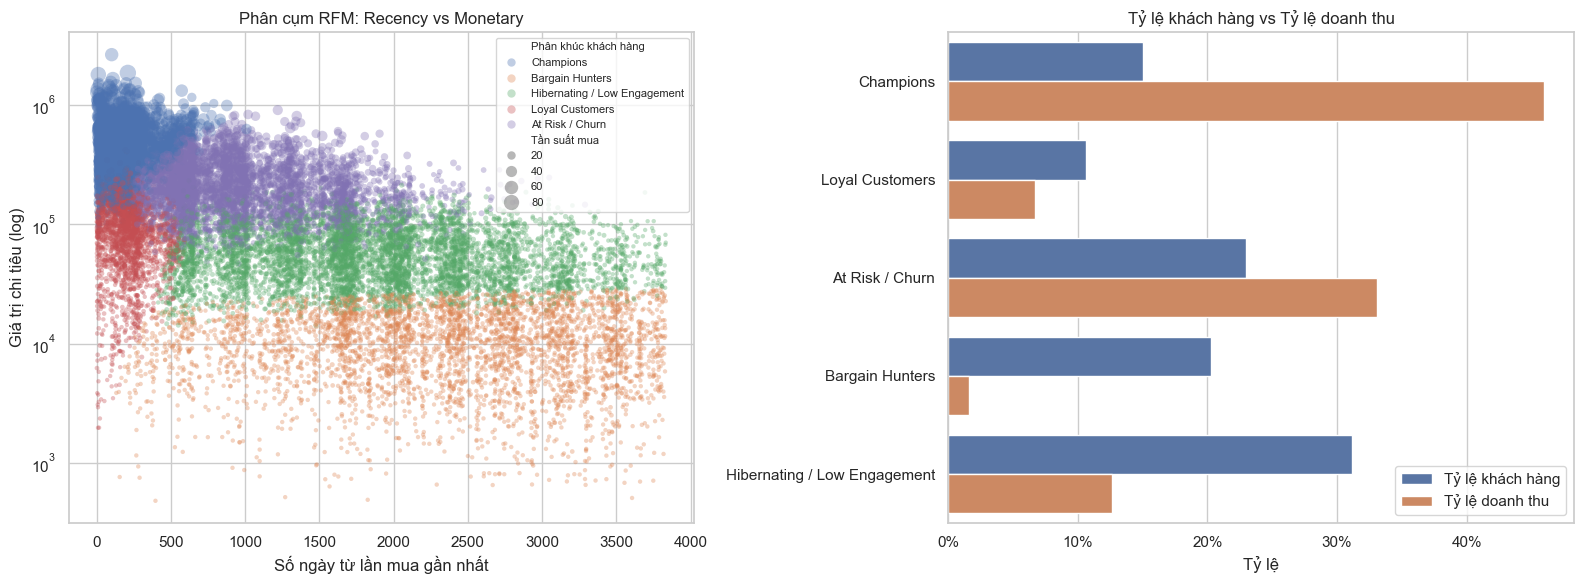

In [7]:
plot_sample = customer_segments_vi.sample(min(20_000, len(customer_segments_vi)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=plot_sample,
    x="Số ngày từ lần mua gần nhất",
    y="Giá trị chi tiêu",
    hue="Phân khúc khách hàng",
    size="Tần suất mua",
    sizes=(10, 140), alpha=0.35, linewidth=0, ax=axes[0]
)

axes[0].set_yscale("log")
axes[0].set_title("Phân cụm RFM: Recency vs Monetary")
axes[0].set_xlabel("Số ngày từ lần mua gần nhất")
axes[0].set_ylabel("Giá trị chi tiêu (log)")
axes[0].legend(loc="upper right", fontsize=8)

summary_long = rfm_segment_summary_vi.melt(
    id_vars="Phân khúc khách hàng",
    value_vars=["Tỷ lệ khách hàng", "Tỷ lệ doanh thu"],
    var_name="Chỉ số",
    value_name="Tỷ lệ"
)

sns.barplot(
    data=summary_long,
    x="Tỷ lệ",
    y="Phân khúc khách hàng",
    hue="Chỉ số",
    order=customer_segment_order,
    ax=axes[1]
)

axes[1].set_title("Tỷ lệ khách hàng vs Tỷ lệ doanh thu")
axes[1].set_xlabel("Tỷ lệ")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].legend(title="")

plt.tight_layout()
plt.show()


**Nhận xét:**

- **Quan sát:**
  - **Quy mô RFM:** Phân tích sử dụng **516,716 đơn delivered** và **85,115 khách hàng** có giao dịch thành công. Ngày mốc của dataset là **2023-01-01**.
  - **Cấu trúc cụm:** K-Means với `K=5` tách được các nhóm có ý nghĩa kinh doanh hơn so với ép `K=4`: **Champions** chiếm khoảng **15.0% khách** nhưng tạo gần **46.0% monetary**, còn **At Risk / Churn** chiếm **23.0% khách** và vẫn giữ khoảng **33.1% monetary lịch sử**.
  - **Bargain Hunters:** Nhóm này có `frequency_mean` khoảng **1.16 đơn/khách**, `monetary_mean` khoảng **11.3K**, nhưng có `promo_order_rate_mean` cao nhất, khoảng **44%**, đúng với hành vi săn khuyến mãi.
  - **Nhân khẩu học:** Nhóm tuổi **25-34** chiếm khoảng **29-30%**, Female khoảng **49%**, và `organic_search` khoảng **30%** ở hầu hết cụm. Demographic cơ bản chưa đủ để phân cụm tốt; RFM mới là lớp phân biệt hành vi chính.

- **Insights:**
  - **Champions là nhóm cần bảo vệ nhất:** Quy mô nhỏ hơn nhiều so với tổng tập khách nhưng đóng góp monetary vượt trội; mất nhóm này sẽ tác động doanh thu mạnh.
  - **At Risk / Churn là cơ hội win-back lớn:** Nhóm này từng mua nhiều (`frequency_mean` khoảng **8.6**, `monetary_mean` khoảng **212K**) nhưng đã lâu không quay lại (`recency_mean` gần **983 ngày**).
  - **Bargain Hunters không nên được nuôi bằng giảm giá rộng:** Promo rate cao nhưng monetary thấp, nên discount không kiểm soát dễ kéo biên lợi nhuận xuống.
  - **Hibernating / Low Engagement là vùng cần tối ưu chi phí:** Nhóm này đông nhất, hơn **31% khách**, nhưng monetary share thấp hơn nhiều so với customer share.

- **Gợi ý hành động:**
  - **Retention cho Champions:** Tạo ưu đãi độc quyền, early access, bundle sản phẩm biên lợi nhuận cao, và cảnh báo nếu recency vượt ngưỡng 90-180 ngày.
  - **Win-back cho At Risk / Churn:** Cá nhân hoá theo danh mục từng mua, đo uplift bằng holdout group thay vì gửi voucher đại trà.
  - **Quản trị khuyến mãi cho Bargain Hunters:** Chỉ cấp voucher có điều kiện như minimum basket value, giới hạn danh mục Cash Cows cần xả hàng, hoặc combo giúp tăng AOV.
  - **Không dùng demographic đơn lẻ để target:** Tuổi/giới/kênh khá giống nhau giữa các cụm, nên CRM nên ưu tiên RFM segment trước.

## 2.1. Nhóm sản phẩm theo biên lợi nhuận

#### 2.1.1. Những loại sản phẩm theo lợi nhuận?

**Ý tưởng**: 
Để xác định các loại sản phẩm mang lại lợi nhuận cao nhất, chúng ta cần xác định mức sinh lời của từng sản phẩm riêng lẻ. Lợi nhuận của một sản phẩm được tính bằng cách lấy giá bán (cột `price`) trừ đi giá vốn hàng bán (cột `cogs`). Từ đó, chúng ta sẽ nhóm các sản phẩm theo danh mục (`category`) để tính toán lợi nhuận trung bình (hoặc tổng lợi nhuận). Việc phân tích này giúp nhận diện nhóm hàng hóa nào đang mang lại biên lợi nhuận tốt nhất cho doanh nghiệp.

**Phương pháp sử dụng**:
1. Đọc dữ liệu từ `products.csv` và tạo thêm cột `profit` (Lợi nhuận) bằng phép tính: `price` - `cogs`.
2. Sử dụng `groupby` trên cột `category` để nhóm dữ liệu.
3. Dùng hàm `agg` để tính lợi nhuận trung bình (`mean`) của mỗi loại sản phẩm. 
4. Sắp xếp kết quả theo thứ tự giảm dần để tìm ra top các loại sản phẩm có lợi nhuận cao nhất.

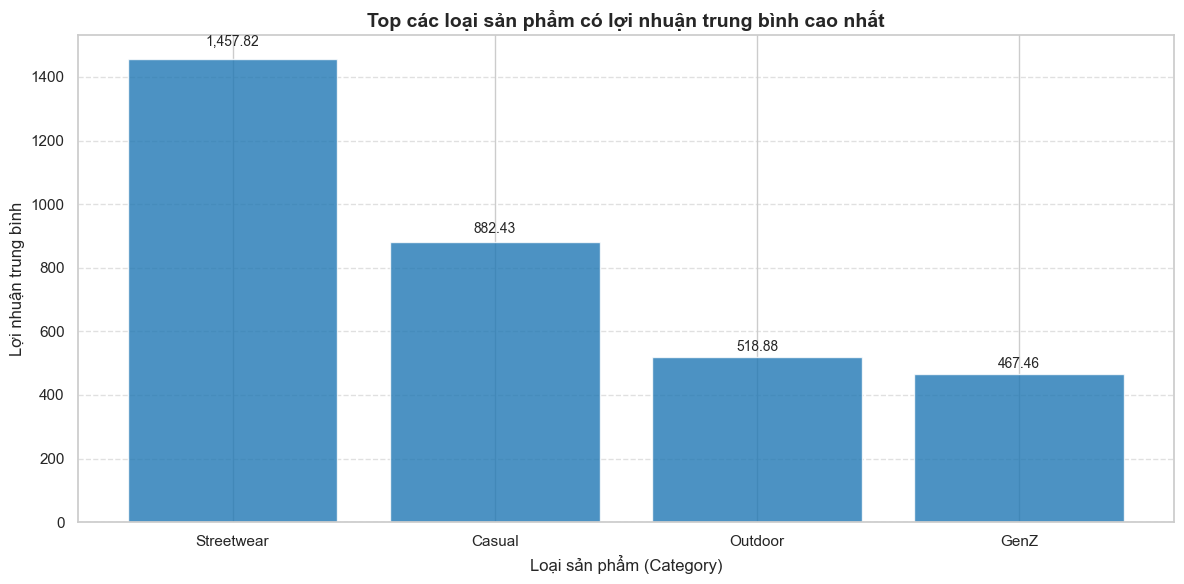

In [8]:
# Tính lợi nhuận cho từng sản phẩm (Lợi nhuận = Giá bán - Giá vốn)
products['profit'] = products['price'] - products['cogs']

# Tổng hợp dữ liệu: Tính lợi nhuận trung bình theo từng loại sản phẩm
profit_df = products.groupby('category').agg(
    avg_profit=('profit', 'mean')
).reset_index()

# Sắp xếp dữ liệu theo lợi nhuận giảm dần để tìm Top
profit_df = profit_df.sort_values('avg_profit', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ biểu đồ cột thể hiện lợi nhuận của các loại sản phẩm
color = 'tab:blue'
bars = ax.bar(profit_df['category'], profit_df['avg_profit'], color=color, alpha=0.8)

ax.set_xlabel('Loại sản phẩm (Category)', fontsize=12)
ax.set_ylabel('Lợi nhuận trung bình', fontsize=12)
ax.tick_params(axis='y')
ax.tick_params(axis='x') # Xoay nhãn trục x để không bị chồng chéo
ax.grid(axis='y', linestyle='--', alpha=0.6) # Chỉ kẻ lưới ngang cho biểu đồ cột

# Hiển thị giá trị cụ thể trên đỉnh của từng cột
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:,.2f}', ha='center', va='bottom', fontsize=10)

# Cập nhật lại tiêu đề
plt.title('Top các loại sản phẩm có lợi nhuận trung bình cao nhất', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

#### 2.1.2. Những cụm sản phẩm nào khi được mua kèm với nhau?

**Ý tưởng**:
Mục tiêu là khám phá các thói quen mua sắm tiềm ẩn của khách hàng để tìm ra những nhóm/cụm sản phẩm thường được mua cùng nhau trong một lần giao dịch. Bằng cách quan sát tập dữ liệu thực tế, các thuộc tính phân cụm như `category` (vd: Streetwear, Casual) và `segment` (vd: Premium, Activewear) sẽ được kết hợp lại để đại diện cho các mặt hàng. Việc nâng mức phân tích từ "sản phẩm cụ thể" lên "cụm thuộc tính" giúp giảm nhiễu dữ liệu và dễ dàng nhận diện các xu hướng mua chéo (cross-selling) lớn hơn.

**Phương pháp sử dụng**:
1. **Tiền xử lý & Tích hợp (Data Integration)**: Đọc trực tiếp dữ liệu từ `order_items.csv` và `products.csv`, sau đó nối (Inner Join) hai bảng này thông qua khóa `product_id`.
2. **Biến đổi dữ liệu (Data Transformation)**: Gom các thuộc tính `category` và `segment` của từng sản phẩm thành tập hợp các "cụm". Tiếp theo, nhóm (Group by) theo `order_id` để gộp tất cả các cụm này thành một "giỏ hàng" (basket) dạng danh sách (list) duy nhất, đồng thời loại bỏ các từ khóa trùng lặp trong cùng một đơn hàng.
3. **Mã hóa (One-hot Encoding)**: Chuyển đổi danh sách giỏ hàng thành ma trận nhị phân (boolean) thông qua `TransactionEncoder` để phù hợp với đầu vào của thuật toán.
4. **Khai phá luật kết hợp (Association Rule Mining)**: Áp dụng thuật toán **FP-Growth** (tối ưu tốc độ xử lý hơn Apriori trên tập dữ liệu lớn) để tìm các tập phổ biến (Frequent Itemsets). Từ đó, trích xuất các luật kết hợp và lọc lấy những luật có chỉ số **Lift > 1**, chứng tỏ sự xuất hiện của cụm mặt hàng này thực sự thúc đẩy sự xuất hiện của cụm mặt hàng kia một cách có ý nghĩa.

In [9]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules


merged_df = pd.merge(order_items, products, on='product_id', how='inner')

# 3. Tạo "Giỏ hàng" (Baskets) từ category và segment
merged_df['clusters'] = merged_df[['category', 'segment']].values.tolist()

baskets = merged_df.groupby('order_id')['clusters'].apply(
    lambda x: list(set([item for sublist in x for item in sublist if pd.notna(item)]))
).reset_index()

transactions = baskets['clusters'].tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket_sets = pd.DataFrame(te_ary, columns=te.columns_)

# 5. Khai phá luật (Mining) với FP-Growth
# Tìm các tập phổ biến với min_support = 0.01 (xuất hiện ở ít nhất 1% tổng số đơn hàng)
# Lưu ý: Bạn có thể điều chỉnh tham số min_support này tùy thuộc vào độ lớn dữ liệu
frequent_itemsets = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)

# Tạo các luật kết hợp và tự động lọc các luật
if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    
    # Lọc chắc chắn các luật có Lift > 1 (bỏ qua trường hợp lift = 1.0)
    rules_filtered = rules[rules['lift'] > 1.0]
    
    # Sắp xếp các luật theo giá trị Lift giảm dần để xem các quy luật mạnh nhất
    rules_filtered = rules_filtered.sort_values(by='lift', ascending=False).reset_index(drop=True)
    
    # Hiển thị 10 luật tiêu biểu nhất
    print(rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
else:
    print("Không tìm thấy tập phổ biến nào với min_support hiện tại. Vui lòng thử giảm min_support xuống thấp hơn.")

                antecedents               consequents  support  confidence  \
0       frozenset({Casual})  frozenset({All-weather})     0.03        0.96   
1  frozenset({All-weather})       frozenset({Casual})     0.03        1.00   
2         frozenset({GenZ})       frozenset({Trendy})     0.06        1.00   
3       frozenset({Trendy})         frozenset({GenZ})     0.06        1.00   
4      frozenset({Outdoor})      frozenset({Premium})     0.05        0.15   
5      frozenset({Premium})      frozenset({Outdoor})     0.05        1.00   
6      frozenset({Outdoor})   frozenset({Activewear})     0.26        0.85   
7   frozenset({Activewear})      frozenset({Outdoor})     0.26        0.99   
8   frozenset({Streetwear})     frozenset({Balanced})     0.16        0.26   
9     frozenset({Balanced})   frozenset({Streetwear})     0.16        1.00   

   lift  
0 27.41  
1 27.41  
2 17.46  
3 17.46  
4  3.23  
5  3.23  
6  3.21  
7  3.21  
8  1.66  
9  1.66  


In [10]:
df = pd.merge(order_items[['order_id', 'product_id']], 
              products[['product_id', 'product_name']], 
              on='product_id', how='left')

# 3. Tiền xử lý: Lọc các đơn hàng hợp lệ
# Luật kết hợp yêu cầu ít nhất 2 sản phẩm trở lên. Ta cần loại bỏ các đơn hàng chỉ có 1 sản phẩm 
# để tiết kiệm bộ nhớ và tăng tốc độ xử lý một cách đáng kể.
order_counts = df.groupby('order_id').size()
valid_orders = order_counts[order_counts > 1].index
df_filtered = df[df['order_id'].isin(valid_orders)]

print(f"Số lượng đơn hàng có > 1 sản phẩm: {len(valid_orders)}")

# 4. Nhóm các sản phẩm thành từng list giao dịch (Transactions)
transactions = df_filtered.groupby('order_id')['product_name'].apply(lambda x: list(set(x.dropna()))).tolist()

# 5. Mã hóa One-Hot (TransactionEncoder)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# 6. Tìm tập phổ biến bằng thuật toán FP-Growth (nhanh hơn Apriori với dữ liệu lớn)
# - min_support: Tỉ lệ xuất hiện tối thiểu (VD: 0.005 nghĩa là xuất hiện trong 0.5% tổng số đơn)
# - max_len: Thiết lập giới hạn tối đa là 5 theo yêu cầu của bạn
print("Đang chạy thuật toán FP-Growth...")
frequent_itemsets = fpgrowth(df_trans, min_support=0.005, use_colnames=True, max_len=5)

# 7. Trích xuất Luật kết hợp (Association Rules)
# Dùng metric là 'confidence' (độ tin cậy) với ngưỡng tối thiểu (VD: 0.1 tương đương 10%)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# Sắp xếp luật theo độ tin cậy (Confidence) và sức mạnh (Lift) giảm dần
rules = rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

# Format lại output để dễ đọc
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# 8. Hiển thị top 10 luật mạnh nhất
# Tính số lượng sản phẩm trong mỗi cột dựa vào số dấu phẩy
antecedent_len = rules['antecedents'].str.count(',') + 1
consequent_len = rules['consequents'].str.count(',') + 1

# Tổng số sản phẩm trong một luật kết hợp
total_items = antecedent_len + consequent_len

# Lọc ra Dataframe cho luật 2 sản phẩm và 3 sản phẩm
rules_2_items = rules[total_items == 2]
rules_3_items = rules[total_items == 3]
rules_4_items = rules[total_items == 4] # Nếu bạn muốn xem thêm 4 sản phẩm

# 8. Hiển thị kết quả
print("=== TOP 10 LUẬT KẾT HỢP CHO 2 SẢN PHẨM (1 mua kèm 1) ===")
if not rules_2_items.empty:
    print(rules_2_items[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string(index=False))
else:
    print("Không tìm thấy luật nào.")

print("\n=== TOP 10 LUẬT KẾT HỢP CHO 3 SẢN PHẨM (2 mua kèm 1, hoặc 1 mua kèm 2) ===")
if not rules_3_items.empty:
    print(rules_3_items[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string(index=False))
else:
    print("Không tìm thấy luật nào.")

Số lượng đơn hàng có > 1 sản phẩm: 66457
Đang chạy thuật toán FP-Growth...
=== TOP 10 LUẬT KẾT HỢP CHO 2 SẢN PHẨM (1 mua kèm 1) ===
     antecedents      consequents  support  confidence   lift
 MekongFit RP-24  MekongFit RP-23     0.01        0.99 157.05
  VietMode RP-09   VietMode RP-10     0.01        0.98 110.87
 MekongFit RP-44  MekongFit RP-43     0.01        0.98  82.91
 MekongFit RP-23  MekongFit RP-24     0.01        0.97 157.05
 MekongFit RP-31  MekongFit RP-32     0.04        0.97  25.51
 MekongFit RP-32  MekongFit RP-31     0.04        0.97  25.51
 MekongFit RP-43  MekongFit RP-44     0.01        0.97  82.91
VietMotion RP-03 VietMotion RP-04     0.01        0.97  83.84
VietMotion RP-04 VietMotion RP-03     0.01        0.97  83.84
 MekongFit RP-07  MekongFit RP-08     0.01        0.97  99.24

=== TOP 10 LUẬT KẾT HỢP CHO 3 SẢN PHẨM (2 mua kèm 1, hoặc 1 mua kèm 2) ===
Không tìm thấy luật nào.


**Nhận xét:**

- **Quan sát:**
  - **Tập dữ liệu và Thuật toán:** Quá trình khai phá luật kết hợp (Association Rule Mining) bằng FP-Growth được thực hiện trên một tệp dữ liệu khá lớn với 66,457 đơn hàng có chứa từ 2 sản phẩm trở lên.
  - **Chỉ số Confidence và Lift cao bất thường:** Trong Top 10 luật cho 2 sản phẩm, chỉ số `confidence` gần như đạt mức tuyệt đối (từ 0.97 đến 0.99), nghĩa là xác suất khách mua sản phẩm B khi đã mua sản phẩm A là 97-99%. Đồng thời, chỉ số `lift` đạt mức "khổng lồ" (từ 25.51 lên tới 157.05), cho thấy mối quan hệ phụ thuộc lẫn nhau cực kỳ mạnh mẽ, vượt xa sự ngẫu nhiên.
  - **Tính chất đối xứng và Tương đồng mã sản phẩm:** Các luật xuất hiện theo từng cặp đối xứng hoàn hảo (Ví dụ: `MekongFit RP-24` -> `MekongFit RP-23` và ngược lại `MekongFit RP-23` -> `MekongFit RP-24`). Ngoài ra, các cặp này thường có chung thương hiệu (MekongFit, VietMode, VietMotion) và mã số sê-ri liền kề nhau (23-24, 09-10, 31-32).
  - **Độ phủ (Support) thấp và Vắng bóng luật 3 sản phẩm:** Chỉ số `support` của các cặp này rất thấp (chỉ khoảng 0.01 - 0.04 tức 1-4% trên tổng số 66,457 đơn hàng). Hơn nữa, thuật toán không tìm ra bất kỳ luật kết hợp nào cho 3 sản phẩm thỏa mãn điều kiện.

- **Insights:**
  - **Hiện tượng "Sản phẩm đi theo bộ" (Hard-bundled / Sets):** Mức Confidence 99% và Lift > 100 cùng với đuôi mã sản phẩm liền kề là dấu hiệu rõ ràng nhất của các sản phẩm mang tính chất "đi theo cặp/bộ". Đây rất có thể là các bộ quần áo (áo - quần), đồ bơi, linh kiện ghép nối, hoặc sản phẩm chia thành 2 phần (trái - phải) nhưng lại đang được lưu trữ dưới dạng 2 mã SKU độc lập trong hệ thống thay vì 1 SKU combo.
  - **Sự phân mảnh của danh mục (Long-tail catalog):** Chỉ số Support thấp (0.01) cho thấy danh mục sản phẩm của doanh nghiệp rất đa dạng và phân mảnh. Dù một cặp sản phẩm có tỷ lệ đi kèm với nhau là 100%, nhưng chúng chỉ đóng góp một phần nhỏ giọt vào tổng khối lượng giao dịch.
  - **Hành vi mua sắm "Đích danh và Đơn giản":** Khách hàng vào nền tảng để mua chính xác một bộ/cặp sản phẩm họ cần (luật 2 món) rồi rời đi, chứ ít khi có hành vi bỏ thêm các sản phẩm phụ trợ khác vào giỏ hàng (không có luật 3 món).

- **Gợi ý hành động:**
  - **Quy hoạch lại Dữ liệu (Master Data Management):** Phối hợp với bộ phận kho/sản phẩm để kiểm tra lại các mã liền kề này (ví dụ RP-23 và RP-24). Nếu thực chất chúng là 1 bộ không thể tách rời, cần gộp chúng thành 1 mã Combo SKU duy nhất để tối ưu hóa việc quản lý tồn kho (tránh tình trạng kho còn mã này nhưng hết mã kia dẫn đến không thể bán được hàng).
  - **Tối ưu hóa UI/UX và Cross-selling (Bán chéo):** Tận dụng các luật kết hợp đối xứng này để tự động hóa giao diện mua hàng. Khi khách hàng bấm thêm `MekongFit RP-24` vào giỏ, hệ thống phải ngay lập tức hiển thị pop-up "Thường được mua kèm cùng..." hoặc tạo sẵn nút "Mua trọn bộ" với `MekongFit RP-23` để tiết kiệm thao tác click cho người dùng.
  - **Thiết kế chiến lược Bundle Pricing (Định giá theo gói):** Vì tệp khách hàng chưa có thói quen mua giỏ hàng lớn (không có luật 3 sản phẩm), hãy dùng chính các cặp đôi hoàn hảo này làm mồi nhử. Tạo ra các "Super Combo" kết hợp giữa cặp sản phẩm này (A+B) với một sản phẩm thứ 3 (phụ kiện, tất, mũ, v.v.) đi kèm chiết khấu nhẹ để kích thích hành vi mua nhiều món hơn, từ đó tăng giá trị trung bình trên mỗi đơn hàng (AOV).

## 2.2. Phân nhóm Sản phẩm theo Profit-Volume Matrix 

Bước này phân loại sản phẩm bằng 2 trục:

- **Gross Margin:** `(price - cogs) / price`
- **Sales Volume:** tổng `quantity` bán ra trong `order_items.csv`

Ngưỡng cao/thấp được đặt theo median của từng trục để tạo 4 góc phần tư: **Stars**, **Cash Cows**, **Question Marks**, **Dogs**.

| Phân khúc              | Đặc điểm (Biên LN & Sản lượng)                         | Nhận xét & Chiến lược                                                                 |
|------------------------|--------------------------------------------------------|----------------------------------------------------------------------------------------|
| Stars (Ngôi sao)       | Cao & Cao: Nằm góc trên bên phải (màu cam).           | Sản phẩm chủ lực, mang lại cả doanh thu và lợi nhuận lớn. Cần đầu tư tối đa để duy trì vị thế dẫn đầu. |
| Cash Cows (Bò sữa)     | Thấp & Cao: Nằm góc dưới bên phải (màu xanh dương).   | Sản lượng cực lớn nhưng biên lợi nhuận mỏng. Đây là nguồn tiền mặt ổn định; cần tối ưu hóa quy trình để giảm chi phí hơn nữa. |
| Question Marks (Dấu hỏi)| Cao & Thấp: Nằm góc trên bên trái (màu đỏ).          | Sản phẩm có biên lợi nhuận tốt nhưng chưa bán chạy. Cần đẩy mạnh Marketing hoặc kiểm tra lại tệp khách hàng để tăng sản lượng. |
| Dogs (Chó hoang)       | Thấp & Thấp: Nằm góc dưới bên trái (màu xanh lá).     | Hiệu quả kém về cả lợi nhuận lẫn doanh số. Nên cân nhắc loại bỏ hoặc cải tổ để tránh lãng phí nguồn lực kho bãi. |



In [11]:
product_segments = products.copy()
product_segments["gross_margin"] = ((product_segments["price"] - product_segments["cogs"]) / product_segments["price"]).replace([np.inf, -np.inf], np.nan)

sales_volume = order_items.groupby("product_id", as_index=False)["quantity"].sum().rename(columns={"quantity": "sales_volume"})
product_segments = product_segments.merge(sales_volume, on="product_id", how="left")
product_segments["sales_volume"] = product_segments["sales_volume"].fillna(0)

margin_cutoff = product_segments["gross_margin"].median()
volume_cutoff = product_segments["sales_volume"].median()

product_segments["product_segment_pv"] = np.select(
    [
        (product_segments["gross_margin"] >= margin_cutoff) & (product_segments["sales_volume"] >= volume_cutoff),
        (product_segments["gross_margin"] < margin_cutoff) & (product_segments["sales_volume"] >= volume_cutoff),
        (product_segments["gross_margin"] >= margin_cutoff) & (product_segments["sales_volume"] < volume_cutoff),
        (product_segments["gross_margin"] < margin_cutoff) & (product_segments["sales_volume"] < volume_cutoff),
    ],
    ["Stars", "Cash Cows", "Question Marks", "Dogs"],
    default="Unclassified",
)

product_segment_summary = (
    product_segments.groupby("product_segment_pv")
    .agg(products=("product_id", "nunique"), avg_margin=("gross_margin", "mean"), total_volume=("sales_volume", "sum"), avg_volume=("sales_volume", "mean"), avg_price=("price", "mean"))
    .reset_index()
)
product_segment_summary["product_share"] = product_segment_summary["products"] / product_segment_summary["products"].sum()
product_segment_summary["volume_share"] = product_segment_summary["total_volume"] / product_segment_summary["total_volume"].sum()
product_segment_summary = product_segment_summary.sort_values("total_volume", ascending=False)

print(f"Gross margin median cutoff: {margin_cutoff:.2%}")
print(f"Sales volume median cutoff: {volume_cutoff:,.0f} units")
display(product_segment_summary.style.format({
    "products": "{:,.0f}", "avg_margin": "{:.2%}", "total_volume": "{:,.0f}",
    "avg_volume": "{:,.1f}", "avg_price": "{:,.0f}", "product_share": "{:.2%}", "volume_share": "{:.2%}",
}))

category_pv_summary = (
    product_segments.groupby(["category", "product_segment_pv"])
    .agg(products=("product_id", "nunique"), volume=("sales_volume", "sum"), avg_margin=("gross_margin", "mean"))
    .reset_index()
    .sort_values(["category", "volume"], ascending=[True, False])
)
display(category_pv_summary.groupby("category").head(3).style.format({"products": "{:,.0f}", "volume": "{:,.0f}", "avg_margin": "{:.2%}"}))

Gross margin median cutoff: 30.58%
Sales volume median cutoff: 86 units


,product_segment_pv,products,avg_margin,total_volume,avg_volume,avg_price,product_share,volume_share
0,Cash Cows,822,12.97%,"2,225,526","2,707.5","6,667",34.08%,69.26%
3,Stars,387,40.34%,"976,089","2,522.2","6,610",16.04%,30.38%
1,Dogs,384,13.14%,"7,985",20.8,"7,030",15.92%,0.25%
2,Question Marks,819,40.05%,"3,543",4.3,"1,403",33.96%,0.11%


,category,product_segment_pv,products,volume,avg_margin
0,Casual,Cash Cows,48,"83,247",13.33%
3,Casual,Stars,26,"22,788",38.89%
1,Casual,Dogs,38,852,13.56%
4,GenZ,Cash Cows,67,"94,875",11.26%
7,GenZ,Stars,27,"71,408",41.33%
5,GenZ,Dogs,17,289,12.54%
8,Outdoor,Cash Cows,248,"788,792",13.28%
11,Outdoor,Stars,114,"377,655",40.91%
9,Outdoor,Dogs,119,"2,573",13.07%
12,Streetwear,Cash Cows,459,"1,258,612",13.02%


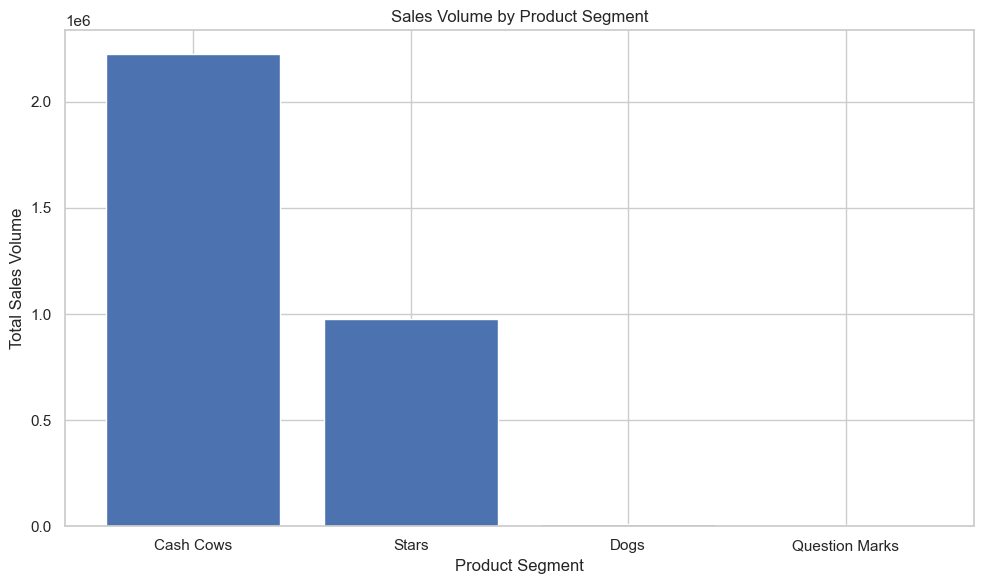

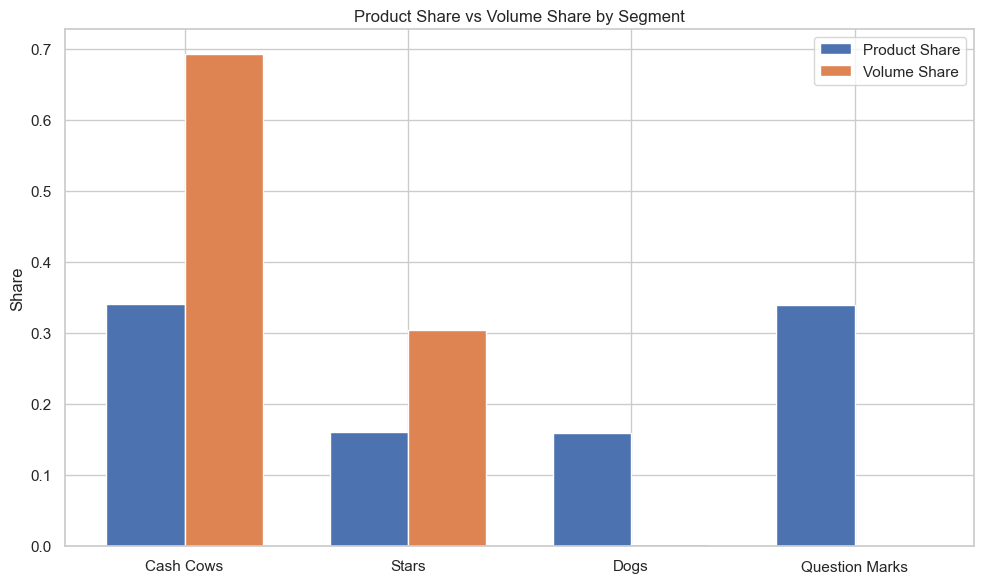

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(product_segment_summary["product_segment_pv"], product_segment_summary["total_volume"])
plt.xlabel("Product Segment")
plt.ylabel("Total Sales Volume")
plt.title("Sales Volume by Product Segment")
plt.xticks()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
x = np.arange(len(product_segment_summary))
width = 0.35

plt.bar(x - width/2, product_segment_summary["product_share"], width, label="Product Share")
plt.bar(x + width/2, product_segment_summary["volume_share"], width, label="Volume Share")

plt.xticks(x, product_segment_summary["product_segment_pv"])
plt.ylabel("Share")
plt.title("Product Share vs Volume Share by Segment")
plt.legend()
plt.tight_layout()
plt.show()

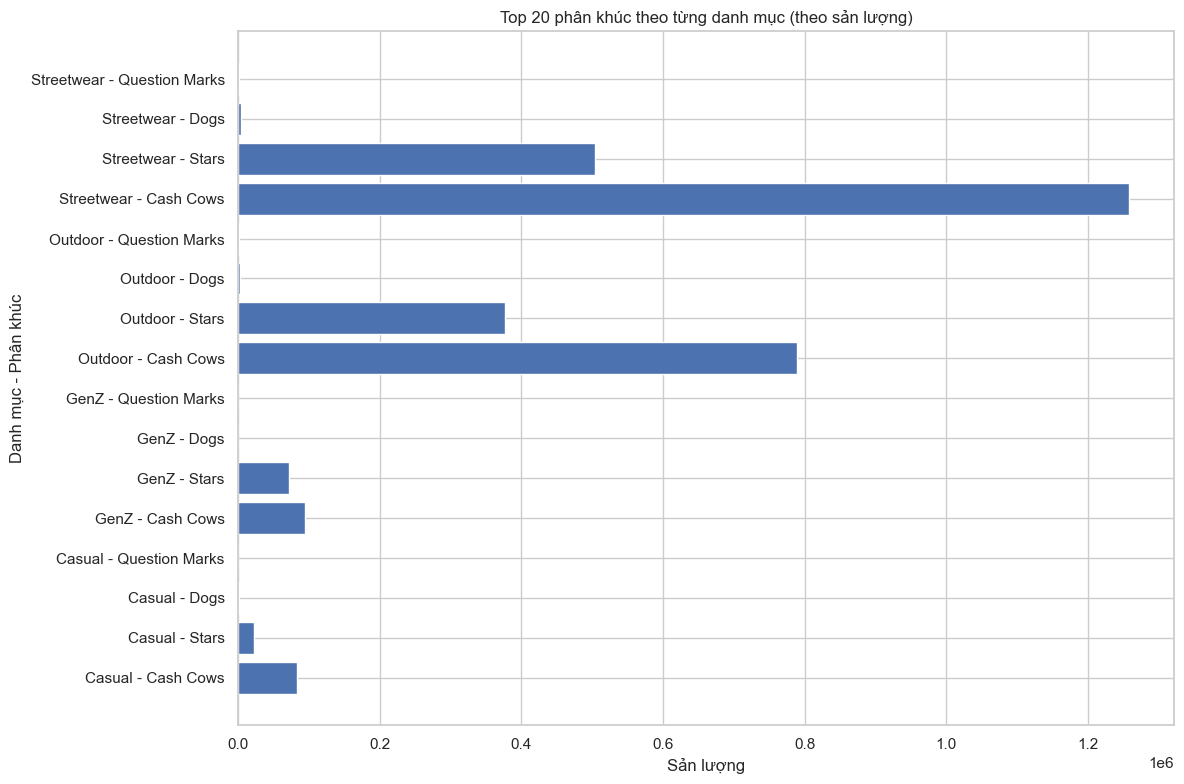

In [13]:
top_category = category_pv_summary.groupby("category").head(5)

plt.figure(figsize=(12, 8))
labels = top_category["category"] + " - " + top_category["product_segment_pv"]

plt.barh(labels, top_category["volume"])

plt.xlabel("Sản lượng")
plt.ylabel("Danh mục - Phân khúc")
plt.title("Top 20 phân khúc theo từng danh mục (theo sản lượng)")

plt.tight_layout()
plt.show()


**Nhận xét:**

- **Quan sát:**
  - **Phân bổ Danh mục sản phẩm (Product & Volume Share):** Dữ liệu cho thấy sự phân mảnh và tập trung rất rõ rệt. Về mặt số lượng mã SKU, `Cash Cows` (34.08%) và `Question Marks` (33.96%) chiếm tỷ trọng lớn nhất. Tuy nhiên, về mặt sản lượng thực tế (Volume Share), hai nhóm `Cash Cows` (69.26%) và `Stars` (30.38%) gần như thâu tóm toàn bộ thị phần (tổng cộng hơn 99.6%), để lại lượng bán không đáng kể cho `Dogs` và `Question Marks`.
  - **Biên lợi nhuận (Margin) và Giá cả (Price):** Có sự phân hóa chéo giữa các nhóm. Nhóm `Stars` và `Question Marks` có biên lợi nhuận trung bình rất cao (đều xấp xỉ 40%), trong khi `Cash Cows` và `Dogs` chỉ dừng ở mức 12.97% - 13.14%. Đáng chú ý, nhóm `Question Marks` có mức giá trung bình cực thấp (1,403) so với mặt bằng chung (dao động từ 6,600 đến hơn 7,000).
  - **Đóng góp theo Ngành hàng (Category):** Bảng chi tiết cho thấy `Streetwear` và `Outdoor` là hai trụ cột doanh số chính, sở hữu lượng sản phẩm và sản lượng áp đảo ở cả phân khúc `Cash Cows` và `Stars`. Quy luật về biên lợi nhuận (Stars cao, Cash Cows thấp) được duy trì đồng nhất, không bị biến động qua các category (Ví dụ: Stars của Streetwear đạt 40.10%, GenZ đạt 41.33%).

- **Insights:**
  - **Nghịch lý danh mục (Portfolio Imbalance):** Doanh nghiệp đang duy trì một lượng khổng lồ các mã sản phẩm (819 SKUs) thuộc nhóm `Question Marks` nhưng chúng không tạo ra sản lượng (chỉ 0.11%), dù có biên lợi nhuận rất hấp dẫn. Đây khả năng cao là các sản phẩm phễu giá rẻ đang được thử nghiệm thị trường nhưng chưa tìm được Product-Market Fit, hoặc bị nghẽn ở khâu tiếp thị.
  - **Động lực sinh lời (Profit Engine):** Nhóm `Stars` đang làm xuất sắc vai trò của mình. Dù số lượng SKU chỉ bằng một nửa Cash Cows (387 so với 822), chúng lại chiếm tới hơn 30% sản lượng và mang lại biên lợi nhuận cực cao (hơn 40%). Đây chính là nhóm gánh vác phần lớn lợi nhuận ròng cho hệ thống.
  - **Vai trò và Rủi ro của Cash Cows:** `Cash Cows` làm tốt nhiệm vụ duy trì dòng tiền và bao phủ thị trường (volume khổng lồ). Tuy nhiên, việc hoạt động với mức biên lợi nhuận khá mỏng (~13%) cho thấy các sản phẩm này đang nằm trong vùng cạnh tranh giá khốc liệt. Trong khi đó, nhóm `Dogs` có giá bán cao nhất (7,030) nhưng biên lợi nhuận thấp và không bán được, chứng tỏ chúng đã hết vòng đời hoặc bị định giá sai lệch so với giá trị thực.

- **Gợi ý hành động:**
  - **Cắt tỉa danh mục (SKU Rationalization):** Khẩn trương rà soát 384 mã sản phẩm nhóm `Dogs`. Cần có chiến dịch xả kho (Clearance Sale) dứt điểm để thu hồi vốn và giải phóng không gian lưu trữ. Với nhóm `Question Marks`, cần chọn lọc ra một vài mã tiềm năng nhất để dồn ngân sách Marketing đẩy lên thành `Stars`, đồng thời loại bỏ phần lớn các mã không có tín hiệu mua hàng để tối ưu chi phí quản lý danh mục.
  - **Chiến lược dồn lực cho Stars:** Tận dụng đà tăng trưởng của ngành hàng `Streetwear` và `Outdoor`, hãy tăng cường ngân sách quảng cáo và vị trí hiển thị (merchandising) ưu tiên cho nhóm `Stars` tại các category này. Có thể thiết kế các gói Bundle (bán chéo) kết hợp giữa 1 sản phẩm `Cash Cows` (làm mồi nhử traffic) và 1 sản phẩm `Stars` để vừa đẩy mạnh sản lượng vừa trung hòa, nâng cao biên lợi nhuận của toàn giỏ hàng.
  - **Bảo vệ biên lợi nhuận Cash Cows:** Tránh việc tham gia sâu hơn vào các cuộc chiến giá cả (Price Wars) ở nhóm `Cash Cows` vì biên lợi nhuận 13% là không có nhiều độ hở để chịu thêm rủi ro. Nên làm việc lại với chuỗi cung ứng (Supply Chain) để tìm cách tối ưu Giá vốn hàng bán (COGS) dựa trên lợi thế quy mô (Economics of Scale) khổng lồ mà nhóm này đang mang lại.

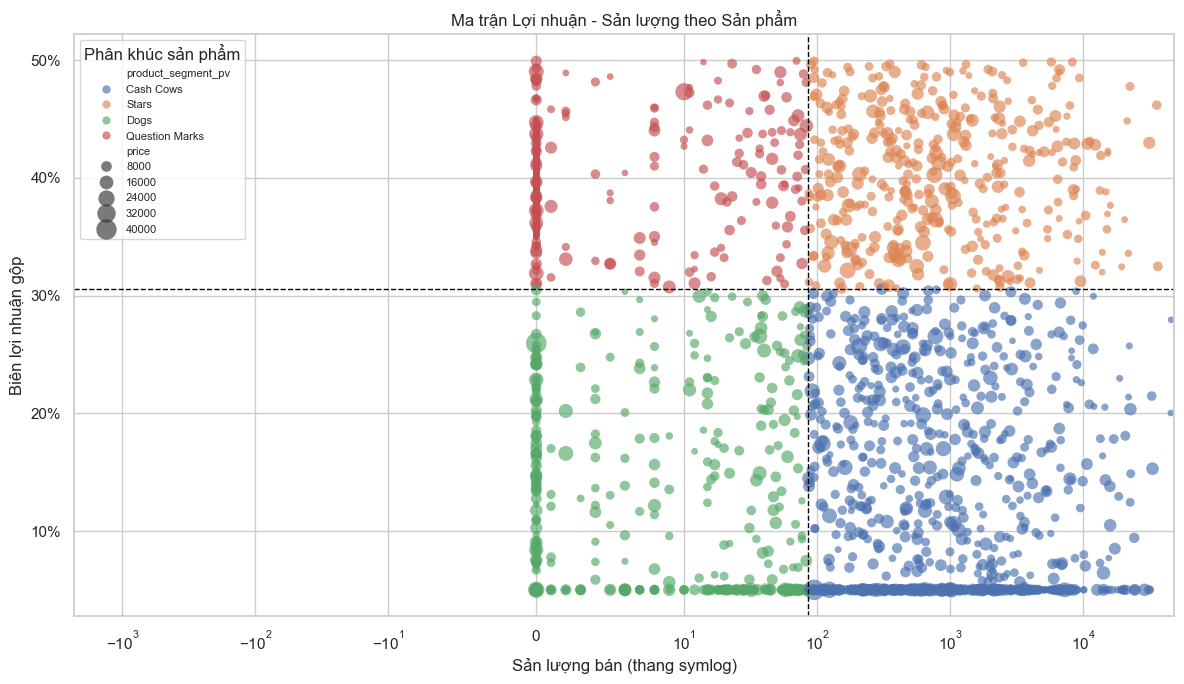

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=product_segments,
    x="sales_volume",
    y="gross_margin",
    hue="product_segment_pv",
    size="price",
    sizes=(20, 220),
    alpha=0.65,
    linewidth=0,
    ax=ax
)

ax.axhline(margin_cutoff, color="black", linestyle="--", linewidth=1)
ax.axvline(volume_cutoff, color="black", linestyle="--", linewidth=1)

ax.set_xscale("symlog", linthresh=10)
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")

ax.set_title("Ma trận Lợi nhuận - Sản lượng theo Sản phẩm")
ax.set_xlabel("Sản lượng bán (thang symlog)")
ax.set_ylabel("Biên lợi nhuận gộp")

ax.legend(title="Phân khúc sản phẩm", loc="best", fontsize=8)

plt.tight_layout()
plt.show()


**Quan sát**

Sự tập trung của Cash Cows: Nhóm màu xanh dương (Cash Cows) có mật độ rất dày đặc ở vùng sản lượng từ $10^2$ đến $10^4$. Điều này cho thấy doanh nghiệp đang vận hành dựa trên chiến lược "số lượng lớn", chấp nhận biên lợi nhuận dưới 30% để chiếm lĩnh thị trường.

Khoảng trống sản lượng thấp: Có một dải sản phẩm (màu đỏ và xanh lá) tập trung sát vạch mức 0 trên trục sản lượng. Đây có thể là các sản phẩm mới ra mắt hoặc các mã hàng tồn kho lâu ngày không phát sinh đơn hàng đáng kể.

Kích thước bóng (Price): 

- Các bóng có kích thước lớn (giá cao) xuất hiện rải rác ở nhóm Question Marks và Stars.

- Nhóm Cash Cows và Dogs đa số là các bóng nhỏ, cho thấy các sản phẩm giá rẻ thường có xu hướng rơi vào nhóm có biên lợi nhuận thấp hơn.

Điểm bùng nổ: Ranh giới phân tách sản lượng (đường kẻ dọc) nằm ở mức khoảng 80 - 100 đơn vị. Sản phẩm nào vượt qua ngưỡng này sẽ chuyển dịch sang vùng mang lại dòng tiền chính (Stars/Cash Cows).

**Nhận xét tổng thể:**

- **Quan sát:**
  - **Ngưỡng phân loại:** Median gross margin của danh mục là khoảng **30.6%** và median sales volume là **86 units**.
  - **Cash Cows:** Có **822 sản phẩm** nhưng chiếm khoảng **69.3% tổng units bán ra**, gross margin trung bình chỉ khoảng **13%**.
  - **Stars:** Có **387 sản phẩm**, chiếm khoảng **30.4% units**, gross margin trung bình khoảng **40%**.
  - **Question Marks và Dogs:** Số SKU khá lớn (**819** và **384 sản phẩm**) nhưng tổng volume rất thấp, lần lượt khoảng **3.5K** và **8.0K units**.
  - **Theo category:** `Streetwear` và `Outdoor` là hai nguồn volume lớn nhất; `Streetwear - Cash Cows` đạt hơn **1.25M units** và `Streetwear - Stars` hơn **504K units**.

- **Insights:**
  - **Danh mục đang phụ thuộc vào Cash Cows:** Volume lớn nằm ở sản phẩm biên thấp, nên lợi nhuận dễ bị bào mòn nếu logistics, discount hoặc return tăng.
  - **Stars là đòn bẩy lợi nhuận:** Số SKU ít hơn Cash Cows nhưng margin cao và tốc độ bán tốt, cần được ưu tiên tồn kho/hiển thị/cross-sell.
  - **Question Marks chưa chứng minh được demand:** Biên lợi nhuận tốt nhưng volume quá thấp, có thể do thiếu traffic, định vị sai kênh, giá cao, hoặc sản phẩm mới chưa được kích hoạt.
  - **Dogs cần kiểm soát tồn kho:** Volume thấp và margin thấp đồng thời làm tăng rủi ro tồn kho chết.

- **Gợi ý hành động:**
  - **Bảo vệ availability cho Stars:** Đặt reorder rule riêng, ưu tiên fill-rate và tránh stockout mùa cao điểm.
  - **Tối ưu margin của Cash Cows:** Kiểm tra COGS, shipping, discount và bundle để tăng biên lợi nhuận mà không làm giảm volume.
  - **Thử nghiệm kích cầu Question Marks:** A/B test placement, influencer/social creatives, hoặc bundle với Champions.
  - **Rationalize Dogs:** Giảm mua mới, clear inventory bằng combo có điều kiện, hoặc loại khỏi danh mục nếu không có vai trò chiến lược.

## 3. Cụ thể hóa Sản phẩm cho từng Nhóm Khách hàng (Cross-Mapping)

Bước này nối kết quả từ bước 1 và bước 2 qua `orders`, `order_items`, `products`, `customers` để trả lời:

- Nhóm khách hàng nào có xu hướng mua nhóm sản phẩm nào?
- Nhóm nào nhạy với giá/khuyến mãi nhất?
- Kênh acquisition hoặc order source có làm thay đổi category preference không?

Phần association rules dùng triển khai **Apriori-style 2-itemset** ở cấp order, đủ cho bài toán `customer_segment → product_group`

### 3.1. Join customer segment x product segment

**Ý tưởng**:

Thực hiện phân tích đối chiếu chéo (Cross-segment Analysis) giữa **Phân khúc khách hàng** (Customer Segment - ví dụ: VIP, Churn, Potential qua mô hình RFM) và **Phân khúc sản phẩm** (Product Segment - ví dụ: phân khúc Lợi nhuận/Số lượng bán). 

Mục tiêu cốt lõi là để trả lời câu hỏi: *"Nhóm khách hàng X đang tiêu thụ chủ yếu nhóm sản phẩm Y nào?"*. Bằng cách tính toán tỷ trọng số lượng sản phẩm bán ra theo từng tập khách hàng, phân tích này giúp nhận diện hành vi mua sắm đặc trưng, từ đó hỗ trợ doanh nghiệp đưa ra chiến lược cross-sell, up-sell, cá nhân hóa khuyến mãi và quản lý danh mục sản phẩm hiệu quả hơn.

**Phương pháp sử dụng**:
1. **Tổng hợp dữ liệu (Data Merging/Joins):** 
   - Ghép nối bảng `orders` với phân khúc khách hàng từ `rfm` để tạo `orders_with_segments`.
   - Kết hợp toàn diện (merge) chi tiết đơn hàng (`order_items`) với thông tin đơn hàng, khách hàng (`customers`), sản phẩm (`products`), và phân khúc sản phẩm (`product_segments`) để tạo ra một bảng dữ liệu góc nhìn 360 độ (`line_items_enriched`).

2. **Xử lý số liệu và Tính toán chỉ số (Feature Engineering):** 
   - Điền các giá trị khuyến mãi bị thiếu bằng 0 (`fillna`).
   - Tính toán doanh thu trước giảm giá (`line_gross`), doanh thu thuần (`line_net`), và tỷ lệ giảm giá trên từng dòng sản phẩm (`discount_rate_line`).
   - Tạo biến cờ `has_promo` (True/False) để xác định xem dòng sản phẩm đó có áp dụng mã khuyến mãi hay không.

3. **Gom nhóm và Tổng hợp thống kê (Grouping & Aggregation):**
   - Sử dụng `.groupby()` theo hai chiều `customer_segment` và `product_segment_pv`.
   - Dùng `.agg()` để tính các chỉ số quan trọng cho mỗi tổ hợp phân khúc: số đơn hàng độc lập (`orders`), tổng sản phẩm (`units`), tổng doanh thu (`revenue`), tổng giảm giá (`discount`), và tỷ lệ áp dụng khuyến mãi (`promo_line_rate`).

4. **Tính tỷ trọng nội bộ (Proportion Calculation):**
   - Tính `segment_units_share`: Tỷ lệ phần trăm số lượng sản phẩm của một phân khúc sản phẩm cụ thể so với tổng toàn bộ sản phẩm mà một phân khúc khách hàng đã mua.

5. **Biến đổi cấu trúc và Trực quan hóa (Pivoting & Data Visualization):**
   - Chuyển đổi dữ liệu thành dạng ma trận bằng `.pivot_table()`, với hàng là Phân khúc khách hàng và cột là Phân khúc sản phẩm.
   - Vẽ biểu đồ nhiệt (Heatmap) bằng `seaborn.heatmap()`. Các ô có màu càng đậm (thể hiện phần trăm càng cao) sẽ làm nổi bật những "điểm chạm" (sweet spots) nơi lượng tiêu thụ tập trung mạnh nhất.

In [15]:
orders_with_segments = (
    valid_orders[["order_id", "customer_id", "order_date", "order_source", "device_type", "payment_method"]]
    .merge(rfm[["customer_id", "customer_segment"]], on="customer_id", how="left")
)

line_items_enriched = (
    order_items
    .merge(orders_with_segments, on="order_id", how="inner")
    .merge(products[["product_id", "product_name", "category", "segment", "price", "cogs"]], on="product_id", how="left")
    .merge(product_segments[["product_id", "gross_margin", "sales_volume", "product_segment_pv"]], on="product_id", how="left")
    .merge(customers[["customer_id", "age_group", "gender", "acquisition_channel"]], on="customer_id", how="left")
)

line_items_enriched["discount_amount"] = line_items_enriched["discount_amount"].fillna(0)
line_items_enriched["line_gross"] = line_items_enriched["quantity"] * line_items_enriched["unit_price"]
line_items_enriched["line_net"] = line_items_enriched["line_gross"] - line_items_enriched["discount_amount"]
line_items_enriched["discount_rate_line"] = (
    line_items_enriched["discount_amount"] / line_items_enriched["line_gross"].replace(0, np.nan)
).fillna(0)
line_items_enriched["has_promo"] = line_items_enriched[promo_cols].notna().any(axis=1) if promo_cols else False

cross_segment_summary = (
    line_items_enriched.groupby(["customer_segment", "product_segment_pv"])
    .agg(orders=("order_id", "nunique"), units=("quantity", "sum"), revenue=("line_gross", "sum"), discount=("discount_amount", "sum"), promo_line_rate=("has_promo", "mean"))
    .reset_index()
)
cross_segment_summary["segment_units_share"] = cross_segment_summary["units"] / cross_segment_summary.groupby("customer_segment")["units"].transform("sum")

pivot_units_share = cross_segment_summary.pivot_table(
    index="customer_segment", columns="product_segment_pv", values="segment_units_share", fill_value=0
).loc[customer_segment_order]

display(cross_segment_summary.sort_values(["customer_segment", "units"], ascending=[True, False]).style.format({
    "orders": "{:,.0f}", "units": "{:,.0f}", "revenue": "{:,.0f}", "discount": "{:,.0f}",
    "promo_line_rate": "{:.2%}", "segment_units_share": "{:.2%}",
}))


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

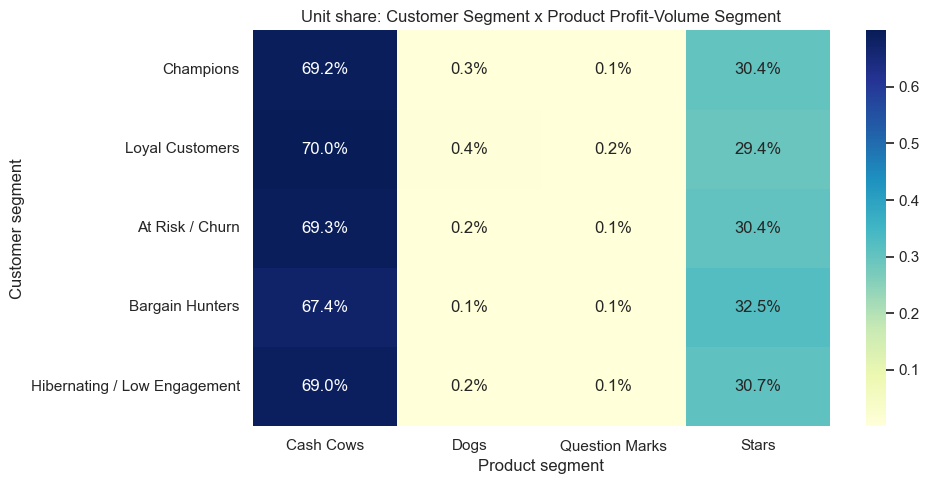

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_units_share, annot=True, fmt=".1%", cmap="YlGnBu", ax=ax)
ax.set_title("Unit share: Customer Segment x Product Profit-Volume Segment")
ax.set_xlabel("Product segment")
ax.set_ylabel("Customer segment")
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - **Cơ cấu sản phẩm theo từng tệp khách hàng (Heatmap & Table):** Phân phối tỷ trọng sản phẩm bán ra (Unit share) có sự đồng nhất đến mức đáng kinh ngạc giữa tất cả các nhóm khách hàng (từ Champions, Loyal Customers đến At Risk, Hibernating). Nhóm sản phẩm "Cash Cows" luôn chiếm thế áp đảo tuyệt đối (khoảng 67.4% - 70.0%), theo sau là "Stars" (khoảng 29.4% - 32.5%).
  - **Table:** Các sản phẩm thuộc nhóm "Dogs" và "Question Marks" gần như không tồn tại trong giỏ hàng của bất kỳ tệp khách hàng nào, tổng cộng chưa tới 0.5% unit share ở mọi phân khúc.
  - **Tỷ lệ áp dụng khuyến mãi (promo_line_rate):** Dù mua cùng một cơ cấu sản phẩm, tệp "Bargain Hunters" có tỷ lệ áp dụng khuyến mãi cao nhất (trên 44% cho cả Cash Cows và Stars), trong khi các tệp như "Champions" hay "Hibernating" duy trì ở mức 37% - 38%.

- **Insights:**
  - <span style="color:red">**Sự phụ thuộc vào Core Products (Product-centric):** Mô hình kinh doanh này không có sự phân hóa nhu cầu theo tệp khách hàng. Khách hàng VIP hay khách hàng săn sale đều chỉ tập trung mua đúng 2 dòng sản phẩm cốt lõi (Cash Cows và Stars). Điều này cho thấy danh mục sản phẩm có thể đang bị thu hẹp hoặc các sản phẩm khác không có điểm nhấn (USP) đủ mạnh để bán chéo (Cross-sell).</span>
  - **Bản chất của tệp săn sale (Bargain Hunters):** Nhóm này không mua các sản phẩm giá rẻ hay sản phẩm xả kho (Dogs/Question Marks). Họ kiên nhẫn chờ đợi các chương trình giảm giá để mua các sản phẩm "Best-seller" (Cash Cows/Stars). Điều này có thể gây tổn hại lớn đến biên lợi nhuận nếu doanh nghiệp lạm dụng giảm giá trên các sản phẩm vốn dĩ đã tự bán được.
  - <span style="color:red">**Lãng phí nguồn lực danh mục:** Việc duy trì nhóm "Dogs" và "Question Marks" không mang lại giá trị kinh tế đáng kể nhưng lại tốn kém chi phí lưu kho, quản lý và vận hành.</span>

- **Gợi ý hành động:**
  - Cần phân tích sâu (drill-down) vào mối quan hệ giữa `promo_line_rate`, `discount` và Profit Margin trên riêng nhóm "Cash Cows" của tệp "Champions" và "Loyal Customers". Đặt câu hỏi: Liệu chúng ta có đang "đốt tiền" khuyến mãi cho những khách hàng VIP - những người sẵn sàng mua sản phẩm lõi ngay cả khi không có giảm giá (Cannibalization effect)?
  - **Phân tích đa biến tối ưu danh mục (Multivariate/Prescriptive):** Triển khai phân tích giỏ hàng (Market Basket Analysis - Apriori/FP-Growth) để tìm quy luật kết hợp giữa "Cash Cows" và "Stars". Từ đó, thiết kế các gói Combo/Bundle thay vì giảm giá trực tiếp. Đồng thời, cần có chiến lược khai tử (phase-out) ngay lập tức nhóm "Dogs" và đánh giá lại vòng đời của "Question Marks" để giải phóng dòng vốn.
  - **Tiền xử lý cho Mô hình dự báo (Predictive):** Khi xây dựng các mô hình dự báo như XGBoost hay LightGBM để dự đoán Churn rate hoặc CLV (Customer Lifetime Value), cần tạo thêm các đặc trưng chéo (Cross-features) như `Segment_x_PromoRate`. Để tránh rủi ro hộp đen (black-box) khi đánh giá tác động của các chính sách giá lên từng tệp khách hàng, việc tích hợp các công cụ Explainable AI (XAI) như SHAP values trong bước hậu xử lý sẽ giúp giải thích chính xác biến số nào (giá, loại sản phẩm hay phân khúc) thực sự thúc đẩy quyết định mua hàng.

## 3.2. Apriori-style association rules, price sensitivity và channel conversion

**Ý tưởng**:
Đi sâu vào phân tích giỏ hàng (Market Basket Analysis) và hành vi chi tiết cấp độ đơn hàng để tìm ra mối liên hệ ẩn (Association Rules) giữa các Phân khúc khách hàng (Customer Segment) với các Nhóm sản phẩm (Product Segment / Category). Kết hợp đánh giá mức độ nhạy cảm về giá (Price Sensitivity) và phân tích hành vi của một nhóm nhân khẩu học mục tiêu cụ thể (nhóm khách trẻ 18-24 tuổi từ mạng xã hội) nhằm cung cấp dữ liệu phục vụ chiến lược Cross-sell/Up-sell và tối ưu hóa các chiến dịch khuyến mãi.

**Phương pháp sử dụng**:
*   **Tiền xử lý & Token hóa giỏ hàng (Basket Tokenization):** Biến đổi dữ liệu dòng đơn hàng (line items) thành các thẻ định danh (token) theo tiền tố (VD: `CS=...` cho tệp khách, `PV=...` cho tệp lợi nhuận sản phẩm). Nhóm các token này theo `order_id` bằng tập hợp (`set`) để tạo thành cấu trúc "giỏ hàng" chuẩn bị cho thuật toán khai phá.
*   **Khai phá Luật kết hợp (Association Rule Mining - Apriori):** Xây dựng hàm tùy chỉnh `apriori_pair_rules` để tính toán các chỉ số đo lường quy luật mua chéo:
    *   *Support (Độ hỗ trợ):* Tần suất xuất hiện của quy luật trên tổng số đơn hàng.
    *   *Confidence (Độ tin cậy):* Xác suất khách hàng mua nhóm sản phẩm (Consequent) khi biết họ thuộc phân khúc khách hàng nào đó (Antecedent).
    *   *Lift (Độ nâng):* Mức độ tương quan thực sự (Lift > 1 nghĩa là có tương quan dương mạnh mẽ).
*   **Phân tích độ nhạy cảm về giá (Price Sensitivity Analysis):** Sử dụng `groupby` và các phép toán trung bình (`mean`) để thống kê tỷ lệ giảm giá, tỷ lệ sử dụng mã khuyến mãi theo từng ma trận Phân khúc khách hàng - Phân khúc sản phẩm.
*   **Phân tích nhân khẩu học mục tiêu (Targeted Demographic Analysis):** Lọc (`loc`) tập khách hàng "Gen Z & Social Media" (`age_group == "18-24"` và `acquisition_channel == "social_media"`), sau đó tính toán tỷ trọng đóng góp (Unit Share) của từng ngành hàng để xác định sở thích cốt lõi của tệp này.

1. Customer → Product Segment: Nhóm khách nào mua loại sản phẩm nào
2. Customer → Category + Segment: Customer thích category nào + mức giá/lợi nhuận
3. Price sensitivity

In [ ]:
basket_source = line_items_enriched[["order_id", "customer_segment", "product_segment_pv", "category", "segment"]].dropna(subset=["customer_segment"])
basket_source = basket_source.assign(
    cs_token="CS=" + basket_source["customer_segment"].astype(str),
    pv_token="PV=" + basket_source["product_segment_pv"].astype(str),
    category_token="CATEGORY=" + basket_source["category"].astype(str),
    catseg_token="CATSEG=" + basket_source["category"].astype(str) + "|" + basket_source["segment"].astype(str),
)

order_tokens = (
    basket_source.groupby("order_id")
    .agg(
        customer_token=("cs_token", "first"),
        pv_tokens=("pv_token", lambda s: set(s.dropna())),
        category_tokens=("category_token", lambda s: set(s.dropna())),
        catseg_tokens=("catseg_token", lambda s: set(s.dropna())),
    )
    .reset_index()
)
baskets = [{row.customer_token} | row.pv_tokens | row.category_tokens | row.catseg_tokens for row in order_tokens.itertuples(index=False)]

def apriori_pair_rules(baskets, antecedent_prefix="CS=", consequent_prefixes=("PV=",), min_support=0.001, min_confidence=0.01):
    n_baskets = len(baskets)
    item_counts = Counter()
    pair_counts = Counter()
    for basket in baskets:
        unique_items = set(basket)
        item_counts.update(unique_items)
        antecedents = [item for item in unique_items if item.startswith(antecedent_prefix)]
        consequents = [item for item in unique_items if item.startswith(consequent_prefixes)]
        for antecedent in antecedents:
            for consequent in consequents:
                if antecedent != consequent:
                    pair_counts[(antecedent, consequent)] += 1
    records = []
    for (antecedent, consequent), pair_count in pair_counts.items():
        support = pair_count / n_baskets
        confidence = pair_count / item_counts[antecedent]
        consequent_support = item_counts[consequent] / n_baskets
        lift = confidence / consequent_support if consequent_support else np.nan
        if support >= min_support and confidence >= min_confidence:
            records.append({
                "antecedent": antecedent, "consequent": consequent, "support": support,
                "confidence": confidence, "lift": lift, "rule_orders": pair_count,
                "antecedent_orders": item_counts[antecedent],
            })
    return pd.DataFrame(records).sort_values(["antecedent", "confidence"], ascending=[True, False])

pv_rules = apriori_pair_rules(baskets, consequent_prefixes=("PV=",), min_support=0.0001, min_confidence=0.0001)
pv_rules = pv_rules.assign(
    customer_segment=pv_rules["antecedent"].str.replace("CS=", "", regex=False),
    product_segment_pv=pv_rules["consequent"].str.replace("PV=", "", regex=False),
)

catseg_rules = apriori_pair_rules(baskets, consequent_prefixes=("CATSEG=",), min_support=0.001, min_confidence=0.03)
catseg_rules = catseg_rules.assign(
    customer_segment=catseg_rules["antecedent"].str.replace("CS=", "", regex=False),
    category_segment=catseg_rules["consequent"].str.replace("CATSEG=", "", regex=False),
)

display(Markdown("**Association rules: Customer Segment → Product Profit-Volume Segment**"))
display(pv_rules.sort_values(["customer_segment", "confidence"], ascending=[True, False]).groupby("customer_segment").head(4)[
    ["customer_segment", "product_segment_pv", "support", "confidence", "lift", "rule_orders", "antecedent_orders"]
].style.format({"support": "{:.2%}", "confidence": "{:.2%}", "lift": "{:.2f}", "rule_orders": "{:,.0f}", "antecedent_orders": "{:,.0f}"}))

display(Markdown("**Association rules: Customer Segment → Category | Product Segment**"))
display(catseg_rules.sort_values(["customer_segment", "confidence"], ascending=[True, False]).groupby("customer_segment").head(5)[
    ["customer_segment", "category_segment", "support", "confidence", "lift", "rule_orders"]
].style.format({"support": "{:.2%}", "confidence": "{:.2%}", "lift": "{:.2f}", "rule_orders": "{:,.0f}"}))



**Association rules: Customer Segment → Product Profit-Volume Segment**

,customer_segment,product_segment_pv,support,confidence,lift,rule_orders,antecedent_orders
1,At Risk / Churn,Cash Cows,23.35%,71.65%,1.00,"120,640","168,385"
3,At Risk / Churn,Stars,10.52%,32.28%,1.00,"54,352","168,385"
11,At Risk / Churn,Dogs,0.07%,0.22%,0.82,370,"168,385"
10,At Risk / Churn,Question Marks,0.03%,0.10%,0.82,172,"168,385"
9,Bargain Hunters,Cash Cows,2.72%,70.19%,0.98,"14,074","20,051"
7,Bargain Hunters,Stars,1.35%,34.90%,1.08,"6,998","20,051"
2,Champions,Cash Cows,32.25%,72.02%,1.00,"166,621","231,345"
8,Champions,Stars,14.54%,32.48%,1.00,"75,146","231,345"
13,Champions,Dogs,0.14%,0.31%,1.17,721,"231,345"
14,Champions,Question Marks,0.06%,0.14%,1.16,331,"231,345"


**Association rules: Customer Segment → Category | Product Segment**

,customer_segment,category_segment,support,confidence,lift,rule_orders
6,At Risk / Churn,Streetwear|Everyday,9.52%,29.21%,1.04,"49,189"
3,At Risk / Churn,Outdoor|Activewear,8.08%,24.81%,0.94,"41,770"
1,At Risk / Churn,Streetwear|Balanced,5.22%,16.00%,1.01,"26,949"
20,At Risk / Churn,Streetwear|Performance,5.04%,15.46%,1.04,"26,024"
19,At Risk / Churn,GenZ|Trendy,1.91%,5.85%,1.02,"9,856"
16,Bargain Hunters,Outdoor|Activewear,1.65%,42.45%,1.62,"8,512"
11,Bargain Hunters,Streetwear|Everyday,0.93%,23.90%,0.85,"4,793"
22,Bargain Hunters,Streetwear|Performance,0.34%,8.80%,0.59,"1,764"
28,Bargain Hunters,GenZ|Trendy,0.30%,7.84%,1.37,"1,571"
30,Bargain Hunters,Streetwear|Balanced,0.23%,6.01%,0.38,"1,205"


In [ ]:
price_sensitivity = (
    line_items_enriched.groupby(["customer_segment", "product_segment_pv"])
    .agg(lines=("order_id", "size"), avg_discount_rate=("discount_rate_line", "mean"), promo_line_rate=("has_promo", "mean"), discounted_line_share=("discount_amount", lambda s: (s > 0).mean()), revenue=("line_gross", "sum"))
    .reset_index()
)
display(Markdown("**Price sensitivity: top discount rate by customer segment**"))
display(price_sensitivity.sort_values(["customer_segment", "avg_discount_rate"], ascending=[True, False]).groupby("customer_segment").head(3).style.format({
    "lines": "{:,.0f}", "avg_discount_rate": "{:.2%}", "promo_line_rate": "{:.2%}", "discounted_line_share": "{:.2%}", "revenue": "{:,.0f}",
}))


**Price sensitivity: top discount rate by customer segment**

,customer_segment,product_segment_pv,lines,avg_discount_rate,promo_line_rate,discounted_line_share,revenue
0,At Risk / Churn,Cash Cows,"128,088",5.45%,38.44%,38.44%,"3,106,169,421"
3,At Risk / Churn,Stars,"56,240",5.40%,37.96%,37.96%,"1,216,462,031"
2,At Risk / Churn,Question Marks,175,4.78%,34.29%,34.29%,"4,495,299"
7,Bargain Hunters,Stars,"7,331",6.60%,44.07%,44.07%,"66,155,111"
4,Bargain Hunters,Cash Cows,"15,290",6.57%,44.49%,44.49%,"141,778,648"
5,Bargain Hunters,Dogs,25,5.84%,36.00%,36.00%,"257,992"
10,Champions,Question Marks,337,6.41%,40.36%,40.36%,"8,681,758"
11,Champions,Stars,"78,238",5.57%,38.52%,38.52%,"1,684,105,911"
8,Champions,Cash Cows,"178,198",5.55%,38.70%,38.70%,"4,319,511,007"
15,Hibernating / Low Engagement,Stars,"20,866",5.29%,37.07%,37.07%,"472,681,676"


**Nhận xét:**

- **Quan sát:**
  - **Sự thống trị của nhóm sản phẩm Cash Cows & Stars:** Hai nhóm sản phẩm này đóng góp phần lớn số lượng đơn hàng (`lines`) và doanh thu (`revenue`) trên tất cả các phân khúc khách hàng. Đặc biệt, nhóm `Champions` tạo ra hơn 4.3 tỷ đồng từ Cash Cows và 1.68 tỷ đồng từ Stars. Nhóm `At Risk / Churn` cũng bám sát với hơn 3.1 tỷ đồng từ Cash Cows.
  - **Hành vi nhạy cảm về giá của Bargain Hunters:** Tập khách hàng này đòi hỏi mức chiết khấu trung bình (`avg_discount_rate`) rất cao, lên tới 6.57% - 6.60% ngay cả khi mua các sản phẩm dễ bán như Cash Cows hay Stars. Tỷ lệ dòng hàng có áp dụng khuyến mãi (`promo_line_rate`) của họ cũng vượt mức 44%, cao nhất trong bảng.
  - **Sự phân bổ của sản phẩm Dogs & Question Marks:** Lượng giao dịch (lines) và doanh thu từ hai nhóm sản phẩm này vô cùng nhỏ bé ở mọi tập khách hàng. Một điểm đáng chú ý là nhóm `Loyal Customers` mua sản phẩm Dogs đi kèm với mức chiết khấu trung bình cao đột biến (7.23%).

- **Insights:**
  - **Mức độ tập trung rủi ro cao:** Doanh thu của doanh nghiệp đang phụ thuộc nặng nề vào việc bán nhóm sản phẩm Cash Cows cho hai tệp khách hàng chính là `Champions` và `At Risk / Churn`. Sự rời bỏ của tệp `At Risk / Churn` sẽ để lại một lỗ hổng cực lớn trong dòng tiền mà các phân khúc khác không thể bù đắp được.
  - **Sự bào mòn biên lợi nhuận từ Bargain Hunters:** Nhóm khách hàng "săn sale" này không giúp giải quyết bài toán hàng tồn kho (Dogs/Question marks) mà chủ yếu tiêu thụ các sản phẩm chủ lực (Cash Cows/Stars) với mức giá đã bị chiết khấu sâu. Điều này trực tiếp ăn mòn (cannibalize) biên lợi nhuận của các sản phẩm vốn dĩ có thể bán với giá tốt hơn.
  - **Tiềm năng khai thác Loyal Customers:** Nhóm khách hàng trung thành sẵn sàng mua các sản phẩm kém hấp dẫn hơn (Dogs, Question Marks) nếu có chính sách giá phù hợp.

- **Gợi ý hành động:**
  - **Bảo vệ biên lợi nhuận sản phẩm chủ lực:** Cần siết chặt hoặc áp dụng "hạn mức" (quota) khuyến mãi đối với các sản phẩm Cash Cows và Stars, đặc biệt là khi phân phối cho nhóm `Bargain Hunters`. Thay vào đó, hãy thiết kế các chương trình Flash Sale hoặc Voucher sâu dành riêng cho nhóm này nhưng chỉ áp dụng trên danh mục sản phẩm Dogs hoặc Question Marks nhằm mục đích dọn kho và thu hồi vốn.
  - **Chiến dịch "Win-back" bằng mồi nhử quen thuộc:** Đối với nhóm `At Risk / Churn`, dữ liệu cho thấy họ rất ưa chuộng Cash Cows. Hãy sử dụng chính những sản phẩm bán chạy này (kèm theo một offer cá nhân hóa nhẹ) làm thông điệp chính trong các chiến dịch Email/SMS Marketing để đánh thức và kéo họ quay trở lại mua sắm.
  - **Chiến lược Bundle (Bán chéo) cho Champions & Loyal:** Tận dụng sức mua mạnh mẽ của nhóm `Champions` bằng cách tạo các combo kết hợp giữa 1 sản phẩm Cash Cows (làm sản phẩm kéo) và 1 sản phẩm Question Marks (làm sản phẩm đẩy). Việc này vừa giúp duy trì doanh thu, vừa tạo cơ hội để "test" thị trường cho các sản phẩm tiềm năng mà không tốn thêm quá nhiều chi phí Marketing.

In [ ]:
young_social = line_items_enriched.loc[
    line_items_enriched["age_group"].eq("18-24") & line_items_enriched["acquisition_channel"].eq("social_media")
].copy()
young_social_category_share = (
    young_social.groupby("category")["quantity"].sum().pipe(lambda s: (s / s.sum()).sort_values(ascending=False)).reset_index(name="unit_share")
)
young_social_by_segment = young_social.groupby(["customer_segment", "category"])["quantity"].sum().reset_index(name="units")
young_social_by_segment["unit_share"] = young_social_by_segment["units"] / young_social_by_segment.groupby("customer_segment")["units"].transform("sum")

display(Markdown("**Category preference: age_group 18-24 & acquisition_channel social_media**"))
display(young_social_category_share.style.format({"unit_share": "{:.2%}"}))
display(young_social_by_segment.sort_values(["customer_segment", "unit_share"], ascending=[True, False]).groupby("customer_segment").head(3).style.format({"units": "{:,.0f}", "unit_share": "{:.2%}"}))

**Category preference: age_group 18-24 & acquisition_channel social_media**

,category,unit_share
0,Streetwear,55.34%
1,Outdoor,35.78%
2,GenZ,5.44%
3,Casual,3.44%


,customer_segment,category,units,unit_share
3,At Risk / Churn,Streetwear,"13,792",56.90%
2,At Risk / Churn,Outdoor,"8,343",34.42%
1,At Risk / Churn,GenZ,"1,304",5.38%
6,Bargain Hunters,Outdoor,"1,400",60.29%
7,Bargain Hunters,Streetwear,640,27.56%
5,Bargain Hunters,GenZ,201,8.66%
11,Champions,Streetwear,"16,873",55.33%
10,Champions,Outdoor,"10,936",35.86%
9,Champions,GenZ,"1,562",5.12%
15,Hibernating / Low Engagement,Streetwear,"5,241",56.94%


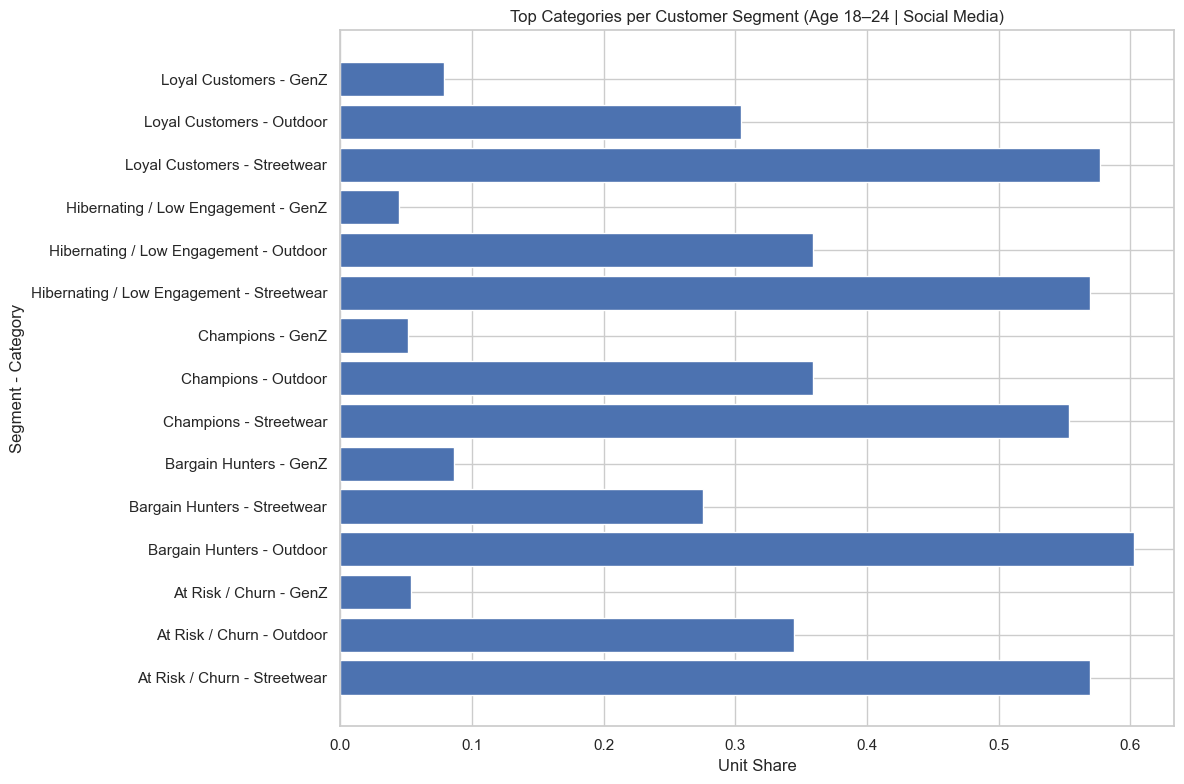

In [ ]:
top_seg = (
    young_social_by_segment
    .sort_values(["customer_segment", "unit_share"], ascending=[True, False])
    .groupby("customer_segment")
    .head(3)
)

plt.figure(figsize=(12, 8))

labels = top_seg["customer_segment"] + " - " + top_seg["category"]

plt.barh(labels, top_seg["unit_share"])

plt.xlabel("Unit Share")
plt.ylabel("Segment - Category")
plt.title("Top Categories per Customer Segment (Age 18–24 | Social Media)")

plt.tight_layout()
plt.show()

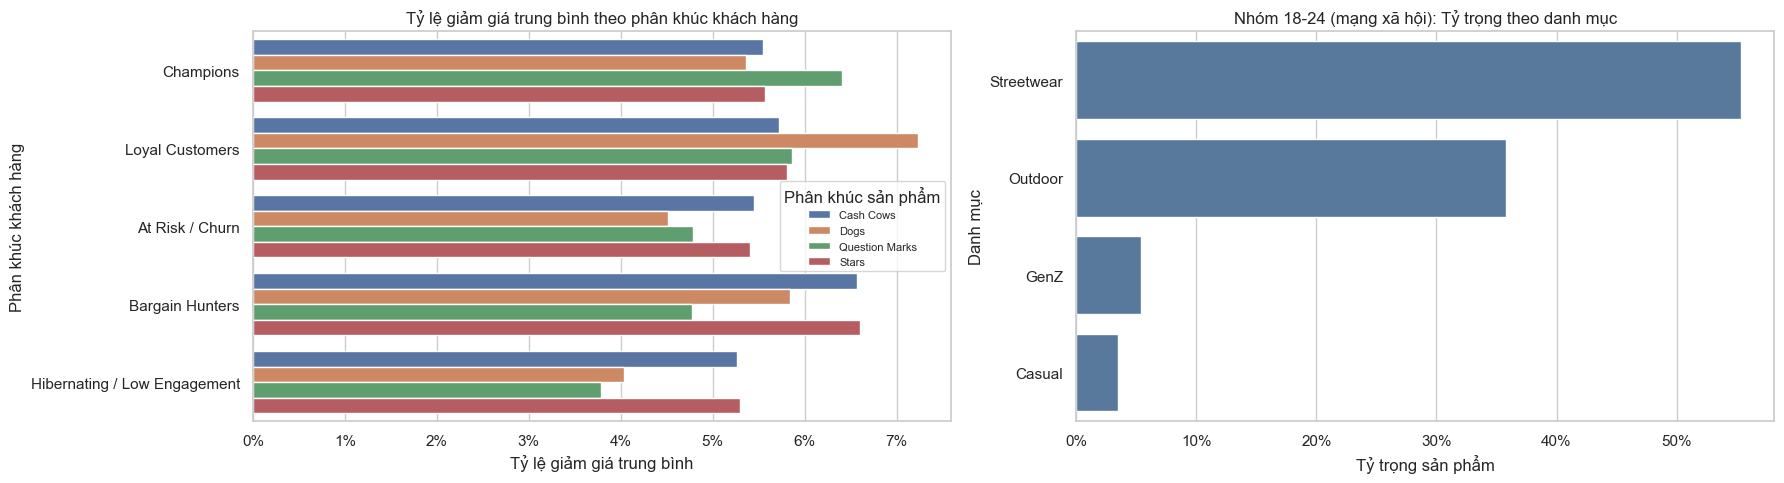

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Biểu đồ 1: Discount theo customer segment
sns.barplot(
    data=price_sensitivity,
    x="avg_discount_rate",
    y="customer_segment",
    hue="product_segment_pv",
    order=customer_segment_order,
    ax=axes[0]
)

axes[0].set_title("Tỷ lệ giảm giá trung bình theo phân khúc khách hàng")
axes[0].set_xlabel("Tỷ lệ giảm giá trung bình")
axes[0].set_ylabel("Phân khúc khách hàng")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].legend(title="Phân khúc sản phẩm", fontsize=8)


# Biểu đồ 2: Category của nhóm 18-24 từ social
sns.barplot(
    data=young_social_category_share,
    x="unit_share",
    y="category",
    ax=axes[1],
    color="#4C78A8"
)

axes[1].set_title("Nhóm 18-24 (mạng xã hội): Tỷ trọng theo danh mục")
axes[1].set_xlabel("Tỷ trọng sản phẩm")
axes[1].set_ylabel("Danh mục")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()


**Nhận xét:**

- **Quan sát:**
  - **Customer Segment → Product Segment:** Tất cả nhóm khách đều mua **Cash Cows** nhiều nhất, confidence khoảng **70-72%**, kế đến là **Stars** khoảng **31-35%**.
  - **Champions:** Có confidence gần cân bằng giữa `Streetwear|Everyday` và `Outdoor|Activewear`, đều khoảng **26.8%**; phù hợp để cross-sell từ sản phẩm volume cao sang sản phẩm Stars có margin cao.
  - **Bargain Hunters:** Có affinity nổi bật với `Outdoor|Activewear` với confidence khoảng **42.5%**; đồng thời promo/discount rate cao nhất trên Cash Cows và Stars, khoảng **44% line có promo** và discount rate khoảng **6.6%**.
  - **Kênh social_media nhóm 18-24:** Tổng thể mua **Streetwear ~55.3% units** và **Outdoor ~35.8% units**. Tuy nhiên riêng Bargain Hunters trong lát cắt này lại nghiêng mạnh về Outdoor, khoảng **60.3% units**.

- **Insights:**
  - **Không phải mọi segment đều cần cùng một product mix:** Champions và Loyal phù hợp với Streetwear/Outdoor cân bằng, trong khi Bargain Hunters phản ứng mạnh hơn với Outdoor Activewear và khuyến mãi.
  - **Stars nên được dùng làm sản phẩm nâng cấp:** Vì Stars có margin cao nhưng confidence thấp hơn Cash Cows, chiến lược tốt là bundle/recommendation đi kèm Cash Cows.
  - **Bargain Hunters có rủi ro làm loãng lợi nhuận:** Họ có mức nhạy khuyến mãi cao nhất nhưng giá trị vòng đời thấp nhất; voucher không điều kiện dễ ăn margin mà không tạo loyalty.
  - **Giả thuyết “18-24 social_media thích Streetwear” đúng ở tổng thể nhưng không đồng nhất:** Khi tách theo segment, Bargain Hunters trẻ đến từ social_media lại ưu tiên Outdoor.

- **Gợi ý hành động:**
  - **Champions:** Đẩy combo `Streetwear|Everyday` + Stars hoặc `Outdoor|Activewear` + phụ kiện margin cao; ưu tiên recommendation cá nhân hoá thay vì giảm giá mạnh.
  - **At Risk / Churn:** Dùng win-back gắn với category từng có confidence cao như `Streetwear|Everyday` và `Outdoor|Activewear`.
  - **Bargain Hunters:** Chạy promo có điều kiện trên Cash Cows/Outdoor Activewear, ví dụ minimum order value, bundle xả tồn, hoặc voucher chỉ dùng khi mua kèm Stars.
  - **18-24 social_media:** Tách campaign thành 2 nhánh: Streetwear creative cho Champions/Loyal/At Risk, Outdoor deal-led creative cho Bargain Hunters.

In [ ]:
# 4. Lưu bảng kết quả để dùng tiếp trong modeling/dashboard
customer_segments.to_csv(OUTPUT_DIR / "customer_rfm_segments.csv", index=False)
product_segments.to_csv(OUTPUT_DIR / "product_profit_volume_segments.csv", index=False)
cross_segment_summary.to_csv(OUTPUT_DIR / "customer_product_cross_mapping.csv", index=False)
pv_rules.to_csv(OUTPUT_DIR / "association_rules_customer_to_product_segment.csv", index=False)
catseg_rules.to_csv(OUTPUT_DIR / "association_rules_customer_to_category_segment.csv", index=False)

print("Saved outputs:")
for filename in [
    "customer_rfm_segments.csv",
    "product_profit_volume_segments.csv",
    "customer_product_cross_mapping.csv",
    "association_rules_customer_to_product_segment.csv",
    "association_rules_customer_to_category_segment.csv",
]:
    print("-", OUTPUT_DIR / filename)

Saved outputs:
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\customer_rfm_segments.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\product_profit_volume_segments.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\customer_product_cross_mapping.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\association_rules_customer_to_product_segment.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\association_rules_customer_to_category_segment.csv


# 4. Recommendation và khuyến mãi theo cá nhân hóa khách hàng và sản phẩm 

### 1. Uplift modeling

**Ý tưởng**:
Nâng cấp mô hình Uplift Modeling (T-Learner) để ước lượng tác động nhân quả của khuyến mãi ở cấp độ chi tiết từng dòng đơn hàng/sản phẩm (line-item level). Khác với phiên bản trước sử dụng dữ liệu mẫu âm (negative samples) nhân tạo, luồng xử lý này sử dụng trực tiếp trạng thái đơn hàng thực tế (giao thành công vs. các trạng thái khác) để làm biến mục tiêu. Đồng thời, mô hình được tích hợp thêm quy trình tự động tối ưu hóa siêu tham số (Hyperparameter Tuning) nhằm tối đa hóa khả năng phân loại và tính toán điểm Uplift chính xác hơn cho từng điểm chạm khách hàng - sản phẩm.

**Phương pháp sử dụng**:
*   **Thiết lập Dữ liệu sự kiện (Event-based Data Engineering):** Lấy từng dòng đơn hàng làm đơn vị quan sát. Xác định biến mục tiêu ($Y=1$) nếu đơn hàng được giao thành công (delivered) và $Y=0$ cho các trường hợp còn lại. Biến can thiệp ($T=1$) được xác định khi có áp dụng mã khuyến mãi.
*   **Trích xuất Đặc trưng toàn diện (Comprehensive Feature Extraction):** Xây dựng bộ đặc trưng (features) đa chiều bao gồm: Thuộc tính trước giao dịch (tháng, thứ đặt hàng), Vòng đời khách hàng (số ngày từ khi đăng ký), Hành vi quá khứ (RFM, tỷ lệ dùng promo), và Hiệu suất sản phẩm (lợi nhuận gộp, tỷ lệ trả hàng lịch sử).
*   **Tối ưu hóa Siêu tham số (Hyperparameter Tuning):** Sử dụng `ParameterSampler` (Random Search) kết hợp với cơ chế dừng sớm (`early_stopping`) để tự động tìm kiếm bộ tham số tối ưu (như `learning_rate`, `num_leaves`, `max_depth`...) cho các mô hình phân loại `LightGBM`. Quá trình này được thực hiện riêng biệt trên một tập Validation trích xuất (holdout) để chọn ra mô hình có điểm AUC cao nhất.
*   **Huấn luyện T-Learner cải tiến (Advanced T-Learner Modeling):** Huấn luyện hai mô hình LightGBM song song: một cho nhóm có khuyến mãi ($T=1$) và một cho nhóm không khuyến mãi ($T=0$). Áp dụng kỹ thuật cân bằng trọng số (`scale_pos_weight`) để xử lý tình trạng lệch pha dữ liệu (imbalanced classes).
*   **Tính toán Uplift Score:** Trên tập kiểm thử, sử dụng hai mô hình đã tối ưu để dự đoán xác suất mua thành công. Điểm Uplift được tính toán bằng phần chênh lệch ($P(Y|Promo) - P(Y|NoPromo)$), giúp doanh nghiệp phân loại khách hàng và cá nhân hóa mức độ ưu đãi.

#### a. Load data

In [ ]:
import pandas as pd
import numpy as np
import random
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

print("Loading data...")

CURRENT_PATH = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_PATH)
DATA_DIR = os.path.join(ROOT_DIR, "data", "raw")

customers = pd.read_csv(os.path.join(DATA_DIR, "customers.csv"))
geography = pd.read_csv(os.path.join(DATA_DIR, "geography.csv"))
orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"))
payments = pd.read_csv(os.path.join(DATA_DIR, "payments.csv"))
returns = pd.read_csv(os.path.join(DATA_DIR, "returns.csv"))
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"))
promotions = pd.read_csv(os.path.join(DATA_DIR, "promotions.csv"))
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"))

Loading data...


#### b. Feature engineering

In [ ]:
# 1. ĐẶC TRƯNG KHÁCH HÀNG & ĐỊA LÝ (Demographics)
print("Processing Demographics...")
if "geography" not in globals():
    geography = pd.read_csv(DATA_DIR / "geography.csv")

# geography.csv cũng có cột `city` nên chỉ lấy `region` để tránh trùng tên cột
customer_geo = customers.merge(geography[["zip", "region"]], on="zip", how="left")
demographics = customer_geo[
    ["customer_id", "age_group", "gender", "city", "region", "acquisition_channel"]
].copy()

# 2. ĐẶC TRƯNG SẢN PHẨM (Product Features)
print("Processing Product Features...")
if "returns" not in globals():
    returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])

# Chỉ dùng các order đã hoàn tất/đã giao để đại diện "đã mua"
fulfilled_orders = orders.loc[orders["order_status"].isin(["delivered", "returned"])].copy()
fulfilled_orders["order_date"] = pd.to_datetime(fulfilled_orders["order_date"])

# Merge order_items với orders để lấy customer_id, order_date, device_type (lọc theo fulfilled_orders)
line_items = order_items.merge(
    fulfilled_orders[["order_id", "customer_id", "order_date", "device_type"]],
    on="order_id",
    how="inner",
 )

# Tính tổng bán ra theo sản lượng (quantity)
sales_qty = (
    line_items.groupby("product_id", as_index=False)["quantity"]
    .sum()
    .rename(columns={"quantity": "total_sold"})
 )

# Tính tổng trả hàng
returns_qty = (
    returns.groupby("product_id", as_index=False)["return_quantity"]
    .sum()
    .rename(columns={"return_quantity": "total_returned"})
 )

# Merge vào products
prod_features = (
    products.merge(sales_qty, on="product_id", how="left")
    .merge(returns_qty, on="product_id", how="left")
 )

prod_features["total_sold"] = prod_features["total_sold"].fillna(0)
prod_features["total_returned"] = prod_features["total_returned"].fillna(0)

# Tính Lợi nhuận gộp & Tỷ lệ đổi trả
prod_features["gross_profit_historical"] = prod_features["price"] - prod_features["cogs"]
prod_features["return_rate"] = (
    prod_features["total_returned"] / prod_features["total_sold"].replace(0, np.nan)
 ).fillna(0)

prod_features = prod_features[["product_id", "gross_profit_historical", "return_rate"]].copy()

# ==========================================
# 3. TREATMENT (T), TARGET (Y=1) & LỊCH SỬ KHUYẾN MÃI
# ==========================================
print("Processing Behavioral & Treatment...")

df_base = line_items.copy()

# Tính Treatment T=1 (nếu có promo_id hoặc promo_id_2)
promo_flag = df_base["promo_id"].notna()
if "promo_id_2" in df_base.columns:
    promo_flag = promo_flag | df_base["promo_id_2"].notna()
df_base["T"] = promo_flag.astype(int)

# Các dòng trong df_base là đã mua (trên tập order fulfilled)
df_base["Y"] = 1

# Tính tỷ lệ đơn hàng có khuyến mãi trong lịch sử của từng user (promo_order_rate)
promo_order_counts = df_base.groupby(["customer_id", "order_id"], as_index=False)["T"].max()
user_promo_rate = (
    promo_order_counts.groupby("customer_id", as_index=False)
    .agg(total_orders=("order_id", "count"), promo_orders=("T", "sum"))
 )
user_promo_rate["promo_order_rate"] = user_promo_rate["promo_orders"] / user_promo_rate["total_orders"]

# ==========================================
# 4. RFM (Recency, Frequency, Monetary)
# ==========================================
print("Processing RFM...")
current_date = fulfilled_orders["order_date"].max()

rfm = (
    fulfilled_orders.groupby("customer_id")
    .agg(
        Recency=("order_date", lambda x: (current_date - x.max()).days),
        Frequency=("order_id", "nunique"),
    )
    .reset_index()
 )

# Monetary: payments.csv không có customer_id => join với fulfilled_orders theo order_id
payments_fulfilled = payments.merge(
    fulfilled_orders[["order_id", "customer_id"]],
    on="order_id",
    how="inner",
 )
monetary = (
    payments_fulfilled.groupby("customer_id", as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "Monetary"})
 )
rfm = rfm.merge(monetary, on="customer_id", how="left")
rfm["Monetary"] = rfm["Monetary"].fillna(0)

# Gom tất cả User Features lại
user_features = demographics.merge(rfm, on="customer_id", how="inner")
user_features = user_features.merge(
    user_promo_rate[["customer_id", "promo_order_rate"]],
    on="customer_id",
    how="left",
 )
user_features["promo_order_rate"] = user_features["promo_order_rate"].fillna(0)

# Giữ lại device_type (Lấy device phổ biến nhất của user trên fulfilled_orders)
top_device = (
    fulfilled_orders.groupby("customer_id")["device_type"]
    .agg(lambda x: x.value_counts(dropna=True).index[0] if x.notna().any() else np.nan)
    .reset_index()
 )
user_features = user_features.merge(top_device, on="customer_id", how="left")

Processing Demographics...
Processing Product Features...
Processing Behavioral & Treatment...
Processing RFM...


#### c. TẠO NEGATIVE SAMPLES (Y=0, T=0)

In [ ]:
print("Building Modeling Dataset for Uplift (no synthetic negatives)...")

# Dataset uplift hợp lệ: dùng order_items + order_status để có đủ Y=0/1 ở cả T=0 và T=1
# Đơn vị quan sát: 1 dòng order_items (customer, product, order)

# Base events
df_events = order_items.merge(
    orders[[
        "order_id",
        "customer_id",
        "order_date",
        "order_status",
        "payment_method",
        "device_type",
        "order_source",
    ]],
    on="order_id",
    how="left",
 )

# --- Treatment ---
promo_cols = [c for c in ["promo_id", "promo_id_2"] if c in df_events.columns]
if promo_cols:
    promo_flag = df_events[promo_cols].notna().any(axis=1)
else:
    promo_flag = pd.Series(False, index=df_events.index)
df_events["T"] = promo_flag.astype(int)

# --- Outcome ---
# Y=1 nếu đơn được giao thành công (delivered); còn lại là 0
df_events["Y"] = df_events["order_status"].eq("delivered").astype(int)

# --- Time features (pre-treatment) ---
df_events["order_date"] = pd.to_datetime(df_events["order_date"], errors="coerce")
df_events["order_month"] = df_events["order_date"].dt.month.astype("Int64")
df_events["order_dow"] = df_events["order_date"].dt.dayofweek.astype("Int64")

# --- Customer tenure (pre-treatment) ---
signup = customers[["customer_id", "signup_date"]].copy()
signup["signup_date"] = pd.to_datetime(signup["signup_date"], errors="coerce")
df_events = df_events.merge(signup, on="customer_id", how="left")
df_events["customer_tenure_days"] = (df_events["order_date"] - df_events["signup_date"]).dt.days
df_events["customer_tenure_days"] = df_events["customer_tenure_days"].clip(lower=0)

# --- Product attributes (pre-treatment) ---
product_attrs = products[["product_id", "category", "segment", "size", "color", "price", "cogs"]].copy()
df_events = df_events.merge(product_attrs, on="product_id", how="left")

# Chỉ giữ các cột cần cho modeling + merge features
df_events = df_events[[
    "customer_id",
    "product_id",
    "payment_method",
    "device_type",
    "order_source",
    "order_month",
    "order_dow",
    "customer_tenure_days",
    "category",
    "segment",
    "size",
    "color",
    "price",
    "cogs",
    "T",
    "Y",
]].copy()

# Merge user/product features (pre-treatment)
user_feat = user_features.drop(columns=["device_type"], errors="ignore")
master_df = (
    df_events.merge(user_feat, on="customer_id", how="left")
    .merge(prod_features, on="product_id", how="left")
 )

# Missing values
master_df.fillna({
    "gross_profit_historical": 0,
    "return_rate": 0,
    "price": 0,
    "cogs": 0,
    "customer_tenure_days": master_df["customer_tenure_days"].median() if "customer_tenure_days" in master_df.columns else 0,
    "order_month": master_df["order_month"].mode().iloc[0] if "order_month" in master_df.columns and master_df["order_month"].notna().any() else 1,
    "order_dow": master_df["order_dow"].mode().iloc[0] if "order_dow" in master_df.columns and master_df["order_dow"].notna().any() else 0,
    "age_group": "Unknown",
    "gender": "Unknown",
    "city": "Unknown",
    "region": "Unknown",
    "acquisition_channel": "Unknown",
    "device_type": "Unknown",
    "order_source": "Unknown",
    "payment_method": "Unknown",
    "category": "Unknown",
    "segment": "Unknown",
    "size": "Unknown",
    "color": "Unknown",
    "promo_order_rate": 0,
    "Recency": master_df["Recency"].median() if "Recency" in master_df.columns else 0,
    "Frequency": master_df["Frequency"].median() if "Frequency" in master_df.columns else 0,
    "Monetary": 0,
}, inplace=True)

# Categorical cols for LightGBM
categorical_cols = [
    "age_group",
    "gender",
    "city",
    "region",
    "acquisition_channel",
    "device_type",
    "order_source",
    "payment_method",
    "category",
    "segment",
    "size",
    "color",
 ]
for col in categorical_cols:
    master_df[col] = master_df[col].astype("category")

# Features (X)
features = [
    "Recency", "Frequency", "Monetary", "promo_order_rate",
    "customer_tenure_days", "order_month", "order_dow",
    "age_group", "gender", "city", "region", "acquisition_channel",
    "device_type", "order_source", "payment_method",
    "category", "segment", "size", "color",
    "price", "cogs",
    "gross_profit_historical", "return_rate",
 ]

X = master_df[features]
T = master_df["T"]
Y = master_df["Y"]

print(f"Rows: {len(master_df):,} | T rate: {T.mean():.3f} | Y rate: {Y.mean():.3f}")
display(pd.crosstab(T, Y, normalize="index"))

Building Modeling Dataset for Uplift (no synthetic negatives)...
Rows: 714,669 | T rate: 0.387 | Y rate: 0.799


Y,0,1
T,,
0,0.20,0.80
1,0.20,0.80


#### d. UPLIFT MODELING (T-LEARNER VỚI LIGHTGBM)

In [ ]:
print("Training T-Learner (LightGBM) with tuning...")

import numpy as np
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
N_ITER = 25
EARLY_STOPPING_ROUNDS = 100
MAX_TUNING_ROWS = 200_000
N_ESTIMATORS = 5000

def _safe_auc(y_true, y_prob):
    if getattr(y_true, "nunique", lambda: len(set(y_true)))() < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

def tune_and_fit_lgbm_classifier(X_group, y_group, categorical_cols, *, random_state=42):
    """Random search + early stopping on a holdout validation set."""
    if len(X_group) > MAX_TUNING_ROWS:
        X_tune, _, y_tune, _ = train_test_split(
            X_group,
            y_group,
            train_size=MAX_TUNING_ROWS,
            random_state=random_state,
            stratify=y_group,
        )
    else:
        X_tune, y_tune = X_group, y_group

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tune,
        y_tune,
        test_size=0.2,
        random_state=random_state,
        stratify=y_tune,
    )

    # scale_pos_weight giúp ổn định khi hơi lệch class
    pos = float(y_tr.sum())
    neg = float(len(y_tr) - y_tr.sum())
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    param_dist = {
        "learning_rate": [0.02, 0.03, 0.05, 0.07, 0.10, 0.15],
        "num_leaves": [31, 63, 127, 255],
        "max_depth": [-1, 5, 7, 9, 12],
        "min_child_samples": [20, 50, 100, 200],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0.0, 0.1, 0.3, 1.0],
        "reg_lambda": [0.0, 0.1, 1.0, 5.0, 10.0],
        "min_split_gain": [0.0, 0.01, 0.05, 0.1],
    }

    best_auc = -np.inf
    best_params = None
    best_iter = None

    for params in ParameterSampler(param_dist, n_iter=N_ITER, random_state=random_state):
        model = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=N_ESTIMATORS,
            random_state=random_state,
            n_jobs=-1,
            subsample_freq=1,
            scale_pos_weight=scale_pos_weight,
            verbosity=-1,
            **params,
        )
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            categorical_feature=categorical_cols,
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )
        val_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, val_pred)
        if auc > best_auc:
            best_auc = auc
            best_params = params
            best_iter = int(model.best_iteration_ or model.n_estimators_)

    # Refit on full group (train) with best_iteration for stability
    pos_full = float(y_group.sum())
    neg_full = float(len(y_group) - y_group.sum())
    spw_full = (neg_full / pos_full) if pos_full > 0 else 1.0

    final_model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=best_iter,
        random_state=random_state,
        n_jobs=-1,
        subsample_freq=1,
        scale_pos_weight=spw_full,
        verbosity=-1,
        **(best_params or {}),
    )
    final_model.fit(X_group, y_group, categorical_feature=categorical_cols)
    return final_model, best_params, best_auc, best_iter

# Split Train/Test (stratify theo cả T và Y để tránh mất class trong từng nhóm)
stratify_key = T.astype(str) + "_" + Y.astype(str)
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_key,
 )

# --- Model 1 (Treatment: T=1) ---
mask_train_t1 = T_train.eq(1)
X_train_T1 = X_train.loc[mask_train_t1]
Y_train_T1 = Y_train.loc[mask_train_t1]

model_t1, best_params_t1, best_auc_t1, best_iter_t1 = tune_and_fit_lgbm_classifier(
    X_train_T1, Y_train_T1, categorical_cols, random_state=RANDOM_STATE
 )
print(f"T=1 best AUC (val, tune sample): {best_auc_t1:.4f} | best_iter: {best_iter_t1} | params: {best_params_t1}")

# --- Model 0 (Control: T=0) ---
mask_train_t0 = T_train.eq(0)
X_train_T0 = X_train.loc[mask_train_t0]
Y_train_T0 = Y_train.loc[mask_train_t0]

model_t0, best_params_t0, best_auc_t0, best_iter_t0 = tune_and_fit_lgbm_classifier(
    X_train_T0, Y_train_T0, categorical_cols, random_state=RANDOM_STATE
 )
print(f"T=0 best AUC (val, tune sample): {best_auc_t0:.4f} | best_iter: {best_iter_t0} | params: {best_params_t0}")

# --- Evaluate on Test ---
mask_test_t1 = T_test.eq(1)
mask_test_t0 = T_test.eq(0)

auc_test_t1 = _safe_auc(Y_test.loc[mask_test_t1], model_t1.predict_proba(X_test.loc[mask_test_t1])[:, 1])
auc_test_t0 = _safe_auc(Y_test.loc[mask_test_t0], model_t0.predict_proba(X_test.loc[mask_test_t0])[:, 1])
print(f"AUC on test | model_t1 (T=1): {auc_test_t1:.4f} | model_t0 (T=0): {auc_test_t0:.4f}")

# --- Predict Uplift Score trên Test Set ---
print("Scoring Uplift...")
prob_t1 = model_t1.predict_proba(X_test)[:, 1]
prob_t0 = model_t0.predict_proba(X_test)[:, 1]
uplift_score = prob_t1 - prob_t0

results_df = X_test.copy()
results_df["True_Y"] = Y_test
results_df["True_T"] = T_test
results_df["P_Y_given_Promo"] = prob_t1
results_df["P_Y_given_NoPromo"] = prob_t0
results_df["Uplift_Score"] = uplift_score

print("Hoàn tất! 5 uplift predictions đầu tiên:")
display(results_df[["P_Y_given_Promo", "P_Y_given_NoPromo", "Uplift_Score"]].head())

Training T-Learner (LightGBM) with tuning...
T=1 best AUC (val, tune sample): 0.6321 | best_iter: 5 | params: {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'num_leaves': 127, 'min_split_gain': 0.1, 'min_child_samples': 20, 'max_depth': 12, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
T=0 best AUC (val, tune sample): 0.6101 | best_iter: 5 | params: {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'num_leaves': 127, 'min_split_gain': 0.1, 'min_child_samples': 20, 'max_depth': 12, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
AUC on test | model_t1 (T=1): 0.6329 | model_t0 (T=0): 0.6099
Scoring Uplift...
Hoàn tất! 5 uplift predictions đầu tiên:


,P_Y_given_Promo,P_Y_given_NoPromo,Uplift_Score
36168,0.73,0.78,-0.05
264103,0.77,0.77,-0.00
700650,0.76,0.76,0.00
525667,0.78,0.77,0.00
390010,0.78,0.77,0.01


In [ ]:
# Lưu dự đoán test-set (kèm customer_id/product_id để triển khai campaign)
results_out = results_df.copy()

# Map lại định danh từ master_df theo index (giữ nguyên index sau train_test_split)
if "master_df" in globals():
    for key in ["customer_id", "product_id", "order_id"]:
        if key in master_df.columns and key not in results_out.columns:
            results_out[key] = master_df.loc[results_out.index, key].values

# Ưu tiên export các cột định danh ở đầu file
id_cols = [c for c in ["customer_id", "product_id", "order_id"] if c in results_out.columns]
results_out = results_out[id_cols + [c for c in results_out.columns if c not in id_cols]]

results_out.to_csv(OUTPUT_DIR / "uplift_predictions_test_set.csv", index=False)
print("Saved:", OUTPUT_DIR / "uplift_predictions_test_set.csv")

Saved: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\uplift_predictions_test_set.csv


In [ ]:
results_df.head(10)

,Recency,Frequency,Monetary,promo_order_rate,customer_tenure_days,order_month,order_dow,age_group,gender,city,region,acquisition_channel,device_type,order_source,payment_method,category,segment,size,color,price,cogs,gross_profit_historical,return_rate,True_Y,True_T,P_Y_given_Promo,P_Y_given_NoPromo,Uplift_Score
36168,206.00,6.00,"178,038.78",0.00,0,12,0,55+,Male,Hai Phong,East,direct,mobile,referral,credit_card,Outdoor,Activewear,L,green,"1,341.31","1,274.25",67.07,0.04,1,0,0.73,0.78,-0.05
264103,123.00,14.00,"380,182.21",0.36,0,6,1,45-54,Female,Phu Ly,East,email_campaign,desktop,referral,credit_card,Streetwear,Everyday,XL,black,"2,020.00","1,168.16",851.83,0.04,1,1,0.77,0.77,-0.00
700650,165.00,14.00,"332,175.87",0.43,3616,7,1,35-44,Male,Hue,Central,email_campaign,desktop,organic_search,cod,Casual,All-weather,S,orange,"6,296.41","5,981.59",314.82,0.04,1,0,0.76,0.76,0.00
525667,"1,649.00",9.00,"229,198.16",0.44,71,6,1,55+,Male,Hoi An,Central,social_media,desktop,direct,credit_card,GenZ,Trendy,L,orange,"3,733.95","1,874.44","1,859.51",0.03,1,1,0.78,0.77,0.00
390010,"1,620.00",4.00,"230,182.29",0.50,0,11,1,55+,Non-binary,Bac Ninh,East,organic_search,tablet,paid_search,bank_transfer,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70","1,438.87",0.05,1,1,0.78,0.77,0.01
6276,"1,948.00",4.00,"57,366.68",0.75,0,8,4,35-44,Female,Ninh Binh,East,organic_search,desktop,direct,credit_card,Outdoor,Activewear,S,pink,"1,148.82",728.93,419.89,0.04,1,0,0.78,0.76,0.01
372510,611.00,14.00,"299,653.98",0.43,0,8,5,35-44,Female,Ninh Binh,East,organic_search,desktop,organic_search,credit_card,GenZ,Trendy,S,red,"1,188.35",915.38,272.96,0.04,1,0,0.77,0.77,-0.00
369573,191.00,6.00,"198,586.86",0.17,827,8,1,25-34,Male,Da Nang,Central,referral,desktop,organic_search,credit_card,Outdoor,Activewear,M,blue,"1,012.76",643.51,369.25,0.04,1,0,0.76,0.78,-0.02
575952,"1,316.00",1.00,"40,746.78",0.00,0,5,5,25-34,Male,Phu Ly,East,paid_search,desktop,referral,apple_pay,Streetwear,Balanced,XL,silver,"19,779.23","18,790.27",988.96,0.04,1,0,0.73,0.78,-0.05
245599,67.00,14.00,"352,037.92",0.29,0,5,2,25-34,Male,Tam Ky,Central,direct,desktop,referral,credit_card,Streetwear,Everyday,XL,yellow,"5,399.83","3,136.76","2,263.07",0.03,1,0,0.77,0.78,-0.00


### 2. Profit optimization bằng chia phân khúc nhận promotion

##### Phân loại khách hàng và Tính toán theo nhóm (Decile Analysis)

**Ý tưởng**:
Chia tập khách hàng thành 10 nhóm (Deciles) có kích thước bằng nhau dựa trên điểm `Uplift_Score` dự đoán từ cao xuống thấp. Việc này giúp doanh nghiệp nhìn rõ bức tranh: nhóm Top 10%, Top 20% mang lại hiệu quả thực tế (Actual Uplift) là bao nhiêu, đâu là nhóm "Persuadables" (nên đổ tiền) và đâu là nhóm "Sleeping Dogs" (ngừng gửi promo). Đồng thời đây là cơ sở để tính toán điểm hòa vốn (ROI Threshold).

**Phương pháp sử dụng**:
Sử dụng thư viện `pandas`, hàm `pd.qcut` để chia bin tự động. Sau đó dùng `groupby` trên từng nhóm để tính toán: Tỷ lệ chuyển đổi của nhóm được nhận khuyến mãi (`True_T` = 1), nhóm không nhận khuyến mãi (`True_T` = 0) và khoảng chênh lệch (Actual Uplift) giữa hai nhóm này.

In [ ]:
df_results = pd.read_csv(os.path.join(ROOT_DIR, "outputs", "uplift_predictions_test_set.csv"))

# Sắp xếp dữ liệu theo Uplift_Score giảm dần
df_results = df_results.sort_values(by="Uplift_Score", ascending=False).reset_index(drop=True)

# Chia khách hàng thành 10 nhóm (Deciles) - Nhóm 1 là Uplift cao nhất
df_results['Decile'] = pd.qcut(df_results.index, 10, labels=np.arange(1, 11))

# Hàm tính toán Actual Uplift cho từng Decile
def calc_uplift_metrics(group):
    # Lọc nhóm Treatment (T=1) và Control (T=0)
    treatment = group[group['True_T'] == 1]
    control = group[group['True_T'] == 0]
    
    # Tỷ lệ mua hàng (Conversion Rate) thực tế
    cr_treatment = treatment['True_Y'].mean() if len(treatment) > 0 else 0
    cr_control = control['True_Y'].mean() if len(control) > 0 else 0
    
    # Kích thước tập khách hàng
    n_treatment = len(treatment)
    n_control = len(control)
    
    return pd.Series({
        'N_Customers': len(group),
        'Avg_Pred_Uplift': group['Uplift_Score'].mean(),
        'CR_Treatment': cr_treatment,
        'CR_Control': cr_control,
        'Actual_Uplift': cr_treatment - cr_control
    })

# Tổng hợp dữ liệu theo Decile
decile_analysis = df_results.groupby('Decile').apply(calc_uplift_metrics).reset_index()

# Hiển thị bảng phân tích (tập trung vào nhóm 1,2,3... để quyết định điểm cắt)
print("Bảng phân tích hiệu quả chiến dịch theo Decile:")
display(decile_analysis)

Bảng phân tích hiệu quả chiến dịch theo Decile:


,Decile,N_Customers,Avg_Pred_Uplift,CR_Treatment,CR_Control,Actual_Uplift
0,1,"14,294.00",0.03,0.86,0.66,0.20
1,2,"14,293.00",0.01,0.84,0.76,0.07
2,3,"14,293.00",0.00,0.83,0.78,0.04
3,4,"14,294.00",0.00,0.82,0.80,0.02
4,5,"14,293.00",0.00,0.80,0.81,-0.00
5,6,"14,293.00",-0.00,0.75,0.76,-0.01
6,7,"14,294.00",-0.00,0.78,0.81,-0.03
7,8,"14,293.00",-0.01,0.77,0.83,-0.05
8,9,"14,293.00",-0.01,0.72,0.82,-0.10
9,10,"14,294.00",-0.04,0.40,0.84,-0.44


##### Vẽ biểu đồ Qini Curve / Uplift Curve (Đánh giá chiến lược)

**Ý tưởng**:
Vẽ biểu đồ Qini Curve để trực quan hóa giá trị gia tăng lũy kế (Cumulative Incremental Conversions) khi ta tuần tự tiếp cận khách hàng theo thứ tự ưu tiên của mô hình thay vì gửi ngẫu nhiên. Đường cong càng vút lên cao so với đường chéo (Random Curve) chứng tỏ mô hình càng hiệu quả trong việc "săn" đúng nhóm khách hàng nhạy cảm với khuyến mãi.

**Phương pháp sử dụng**:
Duyệt qua danh sách đã được sắp xếp giảm dần theo `Uplift_Score`. Tại mỗi điểm cắt, tính số lượng đơn hàng tích lũy của nhóm Treatment (`True_T` = 1) trừ đi số lượng đơn hàng tích lũy của nhóm Control (`True_T` = 0) (có chuẩn hóa theo số lượng mẫu của Treatment). Sử dụng `matplotlib` để vẽ đường cong này cùng với đường ngẫu nhiên (Random targeting) để làm mốc so sánh.

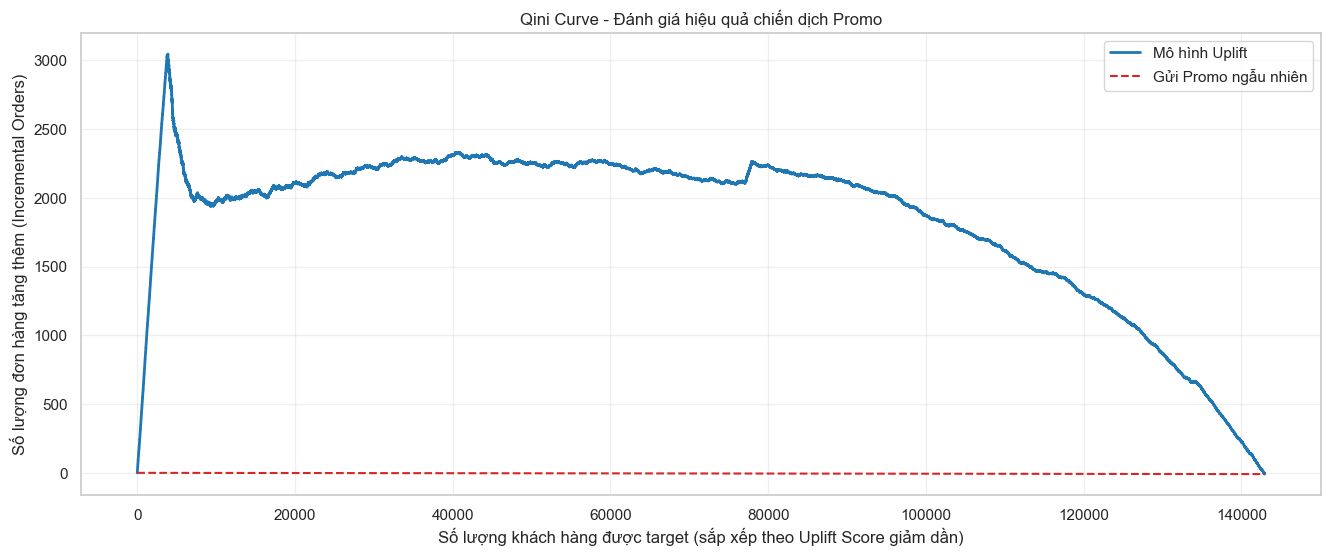

In [ ]:
df_results = pd.read_csv(os.path.join(ROOT_DIR, "outputs", "uplift_predictions_test_set.csv"))

df_results = df_results.sort_values(by='Uplift_Score', ascending=False).reset_index(drop=True)

# Lọc riêng True_Y và True_T
y_true = df_results['True_Y'].values
t_true = df_results['True_T'].values

# Tính toán các giá trị tích lũy (cumsum)
# Số người trong nhóm T=1 và T=0 tích lũy tại mỗi bước
cumsum_t1 = np.cumsum(t_true == 1)
cumsum_t0 = np.cumsum(t_true == 0)

# Số người MUA HÀNG trong nhóm T=1 và T=0 tích lũy tại mỗi bước
cumsum_y1 = np.cumsum((t_true == 1) & (y_true == 1))
cumsum_y0 = np.cumsum((t_true == 0) & (y_true == 1))

# Qini = (Y1_cumsum) - (Y0_cumsum * (N1_cumsum / N0_cumsum))
# Xử lý chia cho 0 bằng cách dùng np.divide và where
qini_values = cumsum_y1 - cumsum_y0 * np.divide(
    cumsum_t1, cumsum_t0, out=np.zeros_like(cumsum_t1, dtype=float), where=cumsum_t0!=0
)

# Thêm điểm 0 vào đầu đồ thị
qini_values = np.insert(qini_values, 0, 0)
x_axis = np.arange(len(qini_values))
total_customers = len(df_results)

# Điểm kết thúc của đường Random (nối từ 0 đến điểm cuối cùng của Qini)
random_qini = x_axis * (qini_values[-1] / total_customers)

# Vẽ biểu đồ
plt.figure(figsize=(16, 6))
plt.plot(x_axis, qini_values, label='Mô hình Uplift', color='tab:blue', linewidth=2)
plt.plot(x_axis, random_qini, label='Gửi Promo ngẫu nhiên', color='tab:red', linestyle='--')

plt.title('Qini Curve - Đánh giá hiệu quả chiến dịch Promo')
plt.xlabel('Số lượng khách hàng được target (sắp xếp theo Uplift Score giảm dần)')
plt.ylabel('Số lượng đơn hàng tăng thêm (Incremental Orders)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Nhận xét:**

- **Quan sát:**
  - **Đường cong mô hình Uplift:** Đồ thị bứt phá cực mạnh ngay từ những tập khách hàng đầu tiên. Đỉnh cao nhất (peak) đạt mức hơn 3,000 đơn hàng tăng thêm (incremental orders) chỉ với khoảng 5,000 - 10,000 khách hàng được target. Từ mốc 80,000 khách hàng trở đi, đường cong đi xuống dốc rõ rệt và rơi thẳng về mốc 0 tại điểm cuối (140,000 khách hàng).
  - **Đường gửi Promo ngẫu nhiên (Baseline):** Đường nét đứt màu đỏ nằm ngang hoàn toàn ở mức 0 dọc theo toàn bộ trục X. 
  - **Tổng quan:** Khoảng cách giữa đường Uplift (LightGBM) và đường ngẫu nhiên tạo ra một diện tích Qini (Qini Area) dương rất lớn ở phần lớn trục hoành, chứng tỏ mô hình phân loại và ranking Uplift Score cực kỳ hiệu quả, vượt trội hoàn toàn so với phương pháp tiếp cận đại trà.

- **Insights:**
  - **Nhận diện chính xác nhóm "Persuadables":** Mô hình LightGBM đã gom thành công nhóm khách hàng "dễ bị thuyết phục" nhất lên đầu danh sách (Uplift Score cao nhất). Việc chỉ cần target một nhóm rất nhỏ này nhưng lại thu về lượng đơn hàng khổng lồ mang lại tỷ suất hoàn vốn (ROI) tối đa cho chiến dịch khuyến mãi.
  - **Phát hiện rủi ro từ nhóm "Sleeping Dogs":** Đoạn dốc đổ nhào từ mốc 80,000 chứng minh sự tồn tại của một tệp khách hàng có phản ứng ngược (Negative Treatment Effect). Nếu cố tình gửi promo cho nhóm này, doanh nghiệp không những lãng phí ngân sách Marketing mà còn trực tiếp làm mất đi đơn hàng (khách hàng có thể cảm thấy bị spam, phiền phức và quyết định không mua hoặc rời bỏ thương hiệu).
  - **Bức tranh ATE (Average Treatment Effect) tổng thể:** Việc đường ngẫu nhiên nằm ở mốc 0 và đường mô hình kết thúc tại 0 cho thấy một sự thật phũ phàng: Nếu chạy chiến dịch "phủ sóng" cho toàn bộ 140,000 người, hiệu quả tăng thêm tổng thể sẽ bị triệt tiêu hoàn toàn. Causal ML ở đây đã đóng vai trò "cứu cánh" toàn bộ chiến dịch.

- **Gợi ý hành động:**
  - **Thiết lập điểm cắt (Cut-off Point) tối ưu:** Cắt bỏ hoàn toàn chiến lược gửi promo đại trà. Thiết lập ngưỡng target chặt chẽ tại mốc 5,000 - 10,000 khách hàng (vùng đỉnh của đồ thị Qini) để hái "trái ngọt" (hơn 3,000 đơn hàng tăng thêm) với chi phí phát hành voucher/promo thấp nhất.
  - **Tích hợp vào hệ thống Two-Stage Causal ML:** Số lượng đơn hàng tăng thêm ở biểu đồ này mới giải quyết bài toán của Stage 1 (Phân loại & Ranking). Bước tiếp theo, bắt buộc phải đưa đầu ra (Uplift Score) này vào phương trình kỳ vọng E[Profit] ở Stage 2. Sự kết hợp này giúp đánh giá chéo giữa xác suất phát sinh thêm đơn và giá trị biên lợi nhuận của từng đơn, từ đó tìm ra điểm cắt tối ưu hóa lợi nhuận ròng thay vì chỉ tối ưu số lượng.
  - **Ứng dụng XAI (Explainable AI) để thấu hiểu:** Sử dụng SHAP để "mở hộp đen" mô hình LightGBM hiện tại. Việc bóc tách SHAP values sẽ giúp xác định rõ các đặc trưng (features) nào đang đóng góp vào việc định hình hành vi của nhóm "Persuadables" (vùng đỉnh đồ thị) và nhóm "Sleeping Dogs" (vùng đuôi). Từ insights này, team có thể tinh chỉnh lại điều kiện khuyến mãi và cá nhân hóa thông điệp sâu hơn.

#### Trích xuất danh sách Target Group & Phân bổ cho A/B Testing

**Ý tưởng**:
Dựa trên phân tích, ta chỉ nên chọn những khách hàng có `Uplift_Score` mang lại lợi nhuận dương để chạy chiến dịch (loại bỏ nhóm "Chắc chắn mua" hoặc "Tránh làm phiền"). Sau khi lọc được tệp Target, ta không gửi 100% promo mà chia ra 80% thực sự nhận tin (Treatment) và 20% không nhận tin (Holdout/Control) để đo lường ROI trên thực tế ngoài thị trường.

**Phương pháp sử dụng**:
Sử dụng toán tử lọc của pandas (`df[df['Uplift_Score'] > threshold]`) để lấy danh sách mục tiêu. Ở đây giả định `threshold = 0.0` (Chỉ target người có Uplift dương). Sau đó dùng hàm `sample()` với tham số `frac` để chia ngẫu nhiên danh sách này thành hai nhóm để xuất ra file CSV gửi cho hệ thống Marketing Automation.

In [ ]:
K_MIN = 5_000
K_MAX = 10_000
AB_TREATMENT_FRAC = 0.8
RANDOM_STATE = 42

# Đảm bảo df_results có customer_id (được export từ cell lưu predictions)
if "df_results" not in globals():
    df_results = pd.read_csv(OUTPUT_DIR / "uplift_predictions_test_set.csv")

if "customer_id" not in df_results.columns:
    raise ValueError(
        "Thiếu customer_id trong df_results. Hãy chạy lại cell lưu predictions để export kèm customer_id."
    )

# Nếu chưa có qini_values trong kernel thì tính lại nhanh (giống cell Qini)
if "qini_values" not in globals():
    df_tmp = df_results.sort_values(by="Uplift_Score", ascending=False).reset_index(drop=True)
    y_true = df_tmp["True_Y"].values
    t_true = df_tmp["True_T"].values
    cumsum_t1 = np.cumsum(t_true == 1)
    cumsum_t0 = np.cumsum(t_true == 0)
    cumsum_y1 = np.cumsum((t_true == 1) & (y_true == 1))
    cumsum_y0 = np.cumsum((t_true == 0) & (y_true == 1))
    qini_values = cumsum_y1 - cumsum_y0 * np.divide(
        cumsum_t1, cumsum_t0, out=np.zeros_like(cumsum_t1, dtype=float), where=cumsum_t0 != 0
    )
    qini_values = np.insert(qini_values, 0, 0)

qini_arr = np.asarray(qini_values, dtype=float)
n_obs = len(df_results)
if len(qini_arr) != n_obs + 1:
    # fallback: nếu lệch chiều dài, tính lại để tránh dùng sai
    df_tmp = df_results.sort_values(by="Uplift_Score", ascending=False).reset_index(drop=True)
    y_true = df_tmp["True_Y"].values
    t_true = df_tmp["True_T"].values
    cumsum_t1 = np.cumsum(t_true == 1)
    cumsum_t0 = np.cumsum(t_true == 0)
    cumsum_y1 = np.cumsum((t_true == 1) & (y_true == 1))
    cumsum_y0 = np.cumsum((t_true == 0) & (y_true == 1))
    qini_arr = cumsum_y1 - cumsum_y0 * np.divide(
        cumsum_t1, cumsum_t0, out=np.zeros_like(cumsum_t1, dtype=float), where=cumsum_t0 != 0
    )
    qini_arr = np.insert(qini_arr, 0, 0)

# Chọn cut-off: tối đa hóa incremental orders trong vùng 5k–10k (nếu đủ data)
if len(qini_arr) >= K_MAX + 1:
    k_star = K_MIN + int(np.nanargmax(qini_arr[K_MIN : K_MAX + 1]))
else:
    k_star = int(np.nanargmax(qini_arr))
    k_star = int(np.clip(k_star, 1, min(K_MAX, n_obs)))

incremental_at_k = float(qini_arr[k_star])
print(f"Cut-off tối ưu (theo Qini): top {k_star:,} (incremental ≈ {incremental_at_k:,.0f})")

# Rank theo customer-level uplift: lấy MAX uplift của customer trong test set
customer_scores = (
    df_results.groupby("customer_id", as_index=False)
    .agg(Uplift_Score=("Uplift_Score", "max"))
    .sort_values("Uplift_Score", ascending=False)
 )

# Chỉ target đúng top-k_star customers (không đại trà)
k_star_customers = int(min(k_star, len(customer_scores)))
target_customers = customer_scores.head(k_star_customers).copy()

# (Optional) ép uplift dương để tránh target nhóm phản tác dụng
target_customers = target_customers.loc[target_customers["Uplift_Score"] > 0].copy()
print(f"Khách hàng được target (uplift>0): {len(target_customers):,}")
print(
    "Uplift summary (target): min=",
    f"{target_customers['Uplift_Score'].min():.4f}",
"| median=",
    f"{target_customers['Uplift_Score'].median():.4f}",
"| max=",
    f"{target_customers['Uplift_Score'].max():.4f}"
)

Cut-off tối ưu (theo Qini): top 5,003 (incremental ≈ 2,461)
Khách hàng được target (uplift>0): 5,003
Uplift summary (target): min= 0.0201 | median= 0.0492 | max= 0.0724


### 3. Explainable AI

#### a. Phân tích Đóng góp biến (Summary Plot)

**Ý tưởng**:
Trong Uplift Modeling, chúng ta không chỉ quan tâm khách hàng có mua hàng hay không, mà quan tâm đến việc **đặc trưng nào khiến họ dễ bị thuyết phục bởi khuyến mãi nhất**. Summary Plot giúp xác định mức độ quan trọng (Feature Importance) của các biến lên độ chênh lệch Uplift, đồng thời cho thấy chiều hướng tác động (ví dụ: `Recency` thấp thì Uplift tăng hay giảm). Điều này giúp team Marketing dễ dàng vẽ nên "chân dung" của nhóm khách hàng Persuadables (nhạy cảm với khuyến mãi).

**Phương pháp sử dụng**:
Do dùng T-Learner (2 mô hình tách biệt), ta sử dụng thư viện `shap` với `TreeExplainer` để giải thích `model_t1` (Treatment) và `model_t0` (Control) riêng biệt. Sau đó, tính SHAP values của Uplift bằng hiệu số SHAP values giữa nhóm Treatment và Control (`SHAP_Uplift = SHAP_T1 - SHAP_T0`). Cuối cùng, dùng `shap.summary_plot` trên một mẫu dữ liệu (sample) từ tập test để trực quan hóa kết quả.

Tính toán SHAP values cho Uplift...


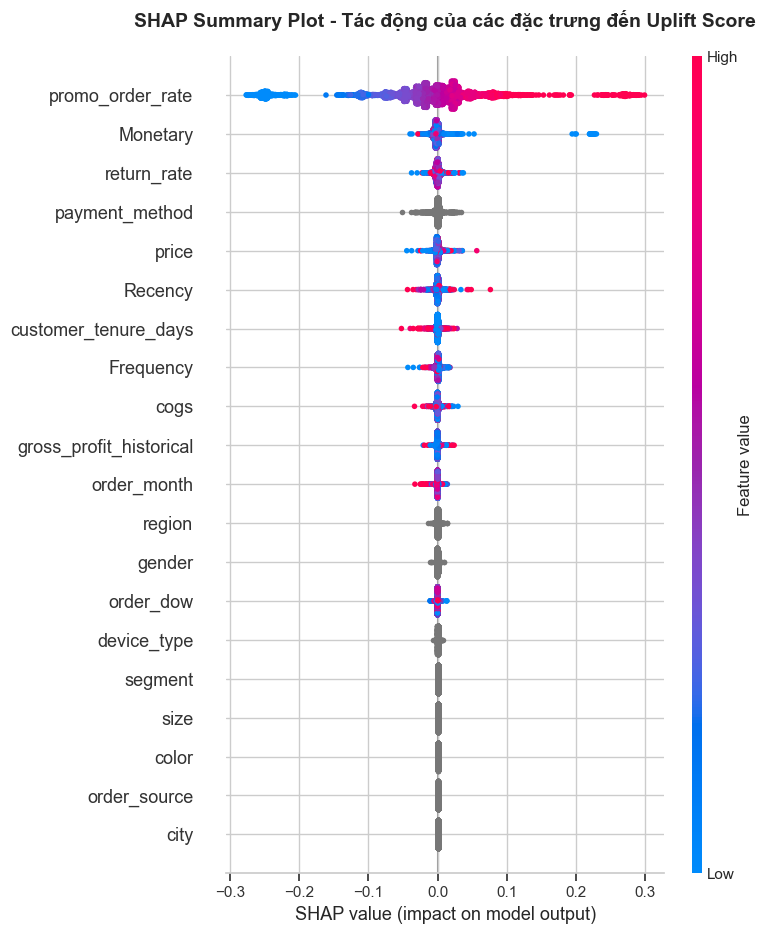

In [ ]:
import shap

# Khởi tạo XAI - SHAP
print("Tính toán SHAP values cho Uplift...")

# Để tối ưu thời gian chạy, lấy một mẫu ngẫu nhiên từ tập Test (ví dụ 5000 dòng)
X_test_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)

# Khởi tạo TreeExplainer cho cả 2 mô hình
explainer_t1 = shap.TreeExplainer(model_t1)
explainer_t0 = shap.TreeExplainer(model_t0)

# Tính toán SHAP values (tác động đến log-odds/margin)
shap_values_t1_raw = explainer_t1.shap_values(X_test_sample)
shap_values_t0_raw = explainer_t0.shap_values(X_test_sample)

# Tùy thuộc vào version LightGBM/SHAP, kết quả có thể là list [class0, class1] hoặc 1 mảng
# Ta cần lấy mảng SHAP tương ứng với class Y=1 (dự đoán mua hàng)
if isinstance(shap_values_t1_raw, list):
    shap_values_t1 = shap_values_t1_raw[1]
    shap_values_t0 = shap_values_t0_raw[1]
else:
    shap_values_t1 = shap_values_t1_raw
    shap_values_t0 = shap_values_t0_raw

# Tính Uplift SHAP values (Sự chênh lệch tác động do có khuyến mãi)
shap_values_uplift = shap_values_t1 - shap_values_t0

# Vẽ biểu đồ Summary Plot cho Uplift
plt.figure(figsize=(16, 8))
plt.title("SHAP Summary Plot - Tác động của các đặc trưng đến Uplift Score\n", fontsize=14, fontweight='bold')
# show=False để có thể tùy chỉnh thêm title
shap.summary_plot(shap_values_uplift, X_test_sample, show=False)
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - **Tầm quan trọng của đặc trưng (Feature Importance):** Biến `promo_order_rate` (tỷ lệ sử dụng khuyến mãi trong quá khứ) là đặc trưng quan trọng nhất, chi phối sự phân hóa của mô hình Uplift. Các biến tiếp theo đóng vai trò chủ chốt là `Monetary`, `return_rate`, `payment_method` và `price`. Các biến thuộc về nhân khẩu học hoặc thông tin tĩnh (`gender`, `region`, `city`, `size`, `color`) xếp cuối cùng và gần như không có tác động (các điểm tập trung thành một đường thẳng đứng tại mốc SHAP = 0).
  - **Tác động của `promo_order_rate`:** Có sự phân tách tuyến tính cực kỳ rõ ràng. Các điểm màu đỏ và tím (tỷ lệ dùng promo cao) dàn trải mạnh về phía bên phải (SHAP value dương rất lớn). Các điểm màu xanh dương (ít dùng promo) kéo dài về phía bên trái (SHAP value âm).
  - **Sự đảo ngược ở nhóm RFM (`Monetary`, `Frequency`):** Trái ngược với suy nghĩ thông thường, các điểm màu xanh dương (chi tiêu thấp, tần suất mua thấp) ở biến `Monetary` và `Frequency` lại vươn về phía có SHAP value dương. Trong khi đó, các điểm màu đỏ (khách VIP, chi tiêu nhiều) lại co cụm ở mức SHAP tiệm cận 0 hoặc hơi âm.

- **Insights:**
  - **Hành vi "Nghiện Promo" định hình tệp Persuadables:** Nhóm khách hàng có lịch sử phản ứng tốt với khuyến mãi (`promo_order_rate` cao) chính là những đối tượng "dễ bị thuyết phục" (Persuadables) nhất. Khuyến mãi (Treatment) hoạt động như một chất xúc tác hoàn hảo, tạo ra sức bật (Uplift) khổng lồ trong xác suất mua hàng của nhóm này.
  - **Nghịch lý của khách hàng VIP (Sure Things):** Nhóm khách hàng có `Monetary` hoặc `Frequency` cao là những người trung thành. Đồ thị SHAP chỉ ra rằng việc gửi promo cho họ gần như không tạo ra thêm giá trị (Uplift Score tiệm cận 0). Họ là "Sure Things" - sẽ tự nhiên mua sắm mà không cần giảm giá. Việc vung tiền cho nhóm này thực chất là hành vi "tự ăn thịt" (cannibalization), trực tiếp làm xói mòn biên lợi nhuận của doanh nghiệp.
  - **Rủi ro rò rỉ từ nhóm Sleeping Dogs:** Những người ít quan tâm đến khuyến mãi (màu xanh của `promo_order_rate`) có SHAP value âm sâu. Nếu vẫn cố nhắm mục tiêu (target) bằng cách gửi mã giảm giá, doanh nghiệp không những lãng phí chi phí tiếp thị mà còn có thể gây phiền nhiễu, kích hoạt hiệu ứng ngược khiến họ rời bỏ nền tảng.

- **Gợi ý hành động:**
  - **Tái cấu trúc bộ lọc Targeting (Stage 1):** Ứng dụng ngay insight này để lập rule loại trừ. Tự động loại bỏ tập khách hàng có `Monetary` và `Frequency` thuộc top 20% cao nhất (nhóm Sure Things), cũng như những người có `promo_order_rate` cực thấp (nhóm Sleeping Dogs) ra khỏi các chiến dịch Mass Promotion. Dồn toàn bộ hỏa lực ngân sách cho nhóm "thích săn sale nhưng chưa chi tiêu nhiều".
  - **Đa dạng hóa "Treatment" dựa trên SHAP:** Vì mô hình chỉ ra `return_rate` và `payment_method` cũng có tác động, hãy thiết kế các chiến dịch phi-giá-cả. Ví dụ: Với nhóm nhạy cảm với `return_rate` cao, thay vì tặng voucher giảm 10%, hãy chạy offer "Hoàn trả miễn phí trong 30 ngày" để kích thích mua hàng mà vẫn giữ nguyên được định giá sản phẩm (Pricing).
  - **Tích hợp Tối ưu hóa Lợi nhuận (Stage 2):** Việc tối ưu hoàn toàn theo Uplift Score hiện tại có một rủi ro tiềm ẩn: Mô hình đang "ưu ái" nhóm `Monetary` thấp. Nếu chỉ tối ưu hóa lượng đơn hàng (Conversion), tổng doanh số có thể không đạt kỳ vọng. Bắt buộc phải đưa Uplift Score đầu ra của Stage 1 này nhân với giá trị biên lợi nhuận kỳ vọng (Expected Margin/Profit) ở Stage 2 của hệ thống Causal ML. Sự kết hợp Two-Stage này sẽ tìm ra điểm cân bằng: Vừa tăng thêm đơn vị sản phẩm bán ra, vừa đảm bảo ROI của chiến dịch đạt đỉnh.

#### b. Phân tích Tương tác chéo (Dependence Plot) 

**Ý tưởng**:
Từ biểu đồ Summary Plot thực tế của mô hình, ta thấy `promo_order_rate` (tỷ lệ chốt đơn có khuyến mãi trong quá khứ) và `Monetary` (tổng giá trị mua hàng) là hai đặc trưng có sức ảnh hưởng lớn nhất đến Uplift Score. Phân tích tương tác chéo (Dependence Plot) tập trung vào hai biến top đầu này sẽ giúp ta tìm ra điểm "bùng phát" (tipping point) – ví dụ: khách hàng từng dùng promo với tần suất bao nhiêu % thì mới thực sự nhạy cảm với chiến dịch này, và họ tương tác chéo với các biến khác (như `Recency` hay `price`) ra sao.

**Phương pháp sử dụng**:
Cập nhật danh sách `features_to_plot` thành các biến quan trọng nhất từ biểu đồ thực tế (`promo_order_rate` và `Monetary`). Sử dụng hàm `shap.dependence_plot` để vẽ. Trục X sẽ là giá trị thực tế của biến đang xét, trục Y là giá trị tác động (SHAP Uplift). Tham số `interaction_index="auto"` sẽ giúp thuật toán tự động quét và tô màu các điểm dữ liệu dựa trên một biến thứ hai có mức độ tương tác chéo (interaction effect) mạnh nhất.

Đang vẽ biểu đồ Dependence Plot cho các biến quan trọng nhất...


<Figure size 1000x600 with 0 Axes>

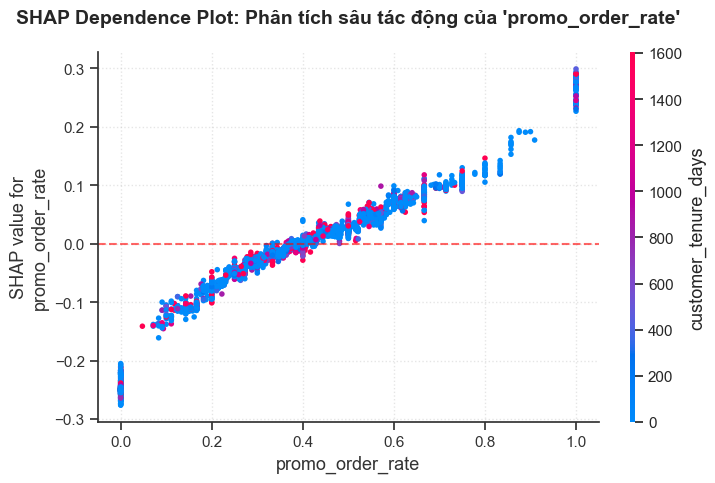

<Figure size 1000x600 with 0 Axes>

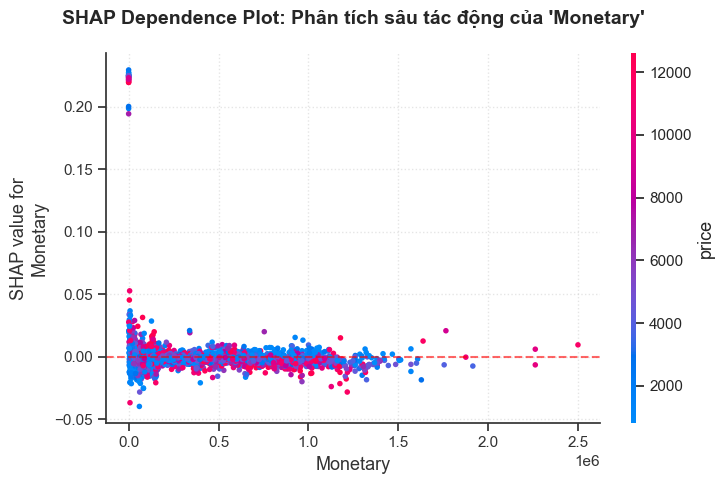

In [ ]:
# Cập nhật danh sách các biến quan trọng nhất dựa trên Summary Plot thực tế của bạn
features_to_plot = ["promo_order_rate", "Monetary"]

print("Đang vẽ biểu đồ Dependence Plot cho các biến quan trọng nhất...")

for feature in features_to_plot:
    # Kiểm tra xem biến có tồn tại trong tập mẫu không
    if feature in X_test_sample.columns:
        plt.figure(figsize=(10, 6))
        
        # Vẽ Dependence Plot
        # interaction_index="auto" sẽ tự động tìm biến có tương tác chéo mạnh nhất để tô màu
        shap.dependence_plot(
            feature, 
            shap_values_uplift, 
            X_test_sample, 
            interaction_index="auto",
            show=False # Giữ biểu đồ để tùy chỉnh thêm matplotlib phía dưới
        )
        
        # Trang trí lại biểu đồ
        plt.title(f"SHAP Dependence Plot: Phân tích sâu tác động của '{feature}'\n", fontsize=14, fontweight='bold')
        
        # Thêm đường baseline Y=0 (Ngưỡng phân chia tác động tích cực/tiêu cực lên Uplift)
        plt.axhline(0, color='red', linestyle='--', alpha=0.6, linewidth=1.5) 
        
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Lỗi: Biến '{feature}' không có trong tập dữ liệu X_test_sample.")

**Nhận xét:**

- **Quan sát:**
  - **Tác động của `promo_order_rate`:** Biểu đồ thể hiện mối tương quan đồng biến (tuyến tính) cực kỳ sắc nét. Khi tỷ lệ sử dụng khuyến mãi trong quá khứ vượt mốc ~0.35, SHAP value bắt đầu chuyển sang dương và tăng vọt lên mức 0.3 khi tỷ lệ này tiệm cận 1.0. Đáng chú ý, tại mốc 0, SHAP value giảm sâu xuống ngưỡng âm (-0.2 đến -0.3). Biến tương tác `customer_tenure_days` (màu sắc) phân bổ khá đều đặn dọc theo đường chéo, không tạo ra sự phân cụm cục bộ nào quá rạch ròi.
  - **Tác động của `Monetary`:** Có một sự tập trung bất thường tại các giá trị `Monetary` cực thấp (tiệm cận 0), nơi SHAP value bắn vọt lên mức rất cao (0.20 - 0.25). Tuy nhiên, ngay khi mức chi tiêu của khách hàng dịch chuyển sang các dải cao hơn, SHAP value lập tức rơi tự do và duy trì trạng thái đi ngang, dao động sát trục 0. Trục màu sắc biểu thị `price` cho thấy sự hội tụ ở trục 0 xảy ra bất chấp giá sản phẩm là cao (hồng/đỏ) hay thấp (xanh).
  - **Tổng quan:** Cả hai biến đều bộc lộ những điểm "cực trị" quyết định hành vi phân lớp của mô hình. Trong khi `promo_order_rate` đóng vai trò như một thang đo xu hướng tuyến tính, thì `Monetary` lại hoạt động giống một công tắc (switch) ngắt luồng tác động ngay khi vượt qua ngưỡng chi tiêu tối thiểu.

- **Insights:**
  - **Chân dung nhóm "Persuadables":** Những khách hàng có lịch sử "săn sale" (`promo_order_rate` cao) chính là đối tượng lý tưởng nhất cho các chiến dịch Uplift. Biểu đồ đầu tiên khẳng định rằng khuyến mãi là "điểm huyệt" tâm lý của nhóm này, tạo ra sức bật cực lớn trong quyết định mua hàng, và điều này đúng bất kể họ là khách hàng mới hay đã có thâm niên (tenure).
  - **Sức mạnh "đánh thức" ở tệp chi tiêu thấp:** Biểu đồ Monetary chỉ ra một insight đắt giá: Việc tung Treatment (khuyến mãi) chỉ thực sự phát huy tác dụng thay đổi hành vi đối với những người chưa từng mua hoặc mua rất ít. Sự tăng vọt của SHAP ở mức Monetary ~ 0 cho thấy khả năng "Activate" (kích hoạt) khách hàng rất tốt của chiến dịch.
  - **Hiệu ứng Cannibalization ở nhóm VIP:** Nhóm khách hàng đã chi tiêu nhiều (Monetary từ trung bình đến cao) có SHAP value tiệm cận 0, xác nhận họ là tệp "Sure Things" - những người sẽ tự nhiên mua sắm mà không cần bất kỳ chất xúc tác nào. Đổ ngân sách khuyến mãi vào nhóm này không tạo ra Incremental Volume (Sản lượng tăng thêm) mà chỉ làm giảm trực tiếp Gross Margin.

- **Gợi ý hành động:**
  - **Tạo Rule "Cắt phễu" (Targeting Criteria):** Xây dựng ngay một tập đối tượng mục tiêu (Target Audience) giao thoa: Lọc ra những khách hàng có `promo_order_rate` > 0.35 VÀ `Monetary` đang ở mức thấp. Đây là "vùng vàng" chứa những khách hàng nhạy cảm với giá và chưa gắn bó tài chính sâu sắc, nơi ROI của mỗi đồng voucher bỏ ra sẽ đạt mức cao nhất.
  - **Áp dụng chiến lược "Loại trừ chủ động" (Negative Targeting):** Đưa toàn bộ nhóm "Sleeping Dogs" (`promo_order_rate` = 0, SHAP âm sâu) và nhóm "Sure Things" (`Monetary` cao, SHAP = 0) vào danh sách Blacklist của chiến dịch Mass Promotion. Việc không gửi tin nhắn/voucher cho nhóm này vừa tiết kiệm ngân sách, vừa tránh làm phiền (giảm nguy cơ Churn do spam).
  - **Kết nối vào Stage 2 (Tối ưu hóa lợi nhuận ròng):** Mặc dù tập `Monetary` thấp mang lại Uplift Score cao nhất, nhưng vì giá trị giỏ hàng lịch sử của họ vốn nhỏ, nếu giảm giá quá đà có thể dẫn đến lỗ chi phí vận hành (CAC/Logistics). Cần đưa ngay kết quả xác suất này vào phương trình $E[\text{Profit}]$ ở Stage 2 của hệ thống Causal ML. Mô hình Stage 2 sẽ giúp hiệu chỉnh lại tỷ lệ Discount phù hợp để đảm bảo mỗi đơn hàng tăng thêm từ nhóm này đều mang về lợi nhuận gộp dương.

# 5. Phân tích revenue và cost theo từng segment

Revenue được biểu diễn theo công thức:

$$
Revenue = unit\_price \times quantity
$$

Mỗi target đều đi theo trình tự: kiểm định giả thuyết, preprocessing, feature engineering/feature selection bằng Mutual Information, RFE, SHAP, modeling regression/tree-based, giải thích model, và mô phỏng counterfactual để rút ra quyết định tối ưu cho từng segment.

## 5.1. Chuẩn bị bảng modeling profit theo segment

In [ ]:
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
shipments = pd.read_csv(DATA_DIR / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

segment_lookup = rfm[["customer_id", "customer_segment"]].drop_duplicates()

model_base = (
    order_items.copy()
    .merge(
        orders[["order_id", "order_date", "customer_id", "order_status", "order_source", "device_type", "payment_method"]],
        on="order_id",
        how="left",
    )
    .merge(segment_lookup, on="customer_id", how="left")
    .merge(customers[["customer_id", "age_group"]], on="customer_id", how="left")
    .merge(products[["product_id", "price", "cogs", "category", "segment"]], on="product_id", how="left")
)
model_base = model_base.dropna(subset=["customer_segment"]).copy()

# Promotions: giữ cả promo_id và promo_id_2, đồng thời lấy metadata của promotion.
promo_ref = promotions[[
    "promo_id", "promo_type", "discount_value", "stackable_flag", "applicable_category", "min_order_value"
]].copy()
promo_ref["promo_id_key"] = promo_ref["promo_id"].astype("string")

for source_col, prefix in [("promo_id", "primary"), ("promo_id_2", "secondary")]:
    model_base[source_col] = model_base[source_col].astype("string")
    promo_tmp = promo_ref.rename(columns={
        "promo_id": f"promo_id_{prefix}_ref",
        "promo_type": f"promo_type_{prefix}",
        "discount_value": f"discount_value_{prefix}",
        "stackable_flag": f"stackable_flag_{prefix}",
        "applicable_category": f"applicable_category_{prefix}",
        "min_order_value": f"min_order_value_{prefix}",
    })
    model_base = model_base.merge(
        promo_tmp,
        left_on=source_col,
        right_on="promo_id_key",
        how="left",
    ).drop(columns=["promo_id_key", f"promo_id_{prefix}_ref"])

discount_cols = ["discount_value_primary", "discount_value_secondary"]
min_order_cols = ["min_order_value_primary", "min_order_value_secondary"]
stackable_cols = ["stackable_flag_primary", "stackable_flag_secondary"]
model_base["has_promo"] = model_base[["promo_id", "promo_id_2"]].notna().any(axis=1).astype(int)
model_base["discount_value_max"] = model_base[discount_cols].max(axis=1).fillna(0)
model_base["min_order_value_max"] = model_base[min_order_cols].max(axis=1).fillna(0)
model_base["stackable_any"] = model_base[stackable_cols].max(axis=1).fillna(0)

# Inventory join theo product_id + tháng của order.
model_base["year"] = model_base["order_date"].dt.year
model_base["month"] = model_base["order_date"].dt.month
model_base["order_dayofweek"] = model_base["order_date"].dt.dayofweek
inventory_month = (
    inventory.groupby(["product_id", "year", "month"], as_index=False)
    .agg(
        stock_on_hand=("stock_on_hand", "mean"),
        stockout_flag=("stockout_flag", "max"),
        stockout_days=("stockout_days", "mean"),
        units_received=("units_received", "sum"),
        units_sold=("units_sold", "sum"),
        overstock_flag=("overstock_flag", "max"),
    )
)
model_base = model_base.merge(inventory_month, on=["product_id", "year", "month"], how="left")

# Web traffic join theo ngày order và nguồn traffic/order_source.
web_daily = (
    web_traffic.groupby(["date", "traffic_source"], as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        bounce_rate=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
    )
)
model_base["order_date_only"] = model_base["order_date"].dt.normalize()
model_base = model_base.merge(
    web_daily,
    left_on=["order_date_only", "order_source"],
    right_on=["date", "traffic_source"],
    how="left",
).drop(columns=["date"])

# Returns và shipments cho cost model.
returns_agg = (
    returns.groupby(["order_id", "product_id"], as_index=False)
    .agg(return_quantity=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
)
shipments_agg = shipments.groupby("order_id", as_index=False).agg(shipping_fee=("shipping_fee", "sum"))
model_base = model_base.merge(returns_agg, on=["order_id", "product_id"], how="left")
model_base = model_base.merge(shipments_agg, on="order_id", how="left")
model_base[["return_quantity", "refund_amount", "shipping_fee"]] = model_base[[
    "return_quantity", "refund_amount", "shipping_fee"
]].fillna(0)

model_base["revenue"] = model_base["unit_price"] * model_base["quantity"]
order_gross = model_base.groupby("order_id")["revenue"].transform("sum").replace(0, np.nan)
model_base["shipping_fee_allocated"] = (model_base["shipping_fee"] * model_base["revenue"] / order_gross).fillna(0)
model_base["product_cogs_cost"] = model_base["cogs"] * model_base["quantity"]
model_base["return_cogs_cost"] = model_base["cogs"] * model_base["return_quantity"]
model_base["cost"] = model_base["product_cogs_cost"] + model_base["shipping_fee_allocated"] + model_base["return_cogs_cost"]

modeling_overview = (
    model_base.groupby("customer_segment")
    .agg(
        rows=("order_id", "size"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        avg_unit_price=("unit_price", "mean"),
        avg_quantity=("quantity", "mean"),
    )
    .reset_index()
)
modeling_overview["profit_proxy"] = modeling_overview["revenue"] - modeling_overview["cost"]
display(modeling_overview.style.format({
    "rows": "{:,.0f}",
    "orders": "{:,.0f}",
    "revenue": "{:,.0f}",
    "cost": "{:,.0f}",
    "avg_unit_price": "{:,.2f}",
    "avg_quantity": "{:,.2f}",
    "profit_proxy": "{:,.0f}",
}))

,customer_segment,rows,orders,revenue,cost,avg_unit_price,avg_quantity,profit_proxy
0,At Risk / Churn,"229,515","209,117","5,384,552,440","4,789,192,388","5,176.56",4.52,"595,360,053"
1,Bargain Hunters,"28,425","25,298","332,697,054","308,067,366","3,455.88",3.84,"24,629,688"
2,Champions,"317,665","285,269","7,414,879,860","6,586,038,405","5,168.52",4.51,"828,841,455"
3,Hibernating / Low Engagement,"85,238","77,844","2,050,118,555","1,818,581,474","5,216.86",4.61,"231,537,080"
4,Loyal Customers,"47,420","43,597","1,103,035,845","993,387,634","5,276.29",4.45,"109,648,212"


**Nhận xét:**

**Quan sát**

- **Cơ cấu doanh thu và khách hàng**

    - Champions là nhóm khách hàng quan trọng nhất, chiếm tỷ trọng cao nhất cả về số lượng (hơn 317k rows) và doanh thu (7.4 tỷ). Hiệu quả kinh doanh phụ thuộc rất lớn vào việc duy trì nhóm này.

    - At Risk / Churn: Nhóm có nguy cơ rời bỏ đang chiếm số lượng cực lớn (229,515 khách hàng). Doanh thu từ nhóm này đạt hơn 5.3 tỷ. Nếu không có chiến dịch cứu vãn kịp thời, doanh nghiệp sẽ mất đi một nguồn thu khổng lồ.

- **Phân tích giá trị đơn hàng (Average Unit Price & Quantity)**

    - Bargain Hunters: Nhóm Săn sale có mức giá trung bình đơn vị thấp nhất (3,455) và số lượng mua mỗi lần cũng thấp nhất (3.84). Điều này cho thấy họ chỉ tập trung vào các sản phẩm giá rẻ hoặc có khuyến mãi sâu.

    - Nhóm Loyal Customers và Hibernating đang trả mức giá trung bình cao nhất (trên 5,200). Điều này gợi ý rằng khách hàng trung thành không phải vì giá rẻ mà vì giá trị thương hiệu hoặc chất lượng sản phẩm.

- **Hiệu quả lợi nhuận (Profit Proxy)**

    - Tỷ suất lợi nhuận/doanh thu nhìn chung khá đồng đều giữa các nhóm (dao động quanh mức 11-12%).

    - Tuy nhiên, nhóm Hibernating (Ngủ đông) đang giữ mức giá trung bình cao và số lượng mua trung bình cao nhất (4.61). Đây là nhóm "tiềm năng bị bỏ quên" – họ từng sẵn sàng chi đậm nhưng hiện đang thiếu sự tương tác.


**Đề xuất hành động**

- Đối với Champions: Triển khai chương trình tri ân đặc quyền để giữ chân và biến họ thành đại sứ thương hiệu.

- Đối với At Risk / Churn: Cần thực hiện khảo sát hoặc gửi các mã giảm giá "nhớ bạn" ngay lập tức để tìm hiểu lý do họ rời đi và kéo họ quay lại.

- Đối với Hibernating: Sử dụng các chiến dịch Marketing Automation (Email/SMS) nhắc nhớ về sản phẩm mới dựa trên lịch sử mua hàng có giá trị cao trước đó của họ.

- Đối với Bargain Hunters: Chỉ nên tiếp cận khi có các chương trình xả kho hoặc chiến dịch đẩy doanh số cuối mùa, tránh lãng phí chi phí marketing cao cấp vào nhóm này.



## 5.2. Hàm kiểm định giả thuyết, modeling pipeline, SHAP/feature importance và counterfactual

In [ ]:
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
import shap

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None
try:
    from catboost import CatBoostRegressor
except Exception:
    CatBoostRegressor = None

try:
    _ = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    def make_ohe():
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    def make_ohe():
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

MAX_ROWS_PER_MODEL = 300
TOP_K_FEATURES = 8
CV_SPLITS = 2
MIN_ROWS_PER_MODEL = 120

In [ ]:
def regression_metric_dict(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(0, np.expm1(y_pred_log))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }

def test_numeric_relation(df, feature, target):
    tmp = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < 30 or tmp[feature].nunique() < 2:
        return None
    stat, p_value = stats.spearmanr(tmp[feature], tmp[target])
    return {
        "feature": feature,
        "test": "Spearman correlation",
        "statistic": stat,
        "p_value": p_value,
        "n": len(tmp),
        "effect_note": f"rho={stat:.3f}",
    }

def test_binary_relation(df, feature, target):
    tmp = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < 30 or tmp[feature].nunique() != 2:
        return None
    values = sorted(tmp[feature].unique())
    g0 = tmp.loc[tmp[feature].eq(values[0]), target]
    g1 = tmp.loc[tmp[feature].eq(values[1]), target]
    if len(g0) < 10 or len(g1) < 10:
        return None
    stat, p_value = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    median_diff = g1.median() - g0.median()
    return {
        "feature": feature,
        "test": "Mann-Whitney U",
        "statistic": stat,
        "p_value": p_value,
        "n": len(tmp),
        "effect_note": f"median_diff({values[1]}-{values[0]})={median_diff:,.3f}",
    }

def test_categorical_relation(df, feature, target):
    tmp = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < 30:
        return None
    counts = tmp[feature].value_counts()
    valid_levels = counts[counts >= 10].index
    tmp = tmp[tmp[feature].isin(valid_levels)]
    if tmp[feature].nunique() < 2 or tmp[feature].nunique() > 30:
        return None
    groups = [g[target].values for _, g in tmp.groupby(feature)]
    stat, p_value = stats.kruskal(*groups)
    return {
        "feature": feature,
        "test": "Kruskal-Wallis",
        "statistic": stat,
        "p_value": p_value,
        "n": len(tmp),
        "effect_note": f"groups={tmp[feature].nunique()}",
    }

def run_hypothesis_tests(df, target, config):
    records = []
    for feature, feature_type in config["hypothesis_features"]:
        if feature not in df.columns:
            continue
        if feature_type == "numeric":
            out = test_numeric_relation(df, feature, target)
        elif feature_type == "binary":
            out = test_binary_relation(df, feature, target)
        else:
            out = test_categorical_relation(df, feature, target)
        if out is not None:
            records.append(out)
    return pd.DataFrame(records)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())]), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )
    return preprocessor, numeric_cols, categorical_cols

def preprocess_and_select_features(X_train, X_test, y_train_log):
    X_train = X_train.copy().replace({pd.NA: np.nan})
    X_test = X_test.copy().replace({pd.NA: np.nan})
    for _col in X_train.select_dtypes(include=["object", "string", "category"]).columns:
        X_train[_col] = X_train[_col].astype(object)
        X_test[_col] = X_test[_col].astype(object)
        X_train[_col] = X_train[_col].where(X_train[_col].notna(), "__missing__")
        X_test[_col] = X_test[_col].where(X_test[_col].notna(), "__missing__")
    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train)
    X_train_arr = preprocessor.fit_transform(X_train)
    X_test_arr = preprocessor.transform(X_test)
    feature_names = preprocessor.get_feature_names_out()
    X_train_fe = pd.DataFrame(X_train_arr, columns=feature_names, index=X_train.index)
    X_test_fe = pd.DataFrame(X_test_arr, columns=feature_names, index=X_test.index)

    vt = VarianceThreshold(threshold=0.0)
    X_train_vt_arr = vt.fit_transform(X_train_fe)
    X_test_vt_arr = vt.transform(X_test_fe)
    kept_features = X_train_fe.columns[vt.get_support()].tolist()
    dropped_features = X_train_fe.columns[~vt.get_support()].tolist()
    X_train_vt = pd.DataFrame(X_train_vt_arr, columns=kept_features, index=X_train.index)
    X_test_vt = pd.DataFrame(X_test_vt_arr, columns=kept_features, index=X_test.index)

    mi_scores = mutual_info_regression(X_train_vt, y_train_log, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi_scores, index=X_train_vt.columns).sort_values(ascending=False)

    k_features = min(TOP_K_FEATURES, X_train_vt.shape[1])
    if X_train_vt.shape[1] <= k_features:
        rfe_features = X_train_vt.columns.tolist()
        rfe_rank = pd.DataFrame({"feature": X_train_vt.columns, "rank": 1})
    else:
        rfe_estimator = RandomForestRegressor(
            n_estimators=8, max_depth=4, random_state=RANDOM_STATE, n_jobs=1
        )
        rfe = RFE(estimator=rfe_estimator, n_features_to_select=k_features, step=0.25)
        rfe.fit(X_train_vt, y_train_log)
        rfe_features = X_train_vt.columns[rfe.support_].tolist()
        rfe_rank = pd.DataFrame({"feature": X_train_vt.columns, "rank": rfe.ranking_}).sort_values("rank")

    shap_status = "SHAP"
    try:
        shap_model = RandomForestRegressor(
            n_estimators=10, max_depth=5, random_state=RANDOM_STATE, n_jobs=1
        )
        shap_model.fit(X_train_vt, y_train_log)
        shap_sample = X_train_vt.sample(min(50, len(X_train_vt)), random_state=RANDOM_STATE)
        shap_values = shap.TreeExplainer(shap_model).shap_values(shap_sample)
        shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_vt.columns).sort_values(ascending=False)
    except Exception as exc:
        shap_status = f"feature_importances fallback ({exc.__class__.__name__})"
        shap_model = RandomForestRegressor(
            n_estimators=10, max_depth=5, random_state=RANDOM_STATE, n_jobs=1
        )
        shap_model.fit(X_train_vt, y_train_log)
        shap_importance = pd.Series(shap_model.feature_importances_, index=X_train_vt.columns).sort_values(ascending=False)

    selected_features = []
    for feature in list(mi_series.head(TOP_K_FEATURES).index) + rfe_features + list(shap_importance.head(TOP_K_FEATURES).index):
        if feature not in selected_features:
            selected_features.append(feature)
    selected_features = selected_features[: max(TOP_K_FEATURES, min(20, len(selected_features)))]

    return {
        "preprocessor": preprocessor,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "kept_features": kept_features,
        "dropped_features": dropped_features,
        "X_train_vt": X_train_vt,
        "X_test_vt": X_test_vt,
        "X_train_final": X_train_vt[selected_features],
        "X_test_final": X_test_vt[selected_features],
        "selected_features": selected_features,
        "mi_series": mi_series,
        "rfe_rank": rfe_rank,
        "shap_importance": shap_importance,
        "shap_status": shap_status,
    }

def make_model_specs():
    specs = {
        "Linear Regression": (LinearRegression(), {}),
        "Ridge": (Ridge(random_state=RANDOM_STATE), {"alpha": [0.1, 1.0, 10.0]}),
        "Lasso": (Lasso(random_state=RANDOM_STATE, max_iter=5000), {"alpha": [0.0005, 0.001, 0.01]}),
        "Random Forest": (
            RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
            {"n_estimators": [12], "max_depth": [4], "min_samples_leaf": [2]},
        ),
    }
    if XGBRegressor is not None:
        specs["XGBoost"] = (
            XGBRegressor(
                objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=1,
                tree_method="hist", verbosity=0
            ),
            {"n_estimators": [12], "max_depth": [3], "learning_rate": [0.05]},
        )
    if LGBMRegressor is not None:
        specs["LightGBM"] = (
            LGBMRegressor(objective="regression", random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
            {"n_estimators": [12], "max_depth": [4], "learning_rate": [0.05]},
        )
    if CatBoostRegressor is not None:
        specs["CatBoost"] = (
            CatBoostRegressor(
                loss_function="RMSE", random_seed=RANDOM_STATE, verbose=False,
                allow_writing_files=False, thread_count=1
            ),
            {"iterations": [12], "depth": [4], "learning_rate": [0.05]},
        )
    return specs

def fit_and_compare_models(X_train_final, X_test_final, y_train_log, y_test_log):
    cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    fitted_models = {}

    for name, (estimator, grid) in make_model_specs().items():
        try:
            if grid:
                search = GridSearchCV(
                    estimator,
                    grid,
                    scoring="neg_root_mean_squared_error",
                    cv=cv,
                    n_jobs=1,
                    error_score=np.nan,
                )
                search.fit(X_train_final, y_train_log)
                model = search.best_estimator_
                cv_rmse_log = -search.best_score_
                best_params = search.best_params_
            else:
                model = estimator.fit(X_train_final, y_train_log)
                cv_scores = []
                for train_idx, valid_idx in cv.split(X_train_final):
                    fold_model = LinearRegression()
                    fold_model.fit(X_train_final.iloc[train_idx], y_train_log.iloc[train_idx])
                    pred = fold_model.predict(X_train_final.iloc[valid_idx])
                    cv_scores.append(np.sqrt(mean_squared_error(y_train_log.iloc[valid_idx], pred)))
                cv_rmse_log = float(np.mean(cv_scores))
                best_params = {}

            y_pred_log = model.predict(X_test_final)
            metrics = regression_metric_dict(y_test_log, y_pred_log)
            rows.append({
                "model": name,
                "cv_rmse_log": cv_rmse_log,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "best_params": best_params,
            })
            fitted_models[name] = model
        except Exception as exc:
            rows.append({
                "model": name,
                "cv_rmse_log": np.nan,
                "MAE": np.nan,
                "RMSE": np.nan,
                "R2": np.nan,
                "best_params": {"error": f"{exc.__class__.__name__}: {exc}"},
            })

    result_df = pd.DataFrame(rows).sort_values(["R2", "RMSE"], ascending=[False, True])
    best_model_name = result_df.dropna(subset=["R2"]).iloc[0]["model"]
    return result_df, fitted_models[best_model_name], best_model_name

def fit_ols_diagnostic(X_train_final, X_test_final, y_train_log, y_test_log):
    try:
        X_train_sm = sm.add_constant(X_train_final, has_constant="add")
        X_test_sm = sm.add_constant(X_test_final, has_constant="add")
        ols = sm.OLS(y_train_log, X_train_sm).fit()
        pred_test = ols.predict(X_test_sm)
        metrics = regression_metric_dict(y_test_log, pred_test)
        jb_stat, jb_p, skew, kurtosis = jarque_bera(ols.resid)
        return {
            "ols_r2_train_log": ols.rsquared,
            "ols_test_r2": metrics["R2"],
            "ols_test_rmse": metrics["RMSE"],
            "condition_number": ols.condition_number,
            "jb_p_value": jb_p,
        }
    except Exception as exc:
        return {"ols_error": f"{exc.__class__.__name__}: {exc}"}

def predict_from_raw(raw_X, feature_pack, selected_model):
    raw_X = raw_X.copy().replace({pd.NA: np.nan})
    for _col in feature_pack.get("categorical_cols", []):
        if _col in raw_X.columns:
            raw_X[_col] = raw_X[_col].astype(object)
            raw_X[_col] = raw_X[_col].where(raw_X[_col].notna(), "__missing__")
    arr = feature_pack["preprocessor"].transform(raw_X)
    feature_names = feature_pack["preprocessor"].get_feature_names_out()
    transformed = pd.DataFrame(arr, columns=feature_names, index=raw_X.index)
    transformed = transformed.reindex(columns=feature_pack["kept_features"], fill_value=0)
    transformed = transformed[feature_pack["selected_features"]]
    return np.maximum(0, np.expm1(selected_model.predict(transformed)))

def run_counterfactuals(raw_X_test, baseline_pred, feature_pack, selected_model, actions):
    records = []
    baseline_mean = float(np.mean(baseline_pred))
    if baseline_mean <= 0:
        return pd.DataFrame(records)

    for action in actions:
        feature = action["feature"]
        if feature not in raw_X_test.columns:
            continue
        modified = raw_X_test.copy()
        if action["type"] == "pct":
            modified[feature] = modified[feature].fillna(modified[feature].median())
            modified[feature] = modified[feature] * (1 + action["value"])
        elif action["type"] == "set":
            modified[feature] = action["value"]
        elif action["type"] == "clip_pct":
            modified[feature] = modified[feature].fillna(modified[feature].median())
            modified[feature] = (modified[feature] * (1 + action["value"])).clip(lower=action.get("lower", 0), upper=action.get("upper", np.inf))
        pred = predict_from_raw(modified, feature_pack, selected_model)
        new_mean = float(np.mean(pred))
        records.append({
            "action": action["label"],
            "feature": feature,
            "baseline_pred_mean": baseline_mean,
            "counterfactual_pred_mean": new_mean,
            "pred_change_pct": (new_mean / baseline_mean - 1) * 100,
            "business_direction": action.get("direction", "increase"),
        })
    return pd.DataFrame(records).sort_values("pred_change_pct", ascending=False)

def render_hypothesis_markdown(segment_name, target_label, config, tests_df):
    text = [
        f"#### Giả thuyết: Các biến trong bảng liên kết có ảnh hưởng đến `{target_label}` của segment **{segment_name}**",
        "",
        "**Biến sử dụng:**",
    ]
    for feature, feature_type in config["hypothesis_features"]:
        text.append(f"- `{feature}`: biến {feature_type}")
    text += [
        "",
        "**Kiểm định thống kê:**",
        "",
        "- Giả thuyết ($H_0$): Feature không tạo khác biệt/correlation có ý nghĩa thống kê với target.",
        "- Giả thuyết ($H_1$): Feature có tạo khác biệt/correlation có ý nghĩa thống kê với target.",
    ]
    display(Markdown("\n".join(text)))
    if len(tests_df):
        display(tests_df.style.format({"statistic": "{:,.4f}", "p_value": "{:.4g}", "n": "{:,.0f}"}))
    else:
        display(Markdown("_Không đủ nhóm/dữ liệu để chạy kiểm định ổn định cho target này._"))

def insight_markdown(segment_name, target_label, config, sample_rows, missing_rate, tests_df, feature_pack, model_results, best_model_name, ols_diag, cf_df):
    significant = tests_df.loc[tests_df["p_value"] < 0.05, "feature"].tolist() if len(tests_df) else []
    top_mi = feature_pack["mi_series"].head(5).index.tolist()
    top_shap = feature_pack["shap_importance"].head(5).index.tolist()
    best_row = model_results.iloc[0]
    linear_row = model_results.loc[model_results["model"].eq("Linear Regression")]
    linear_r2 = linear_row["R2"].iloc[0] if len(linear_row) else np.nan
    top_action = "Chưa có action counterfactual đủ điều kiện."
    if len(cf_df):
        if config["objective"] == "minimize":
            action_df = cf_df.sort_values("pred_change_pct", ascending=True)
        else:
            action_df = cf_df.sort_values("pred_change_pct", ascending=False)
        action = action_df.iloc[0]
        top_action = f"{action['action']} → thay đổi dự đoán trung bình khoảng {action['pred_change_pct']:.2f}%"

    text = f'''
**Nhận xét:**

- **Quan sát:**
  - **Dữ liệu model:** Segment **{segment_name}** với target `{target_label}` dùng {sample_rows:,.0f} dòng sau khi cleaning/sampling; tỷ lệ missing trung bình của các feature là {missing_rate:.2%}.
  - **Kiểm định giả thuyết:** Các biến có p-value < 0.05 gồm: {', '.join(significant[:6]) if significant else 'chưa có biến nổi bật theo kiểm định hiện tại'}.
  - **Feature engineering:** Variance Threshold loại {len(feature_pack['dropped_features']):,.0f} feature hằng số; top Mutual Information gồm {', '.join(top_mi)}.
  - **SHAP/Feature importance:** Top feature theo {feature_pack['shap_status']} gồm {', '.join(top_shap)}.
  - **Modeling:** Best model là **{best_model_name}** với R² test = {best_row['R2']:.3f}, RMSE = {best_row['RMSE']:,.2f}. Linear Regression có R² test = {linear_r2:.3f}. OLS diagnostic: {ols_diag}.

- **Insights:**
  - **Quan hệ phi tuyến:** Nếu best model là tree-based và vượt Linear Regression, quan hệ giữa feature và `{target_label}` không nên được đọc bằng hệ số tuyến tính đơn thuần.
  - **Feature trọng yếu:** Nhóm feature xuất hiện đồng thời trong MI/SHAP nên được ưu tiên khi ra quyết định cho segment này.
  - **Kiểm định vs model:** Kiểm định thống kê giúp xác nhận quan hệ đơn biến; model đa biến cho biết feature nào còn quan trọng sau khi kiểm soát các biến còn lại.

- **Gợi ý hành động:**
  - **Counterfactual thực tế:** {top_action}.
  - **Quyết định:** Ưu tiên action trên nếu phù hợp tồn kho, biên lợi nhuận và chính sách promotion của segment **{segment_name}**.
  - **Theo dõi:** Sau khi triển khai, đo lại `{target_label}` bằng A/B test hoặc holdout để tránh nhầm lẫn giữa correlation và tác động nhân quả thật.
'''
    display(Markdown(text))

def run_segment_target_pipeline(segment_name, config):
    target = config["target"]
    features = [feature for feature in config["features"] if feature in model_base.columns]
    df = model_base.loc[model_base["customer_segment"].eq(segment_name), features + [target]].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])
    df = df.loc[df[target] >= 0].copy()
    if len(df) < MIN_ROWS_PER_MODEL:
        display(Markdown(f"_Segment {segment_name}, target {target}: không đủ dữ liệu để chạy model._"))
        return None

    if len(df) > MAX_ROWS_PER_MODEL:
        df = df.sample(MAX_ROWS_PER_MODEL, random_state=RANDOM_STATE)

    missing_rate = df[features].isna().mean().mean()
    tests_df = run_hypothesis_tests(df, target, config)
    render_hypothesis_markdown(segment_name, target, config, tests_df)

    X = df[features].copy()
    y_log = np.log1p(df[target].astype(float))
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=RANDOM_STATE
    )

    feature_pack = preprocess_and_select_features(X_train, X_test, y_train_log)
    model_results, best_model, best_model_name = fit_and_compare_models(
        feature_pack["X_train_final"], feature_pack["X_test_final"], y_train_log, y_test_log
    )
    ols_diag = fit_ols_diagnostic(
        feature_pack["X_train_final"], feature_pack["X_test_final"], y_train_log, y_test_log
    )

    baseline_pred = predict_from_raw(X_test, feature_pack, best_model)
    cf_df = run_counterfactuals(X_test, baseline_pred, feature_pack, best_model, config["counterfactual_actions"])

    display(Markdown("**2.1 Data preprocessing & 2.2 Feature engineering / selection**"))
    feature_summary = pd.DataFrame({
        "method": ["Mutual Information", "RFE", feature_pack["shap_status"]],
        "top_features": [
            ", ".join(feature_pack["mi_series"].head(8).index),
            ", ".join(feature_pack["rfe_rank"].head(8)["feature"]),
            ", ".join(feature_pack["shap_importance"].head(8).index),
        ],
    })
    display(feature_summary)

    display(Markdown("**2.3 Regression, 2.4 Tree-based models & tuning**"))
    display(model_results.style.format({
        "cv_rmse_log": "{:.4f}", "MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"
    }))

    display(Markdown("**2.5 SHAP/Feature importance và 3. Counterfactual**"))
    display(feature_pack["shap_importance"].head(10).rename("importance").reset_index().rename(columns={"index": "feature"}).style.format({"importance": "{:,.5f}"}))
    if len(cf_df):
        display(cf_df.style.format({
            "baseline_pred_mean": "{:,.2f}",
            "counterfactual_pred_mean": "{:,.2f}",
            "pred_change_pct": "{:.2f}%",
        }))
    else:
        display(Markdown("_Không có counterfactual hợp lệ cho target này._"))

    insight_markdown(
        segment_name, target, config, len(df), missing_rate, tests_df,
        feature_pack, model_results, best_model_name, ols_diag, cf_df
    )

    return {
        "segment": segment_name,
        "target": target,
        "rows": len(df),
        "missing_rate": missing_rate,
        "best_model": best_model_name,
        "best_r2": model_results.iloc[0]["R2"],
        "best_rmse": model_results.iloc[0]["RMSE"],
        "top_mi": ", ".join(feature_pack["mi_series"].head(5).index),
        "top_shap": ", ".join(feature_pack["shap_importance"].head(5).index),
        "best_counterfactual": (
            cf_df.sort_values("pred_change_pct", ascending=(config["objective"] == "minimize")).iloc[0]["action"]
            if len(cf_df) else None
        ),
    }

In [ ]:

TARGET_MODEL_CONFIGS = {
    "unit_price": {
        "title": "#### a. Phân tích unit_price",
        "target": "unit_price",
        "objective": "increase",
        "features": [
            "price",
            "promo_id", "promo_id_2",
            "promo_type_primary", "promo_type_secondary",
            "discount_value_primary", "discount_value_secondary", "discount_value_max",
            "stackable_flag_primary", "stackable_flag_secondary", "stackable_any",
            "applicable_category_primary", "applicable_category_secondary",
            "min_order_value_primary", "min_order_value_secondary", "min_order_value_max",
            "has_promo",
        ],
        "hypothesis_features": [
            ("price", "numeric"),
            ("has_promo", "binary"),
            ("discount_value_max", "numeric"),
            ("promo_type_primary", "categorical"),
            ("stackable_any", "binary"),
        ],
        "counterfactual_actions": [
            {"feature": "price", "type": "pct", "value": 0.05, "label": "Tăng price 5% trong biên test", "direction": "increase"},
            {"feature": "discount_value_max", "type": "clip_pct", "value": 0.10, "lower": 0, "upper": 60, "label": "Tăng discount_value tối đa 10% nhưng cap 60", "direction": "increase"},
            {"feature": "min_order_value_max", "type": "pct", "value": 0.10, "label": "Tăng min_order_value 10%", "direction": "increase"},
            {"feature": "stackable_any", "type": "set", "value": 1, "label": "Cho phép promotion stackable", "direction": "increase"},
        ],
    },
    "quantity": {
        "title": "#### b. Phân tích quantity",
        "target": "quantity",
        "objective": "increase",
        "features": [
            "stock_on_hand", "stockout_flag", "stockout_days",
            "min_order_value_max", "discount_value_max", "promo_type_primary", "promo_type_secondary", "stackable_any",
            "price", "category", "segment", "age_group", "order_source", "traffic_source",
            "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec",
        ],
        "hypothesis_features": [
            ("stockout_flag", "binary"),
            ("stockout_days", "numeric"),
            ("discount_value_max", "numeric"),
            ("order_source", "categorical"),
            ("traffic_source", "categorical"),
            ("age_group", "categorical"),
        ],
        "counterfactual_actions": [
            {"feature": "stockout_flag", "type": "set", "value": 0, "label": "Loại bỏ stockout_flag", "direction": "increase"},
            {"feature": "stockout_days", "type": "clip_pct", "value": -0.20, "lower": 0, "label": "Giảm stockout_days 20%", "direction": "increase"},
            {"feature": "stock_on_hand", "type": "pct", "value": 0.10, "label": "Tăng stock_on_hand 10%", "direction": "increase"},
            {"feature": "discount_value_max", "type": "clip_pct", "value": 0.10, "lower": 0, "upper": 60, "label": "Tăng discount_value tối đa 10% nhưng cap 60", "direction": "increase"},
            {"feature": "page_views", "type": "pct", "value": 0.10, "label": "Tăng page_views 10% từ traffic hiện có", "direction": "increase"},
        ],
    },
    "cost": {
        "title": "### 1.2. Phân tích Cost",
        "target": "cost",
        "objective": "minimize",
        "features": [
            "cogs", "quantity", "return_quantity", "order_status", "order_date", "year", "month", "order_dayofweek",
            "units_received", "units_sold", "stock_on_hand", "overstock_flag",
            "shipping_fee", "shipping_fee_allocated",
        ],
        "hypothesis_features": [
            ("cogs", "numeric"),
            ("quantity", "numeric"),
            ("return_quantity", "numeric"),
            ("order_status", "categorical"),
            ("overstock_flag", "binary"),
            ("shipping_fee_allocated", "numeric"),
        ],
        "counterfactual_actions": [
            {"feature": "cogs", "type": "pct", "value": -0.05, "label": "Giảm cogs 5% qua đàm phán/nguồn hàng", "direction": "decrease"},
            {"feature": "return_quantity", "type": "clip_pct", "value": -0.20, "lower": 0, "label": "Giảm return_quantity 20%", "direction": "decrease"},
            {"feature": "shipping_fee_allocated", "type": "pct", "value": -0.10, "label": "Giảm shipping_fee_allocated 10%", "direction": "decrease"},
            {"feature": "overstock_flag", "type": "set", "value": 0, "label": "Loại bỏ overstock_flag", "direction": "decrease"},
        ],
    },
}

# order_date chỉ phục vụ diễn giải, model dùng các biến year/month/order_dayofweek.
TARGET_MODEL_CONFIGS["cost"]["features"] = [
    feature for feature in TARGET_MODEL_CONFIGS["cost"]["features"] if feature != "order_date"
]

## 5.3. Phân tích từng segment

- **Phân tích Revenue**
  - **a. Phân tích `unit_price`**
  - **b. Phân tích `quantity`**
- **Phân tích Cost**

In [ ]:
SEGMENT_PIPELINE_RESULTS = []

for segment_idx, segment_name in enumerate(customer_segment_order, start=1):
    display(Markdown(f"## {segment_idx}. Phân tích segment {segment_idx} - {segment_name}"))
    display(Markdown("### 1.1. Phân tích Revenue"))

    for target_key in ["unit_price", "quantity"]:
        config = TARGET_MODEL_CONFIGS[target_key]
        display(Markdown(config["title"]))
        result = run_segment_target_pipeline(segment_name, config)
        if result is not None:
            SEGMENT_PIPELINE_RESULTS.append(result)

    config = TARGET_MODEL_CONFIGS["cost"]
    display(Markdown(config["title"]))
    result = run_segment_target_pipeline(segment_name, config)
    if result is not None:
        SEGMENT_PIPELINE_RESULTS.append(result)

segment_pipeline_summary = pd.DataFrame(SEGMENT_PIPELINE_RESULTS)
display(Markdown("## Tổng hợp best model và quyết định counterfactual theo segment"))
display(segment_pipeline_summary.style.format({
    "rows": "{:,.0f}", "missing_rate": "{:.2%}", "best_r2": "{:.4f}", "best_rmse": "{:,.2f}",
}))

## 1. Phân tích segment 1 - Champions

### 1.1. Phân tích Revenue

#### a. Phân tích unit_price

#### Giả thuyết: Các biến trong bảng liên kết có ảnh hưởng đến `unit_price` của segment **Champions**

**Biến sử dụng:**
- `price`: biến numeric
- `has_promo`: biến binary
- `discount_value_max`: biến numeric
- `promo_type_primary`: biến categorical
- `stackable_any`: biến binary

**Kiểm định thống kê:**

- Giả thuyết ($H_0$): Feature không tạo khác biệt/correlation có ý nghĩa thống kê với target.
- Giả thuyết ($H_1$): Feature có tạo khác biệt/correlation có ý nghĩa thống kê với target.

,feature,test,statistic,p_value,n,effect_note
0,price,Spearman correlation,0.9798,2.625e-210,300,rho=0.980
1,has_promo,Mann-Whitney U,"13,088.0000",0.004154,300,"median_diff(1-0)=-1,299.610"
2,discount_value_max,Spearman correlation,-0.2342,4.192e-05,300,rho=-0.234
3,stackable_any,Mann-Whitney U,"4,986.0000",0.3305,300,median_diff(1.0-0.0)=-336.605


...

,feature,importance
0,num__cogs,0.69911
1,num__quantity,0.42941
2,num__shipping_fee,0.01946
3,num__shipping_fee_allocated,0.01214
4,num__units_sold,0.00531
5,num__month,0.00510
6,num__year,0.00474
7,cat__order_status_returned,0.00422
8,num__stock_on_hand,0.00411
9,num__units_received,0.00307


,action,feature,baseline_pred_mean,counterfactual_pred_mean,pred_change_pct,business_direction
1,Giảm return_quantity 20%,return_quantity,"15,734.95","15,734.95",0.00%,decrease
2,Giảm shipping_fee_allocated 10%,shipping_fee_allocated,"15,734.95","15,734.95",0.00%,decrease
3,Loại bỏ overstock_flag,overstock_flag,"15,734.95","15,734.95",0.00%,decrease
0,Giảm cogs 5% qua đàm phán/nguồn hàng,cogs,"15,734.95","15,231.59",-3.20%,decrease



**Nhận xét:**

- **Quan sát:**
  - **Dữ liệu model:** Segment **Hibernating / Low Engagement** với target `cost` dùng 300 dòng sau khi cleaning/sampling; tỷ lệ missing trung bình của các feature là 0.00%.
  - **Kiểm định giả thuyết:** Các biến có p-value < 0.05 gồm: cogs, quantity, overstock_flag.
  - **Feature engineering:** Variance Threshold loại 0 feature hằng số; top Mutual Information gồm num__cogs, num__quantity, num__shipping_fee_allocated, num__shipping_fee, num__stock_on_hand.
  - **SHAP/Feature importance:** Top feature theo SHAP gồm num__cogs, num__quantity, num__shipping_fee, num__shipping_fee_allocated, num__units_sold.
  - **Modeling:** Best model là **Random Forest** với R² test = 0.630, RMSE = 11,062.72. Linear Regression có R² test = -1.585. OLS diagnostic: {'ols_r2_train_log': np.float64(0.8884925627438482), 'ols_test_r2': -1.5849691661681624, 'ols_test_rmse': 29254.840435013888, 'condition_number': np.float64(12.701559295107316), 'jb_p_value': np.float64(5.266926139560676e-18)}.

- **Insights:**
  - **Quan hệ phi tuyến:** Nếu best model là tree-based và vượt Linear Regression, quan hệ giữa feature và `cost` không nên được đọc bằng hệ số tuyến tính đơn thuần.
  - **Feature trọng yếu:** Nhóm feature xuất hiện đồng thời trong MI/SHAP nên được ưu tiên khi ra quyết định cho segment này.
  - **Kiểm định vs model:** Kiểm định thống kê giúp xác nhận quan hệ đơn biến; model đa biến cho biết feature nào còn quan trọng sau khi kiểm soát các biến còn lại.

- **Gợi ý hành động:**
  - **Counterfactual thực tế:** Giảm cogs 5% qua đàm phán/nguồn hàng → thay đổi dự đoán trung bình khoảng -3.20%.
  - **Quyết định:** Ưu tiên action trên nếu phù hợp tồn kho, biên lợi nhuận và chính sách promotion của segment **Hibernating / Low Engagement**.
  - **Theo dõi:** Sau khi triển khai, đo lại `cost` bằng A/B test hoặc holdout để tránh nhầm lẫn giữa correlation và tác động nhân quả thật.


## Tổng hợp best model và quyết định counterfactual theo segment

,segment,target,rows,missing_rate,best_model,best_r2,best_rmse,top_mi,top_shap,best_counterfactual
0,Champions,unit_price,300,58.04%,Random Forest,0.9669,692.26,"num__price, num__discount_value_max, num__discount_value_primary, num__has_promo, cat__promo_id___missing__","num__price, num__discount_value_max, num__has_promo, num__discount_value_primary, cat__promo_type_primary_percentage",Tăng price 5% trong biên test
1,Champions,quantity,300,34.11%,Lasso,-0.0740,2.34,"cat__age_group_18-24, cat__category_Streetwear, num__stockout_days, cat__segment_Standard, num__stock_on_hand","num__stock_on_hand, num__stockout_days, num__price, cat__promo_type_primary_percentage, cat__age_group_55+",Loại bỏ stockout_flag
2,Champions,cost,300,0.00%,Random Forest,0.9445,"4,601.87","num__cogs, num__quantity, num__shipping_fee_allocated, num__shipping_fee, num__stock_on_hand","num__cogs, num__quantity, num__units_received, num__units_sold, cat__order_status_returned",Giảm cogs 5% qua đàm phán/nguồn hàng
3,Loyal Customers,unit_price,300,58.41%,Random Forest,0.9691,758.43,"num__price, num__discount_value_max, num__discount_value_primary, cat__promo_type_primary_percentage, num__has_promo","num__price, num__discount_value_max, num__discount_value_primary, cat__applicable_category_primary___missing__, num__has_promo",Tăng price 5% trong biên test
4,Loyal Customers,quantity,300,34.49%,XGBoost,-0.0910,2.31,"cat__traffic_source_referral, cat__segment_All-weather, cat__order_source_referral, num__stockout_flag, cat__age_group_45-54","num__stock_on_hand, num__stockout_days, num__discount_value_max, cat__age_group_55+, num__price",Giảm stockout_days 20%
5,Loyal Customers,cost,300,0.00%,Random Forest,0.8328,"9,281.60","num__cogs, num__shipping_fee_allocated, num__shipping_fee, num__quantity, num__units_sold","num__cogs, num__quantity, num__shipping_fee, num__shipping_fee_allocated, num__order_dayofweek",Giảm cogs 5% qua đàm phán/nguồn hàng
6,At Risk / Churn,unit_price,300,59.04%,Random Forest,0.9760,597.84,"num__price, num__discount_value_max, num__discount_value_primary, num__has_promo, cat__promo_type_primary___missing__","num__price, num__discount_value_max, cat__applicable_category_primary___missing__, num__discount_value_primary, num__min_order_value_primary",Tăng price 5% trong biên test
7,At Risk / Churn,quantity,300,34.98%,Lasso,-0.0749,2.41,"num__unique_visitors, cat__traffic_source_paid_search, cat__category_Outdoor, cat__order_source_referral, cat__promo_type_primary_fixed","num__stock_on_hand, num__stockout_days, num__price, cat__age_group_18-24, cat__category_GenZ",Loại bỏ stockout_flag
8,At Risk / Churn,cost,300,0.10%,Random Forest,0.9459,"4,258.79","num__cogs, num__shipping_fee_allocated, num__shipping_fee, num__quantity, num__stock_on_hand","num__cogs, num__quantity, num__shipping_fee_allocated, num__shipping_fee, num__stock_on_hand",Giảm cogs 5% qua đàm phán/nguồn hàng
9,Bargain Hunters,unit_price,300,56.06%,Random Forest,0.9110,949.67,"num__price, num__discount_value_primary, cat__promo_type_primary_percentage, num__discount_value_max, num__has_promo","num__price, num__discount_value_max, cat__promo_type_primary___missing__, cat__promo_id___missing__, num__discount_value_primary",Tăng price 5% trong biên test


## 5.4. Tổng hợp

In [ ]:
if len(segment_pipeline_summary):
    best_by_segment = (
        segment_pipeline_summary
        .sort_values(["segment", "target"])
        .groupby("segment")
        .agg(
            targets=("target", lambda s: ", ".join(s)),
            best_models=("best_model", lambda s: ", ".join(s)),
            best_actions=("best_counterfactual", lambda s: " | ".join([str(x) for x in s if pd.notna(x)])),
            avg_r2=("best_r2", "mean"),
        )
        .reset_index()
    )
    # display(best_by_segment.style.format({"avg_r2": "{:.4f}"}))

    summary_lines = ["**Nhận xét:**", "", "- **Quan sát:**"]
    for row in best_by_segment.itertuples(index=False):
        summary_lines.append(
            f"  - **{row.segment}:** Các target đã chạy gồm {row.targets}; best models lần lượt là {row.best_models}; R² trung bình khoảng {row.avg_r2:.3f}."
        )
    summary_lines += [
        "",
        "- **Insights:**",
        "  - **Pipeline theo segment:** Cùng một bài toán profit nhưng feature quan trọng và best model thay đổi theo từng customer segment, vì vậy không nên dùng một chính sách giá/tồn kho/khuyến mãi cho toàn bộ khách hàng.",
        "  - **Revenue decomposition:** Tách Revenue thành `unit_price` và `quantity` giúp phân biệt rõ bài toán tăng giá bán hiệu dụng với bài toán tăng số lượng bán ra.",
        "  - **Cost control:** Cost chịu ảnh hưởng đồng thời từ `cogs`, `quantity`, returns, inventory và shipping; decision tối ưu cần nhìn cả revenue uplift và cost reduction.",
        "",
        "- **Gợi ý hành động:**",
    ]
    for row in best_by_segment.itertuples(index=False):
        summary_lines.append(f"  - **{row.segment}:** Ưu tiên các counterfactual thực tế: {row.best_actions}.")
    summary_lines.append("  - **Triển khai:** Chạy A/B test hoặc holdout theo từng segment trước khi rollout để xác nhận tác động nhân quả thật.")
    display(Markdown("\n".join(summary_lines)))

**Nhận xét:**

- **Quan sát:**
  - **At Risk / Churn:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, Lasso, Random Forest; R² trung bình khoảng 0.616.
  - **Bargain Hunters:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Linear Regression, Random Forest, Random Forest; R² trung bình khoảng 0.641.
  - **Champions:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, Lasso, Random Forest; R² trung bình khoảng 0.612.
  - **Hibernating / Low Engagement:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, XGBoost, Random Forest; R² trung bình khoảng 0.516.
  - **Loyal Customers:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, XGBoost, Random Forest; R² trung bình khoảng 0.570.

- **Insights:**
  - **Pipeline theo segment:** Cùng một bài toán profit nhưng feature quan trọng và best model thay đổi theo từng customer segment, vì vậy không nên dùng một chính sách giá/tồn kho/khuyến mãi cho toàn bộ khách hàng.
  - **Revenue decomposition:** Tách Revenue thành `unit_price` và `quantity` giúp phân biệt rõ bài toán tăng giá bán hiệu dụng với bài toán tăng số lượng bán ra.
  - **Cost control:** Cost chịu ảnh hưởng đồng thời từ `cogs`, `quantity`, returns, inventory và shipping; decision tối ưu cần nhìn cả revenue uplift và cost reduction.

- **Gợi ý hành động:**
  - **At Risk / Churn:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Loại bỏ stockout_flag | Tăng price 5% trong biên test.
  - **Bargain Hunters:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Tăng page_views 10% từ traffic hiện có | Tăng price 5% trong biên test.
  - **Champions:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Loại bỏ stockout_flag | Tăng price 5% trong biên test.
  - **Hibernating / Low Engagement:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Tăng stock_on_hand 10% | Tăng price 5% trong biên test.
  - **Loyal Customers:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Giảm stockout_days 20% | Tăng price 5% trong biên test.
  - **Triển khai:** Chạy A/B test hoặc holdout theo từng segment trước khi rollout để xác nhận tác động nhân quả thật.

## 5.5 Nhận xét

Dựa trên kết quả phân tích mô hình học máy (Machine Learning) và giả lập tình huống (Counterfactual Analysis) cho hai tệp khách hàng quan trọng nhất là **Champions** và **Loyal Customers**, dưới đây là những insight chiến lược mang tính hành động cao:

#### 1. Quyền lực Định giá (Pricing Power): Độ nhạy cảm giá thấp ở nhóm khách hàng Top đầu
* Kết quả phân tích giả lập (Counterfactual) cho thấy việc thử nghiệm tăng giá (`price`) thêm 5% mang lại sự gia tăng trực tiếp cho doanh thu trên từng đơn vị sản phẩm (`unit_price`) ở cả hai phân khúc.
* Cụ thể, việc tăng giá 5% giúp dự đoán `unit_price` tăng thêm 4.06% đối với nhóm Champions.
* Đối với nhóm Loyal Customers, mức tăng dự đoán của `unit_price` thậm chí còn cao hơn, đạt mức 4.26%.
* **Business Action:** Doanh nghiệp có thể tự tin áp dụng chiến lược tăng giá nhẹ (premium pricing) lên nhóm sản phẩm được mua chủ yếu bởi hai tệp khách hàng này, vì tỷ lệ rớt đơn là rất thấp, giúp cải thiện biên lợi nhuận gộp mà không cần tốn thêm chi phí marketing.

#### 2. Tối ưu hóa Chi phí: Giảm COGS mang lại hiệu ứng lãi kép
* Giá vốn hàng bán (`cogs`) và số lượng (`quantity`) là hai biến có tương quan mạnh nhất với tổng chi phí (`cost`) ở cả hai phân khúc khách hàng.
* Mô hình dự báo cho thấy, nếu doanh nghiệp đàm phán thành công với nhà cung cấp hoặc tối ưu hóa nguồn hàng để giảm `cogs` xuống 5%, tổng chi phí dự đoán sẽ giảm tới 6.43% ở nhóm Champions.
* Tương tự, mức giảm chi phí dự đoán đạt 6.44% ở nhóm Loyal Customers khi `cogs` giảm 5%.
* **Business Action:** Nỗ lực tối ưu chuỗi cung ứng (Supply Chain) và đàm phán giảm giá vốn đầu vào nên là ưu tiên số 1, vì mỗi 1% giảm được ở COGS mang lại mức giảm chi phí lớn hơn 1% trên thực tế.

#### 3. Tác động của Quản lý Tồn kho khác nhau theo từng Phân khúc
* Biến số về số ngày hết hàng (`stockout_days`) có tác động khác biệt rõ rệt đến hành vi mua số lượng (`quantity`) giữa hai nhóm khách hàng.
* Đối với nhóm Loyal Customers, việc giảm `stockout_days` đi 20% giúp dự đoán số lượng mua (quantity) tăng thêm 3.53%.
* Tuy nhiên, đối với nhóm Champions, việc thay đổi các chỉ số tồn kho như giảm `stockout_days` hay loại bỏ `stockout_flag` lại có tác động không đáng kể (từ 0.00% đến giảm nhẹ -0.38%) đến dự đoán số lượng mua.
* **Business Action:** Tệp Loyal Customers dễ bị mất kiên nhẫn và có thể bỏ đi (churn) nếu hàng bị đứt, doanh nghiệp cần ưu tiên phân bổ hàng hóa (inventory allocation) cho tệp này. Ngược lại, tệp Champions có mức độ trung thành cực cao, họ có thể sẵn sàng chờ đợi có hàng lại hoặc chuyển sang mua sản phẩm thay thế khác trong cửa hàng.